# Vector intervention results: CMs and metrics

Load a **hijack**, **transplant**, or **weighted subspace** result JSON and show:

1. **Config summary** – layer, source expert, mode, k values, scale
2. **Loss Δ vs k** – one line per variant
3. **Per k, per variant:**
   - **Token prediction confusion matrix** (top-1 before vs after)
   - **Expert migration matrix** (8×8: original expert → new expert)
   - **Key stats** – loss, delta, migration rate, source expert retention (if applicable)

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.experiments.router_interventions.viz import (
    load_results,
    set_acl_style,
    plot_delta_vs_k_acl,
    plot_delta_vs_layers_acl,
    plot_confusion_heatmap_acl,
    plot_expert_migration_heatmap_acl,
)

set_acl_style()
%matplotlib inline

## 1. Load results and show config

In [2]:
# Path to your hijack / transplant / weighted_subspace JSON
RESULTS_PATH = ROOT / "alignment_ablations_results" / "results_hijack_try_1" / "hijack_L5_Src5_k1-4-8-32-64-128_S3.0_wikitext_qnone.json"
# Examples:
# RESULTS_PATH = ROOT / "alignment_ablations_results" / "results_hijack_try_1" / "hijack_L10_Src5_k4-8_S10.0_wikitext_qnone.json"
# RESULTS_PATH = ROOT / "alignment_ablations_results" / "results" / "weighted_subspace_L5_k1-2-4-8_wikitext.json"

results = load_results(RESULTS_PATH)
cfg = results.get("config", {})

print("Config:")
print(f"  Layer: {cfg.get('layer_idx')}")
print(f"  Mode: {cfg.get('mode')}")
print(f"  Source expert: {cfg.get('source_expert')}")
print(f"  k values: {cfg.get('k_values', cfg.get('top_k'))}")
print(f"  Scale: {cfg.get('inject_subtract_scale', cfg.get('scale'))}")
print(f"  Dataset: {cfg.get('dataset')}")
if "baseline_loss" in results:
    print(f"  Baseline loss: {results['baseline_loss']:.4f}")
elif "baseline" in results and results["baseline"]:
    print(f"  Baseline loss: {results['baseline'].get('loss')}")

by_k = results.get("by_k", {})
k_vals = sorted(int(k) for k in by_k)
variants = []
if k_vals:
    first = by_k[str(k_vals[0])]
    variants = [v for v in first if isinstance(first.get(v), dict) and ("delta" in first[v] or "loss" in first[v])]
print(f"  Variants: {variants}")

Config:
  Layer: 5
  Mode: hijack
  Source expert: 5
  k values: [1, 4, 8, 32, 64, 128]
  Scale: 3.0
  Dataset: wikitext
  Baseline loss: 2.5388
  Variants: ['svd_hijack', 'random_hijack']


## 2. Loss Δ vs k

/Users/noyah/University/ILLM project/GaleMoE/src/experiments/router_interventions/viz/plotter.py:258: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/y_/lbn7h_sj0bl553hrsqbml1zc0000gp/T/ipykernel_41976/1519563769.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


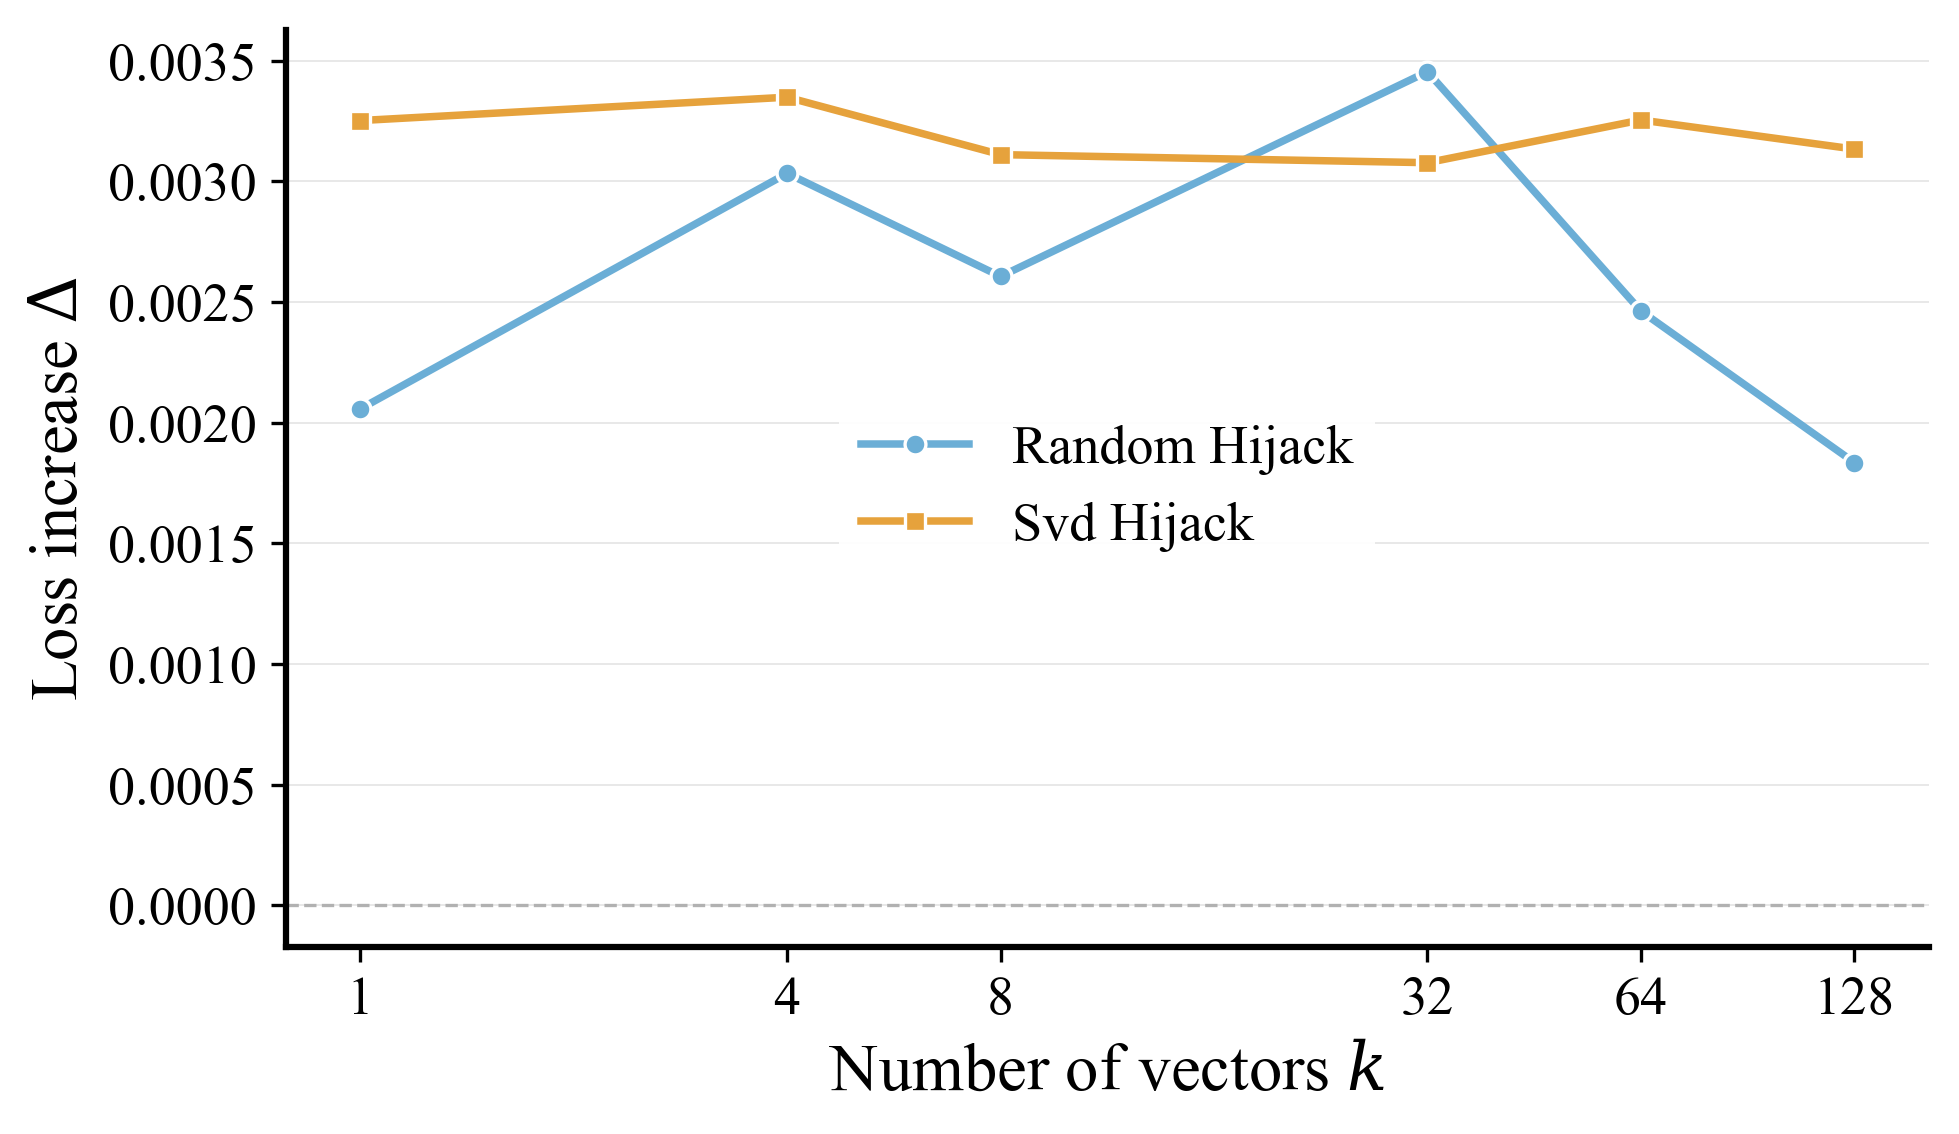

In [3]:
fig = plot_delta_vs_k_acl(results, column_width="double")
fig.show()

## 3. Expert migration matrix per k and variant

Plots the routing migration matrix only: once with **raw counts**, once with **row-normalized percentages** (% of each original expert’s tokens that went to each new expert). Set `K_SELECT` and optionally `VARIANT_SELECT` to restrict which to plot (default: all).

/Users/noyah/University/ILLM project/GaleMoE/src/experiments/router_interventions/viz/plotter.py:529: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/y_/lbn7h_sj0bl553hrsqbml1zc0000gp/T/ipykernel_41976/1522569586.py:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_raw.show()
/Users/noyah/University/ILLM project/GaleMoE/src/experiments/router_interventions/viz/plotter.py:529: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/y_/lbn7h_sj0bl553hrsqbml1zc0000gp/T/ipykernel_41976/1522569586.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig_pct.show()
/Users/noyah/University/ILLM project/GaleMoE/src/experiments/router_interventions/viz/plotter.py:529: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/var/folders/y_/lbn7h_sj0bl553hrsqbml1zc0000gp/T/ipykernel_41976/1522569586.py:42: UserWarning: FigureCanvasAgg is non-interact

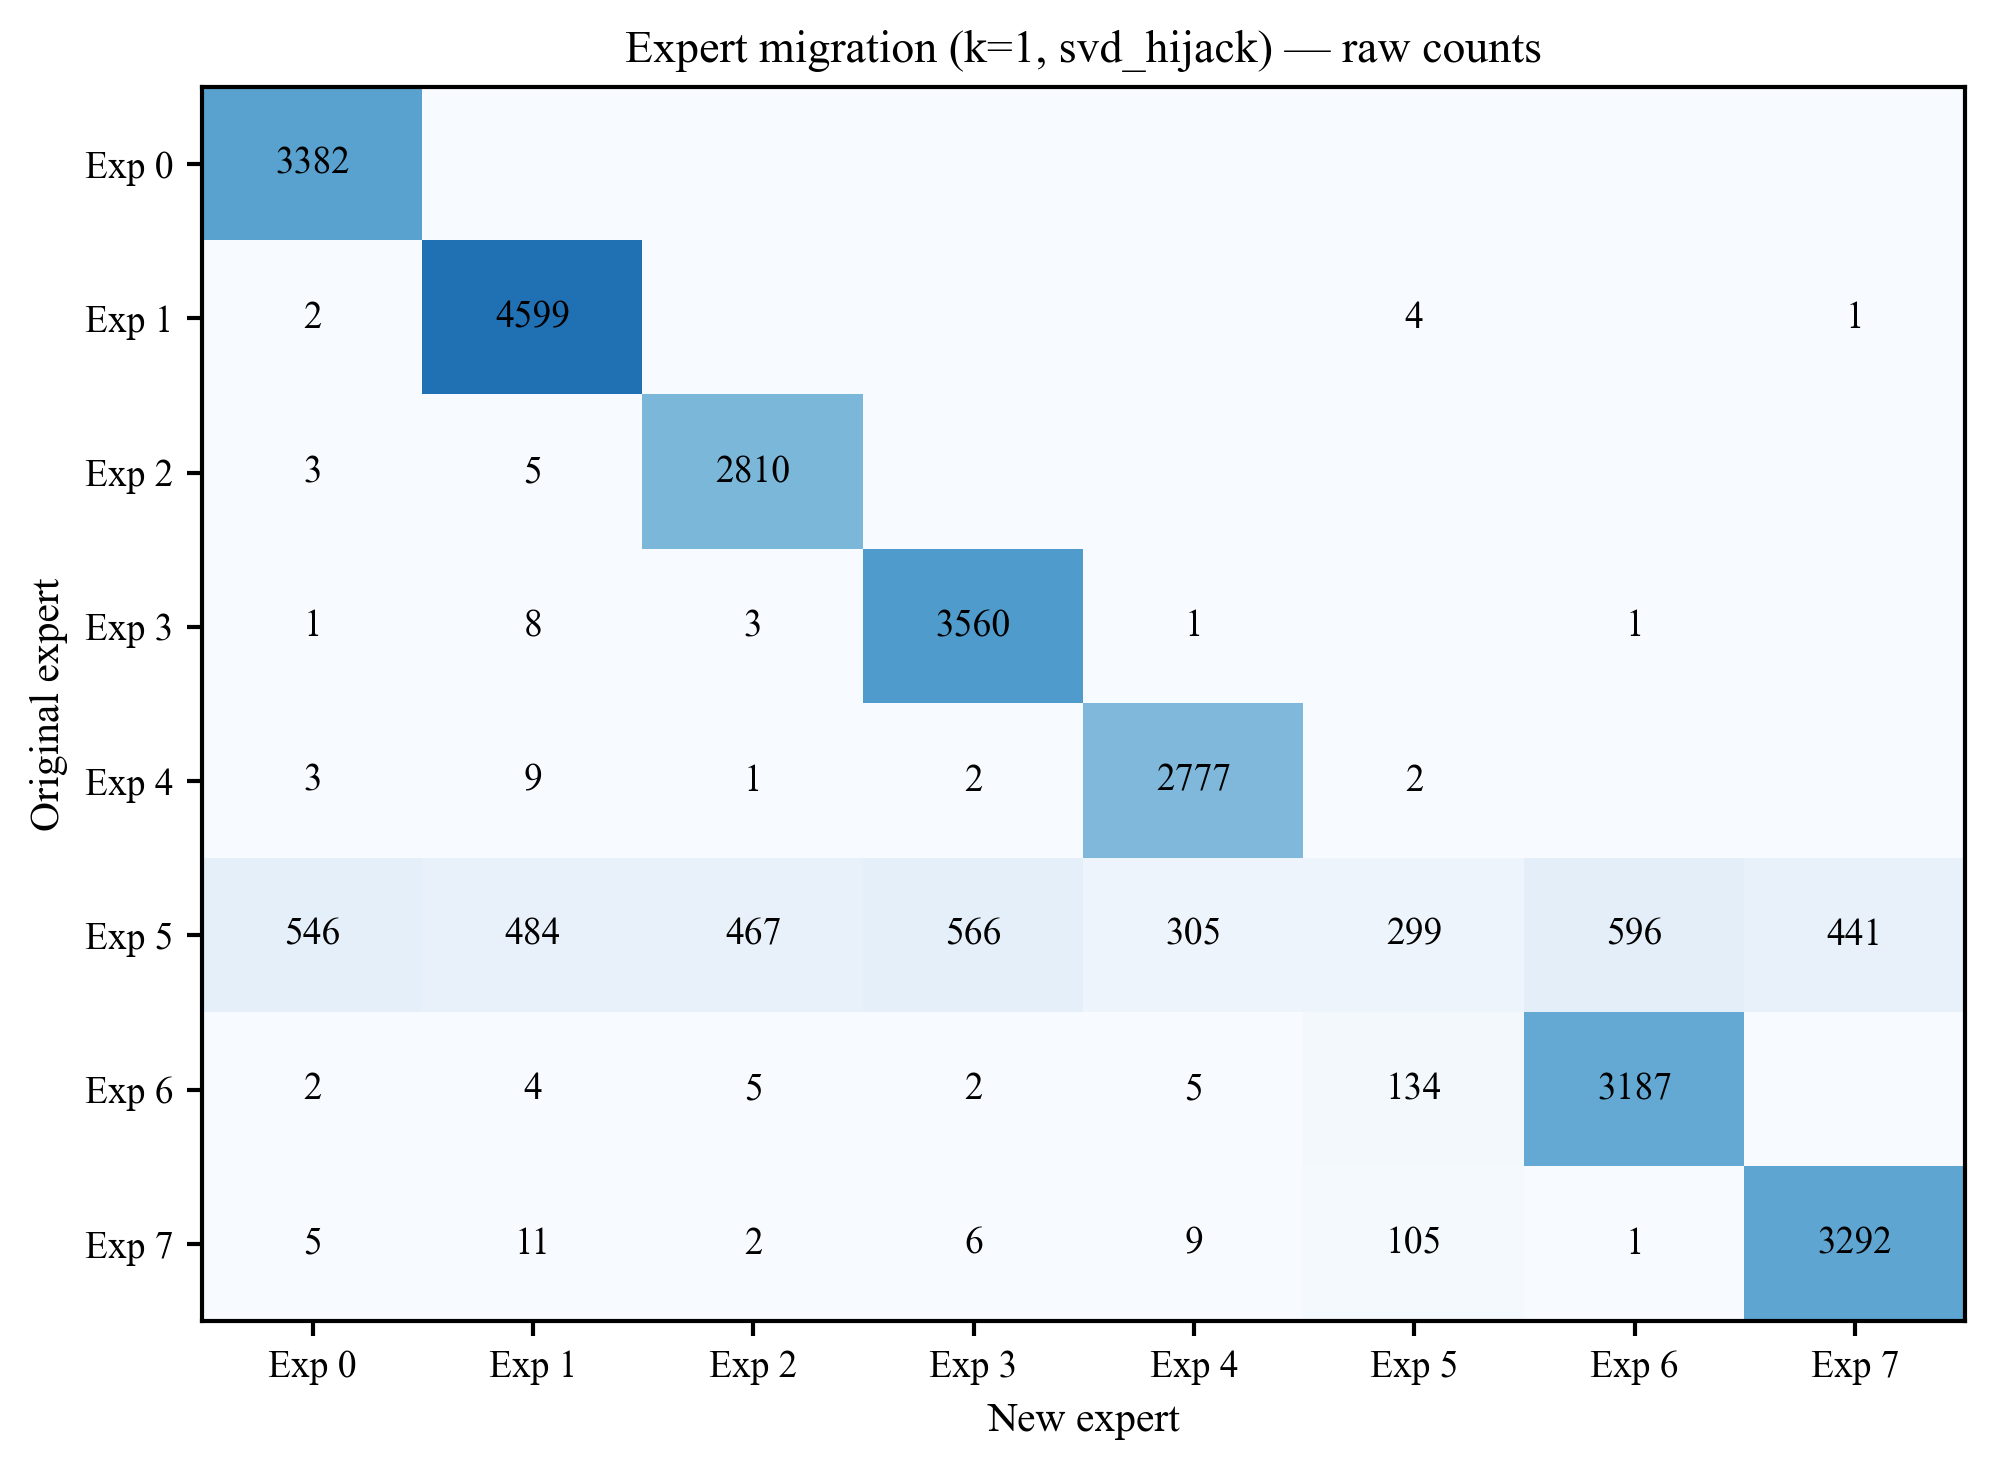

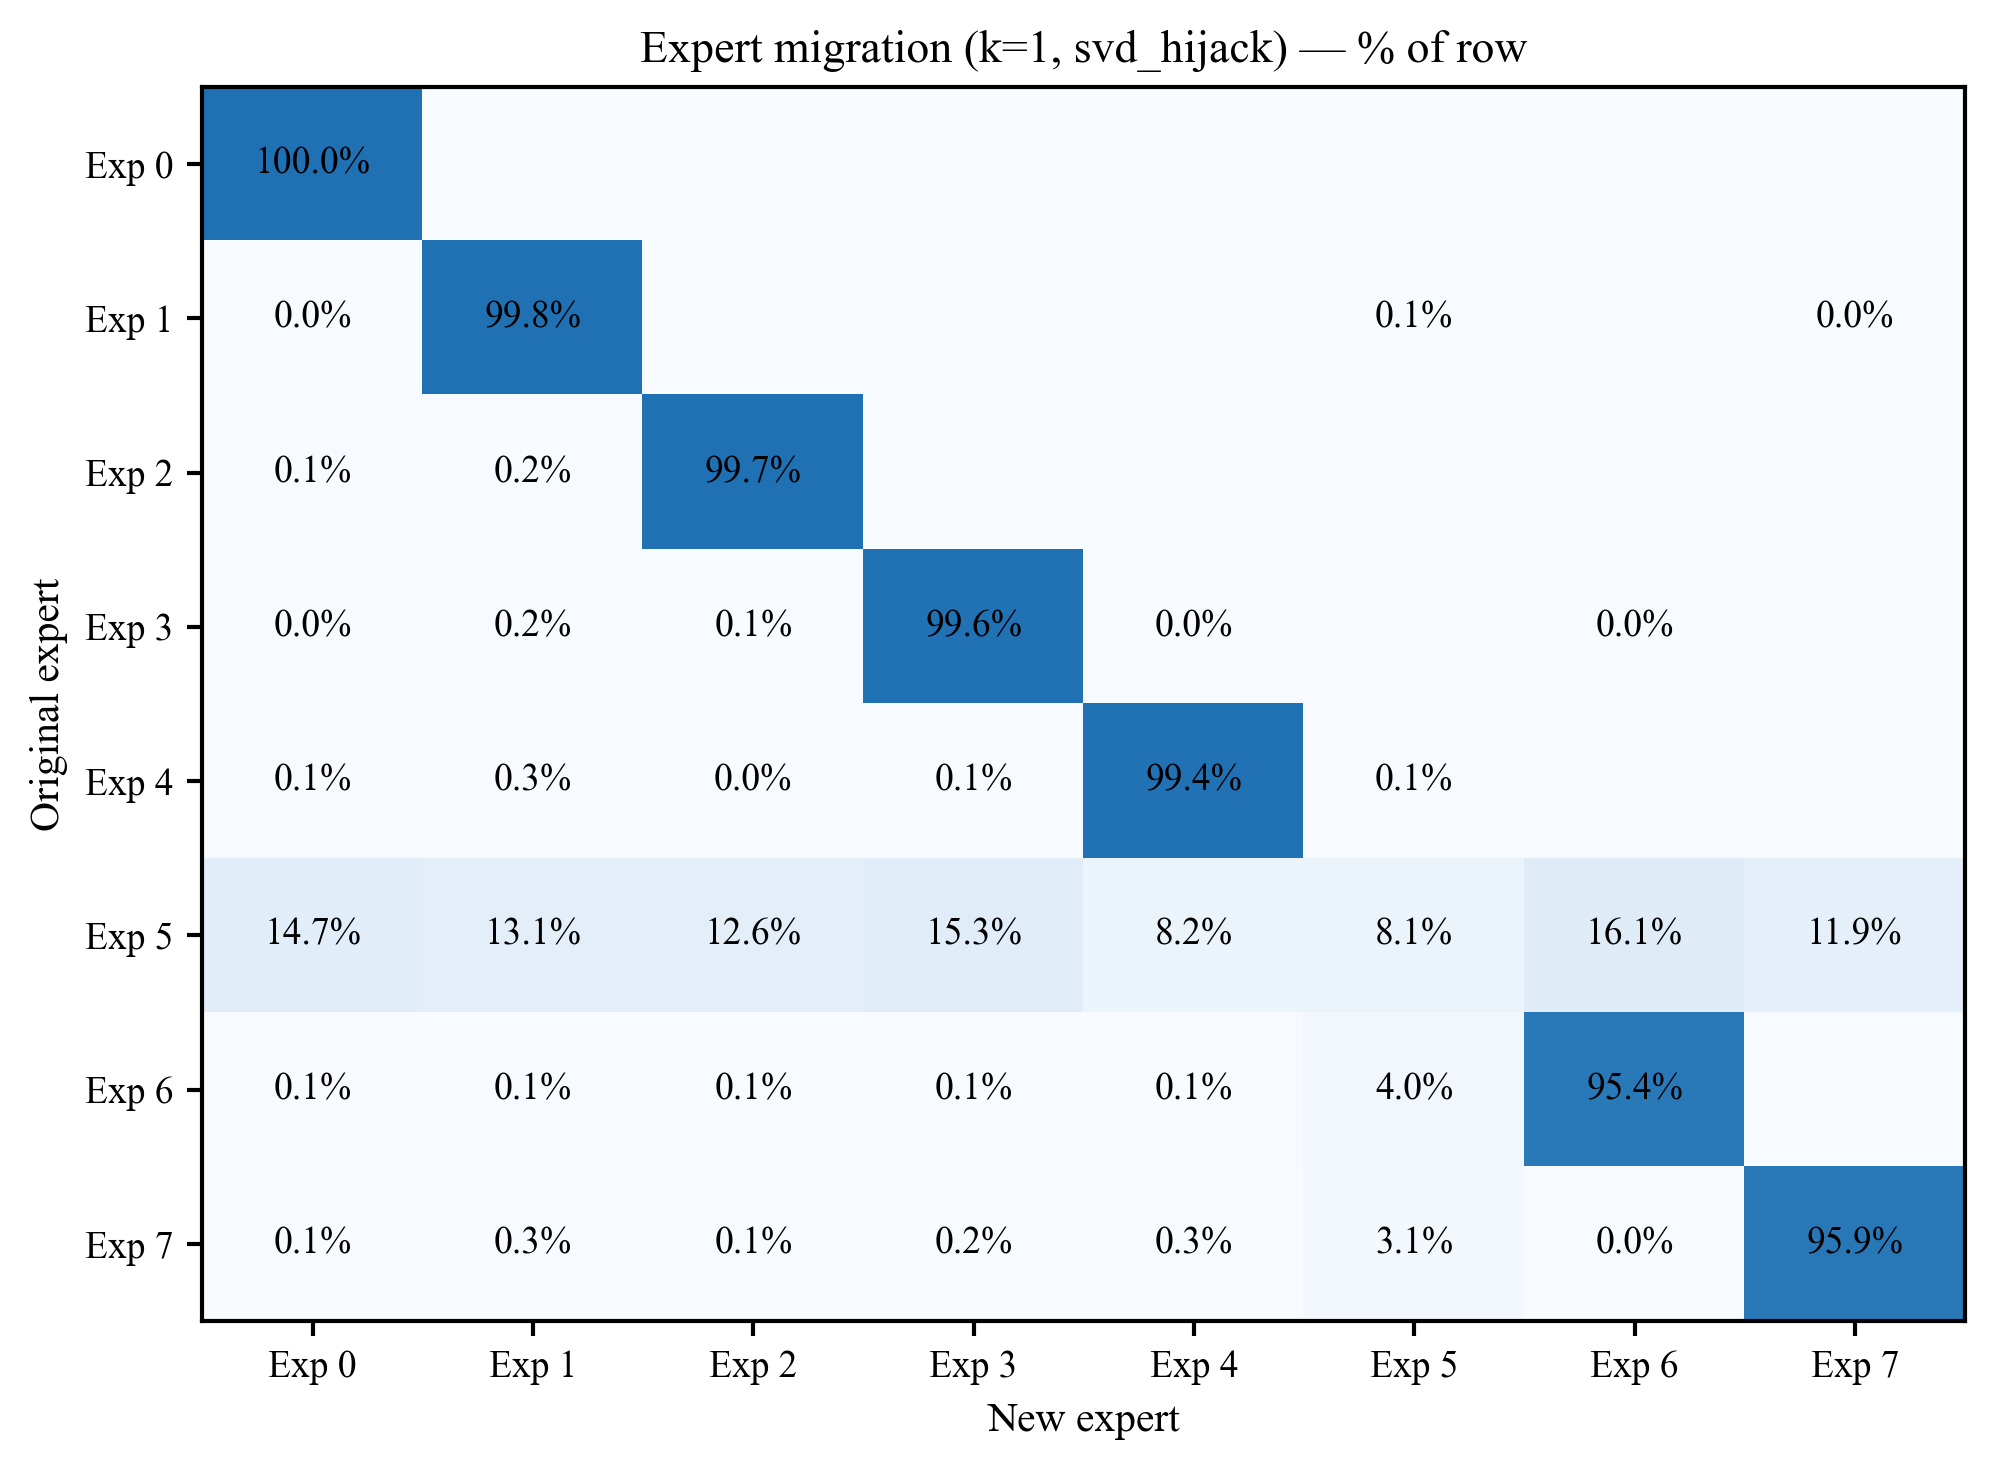

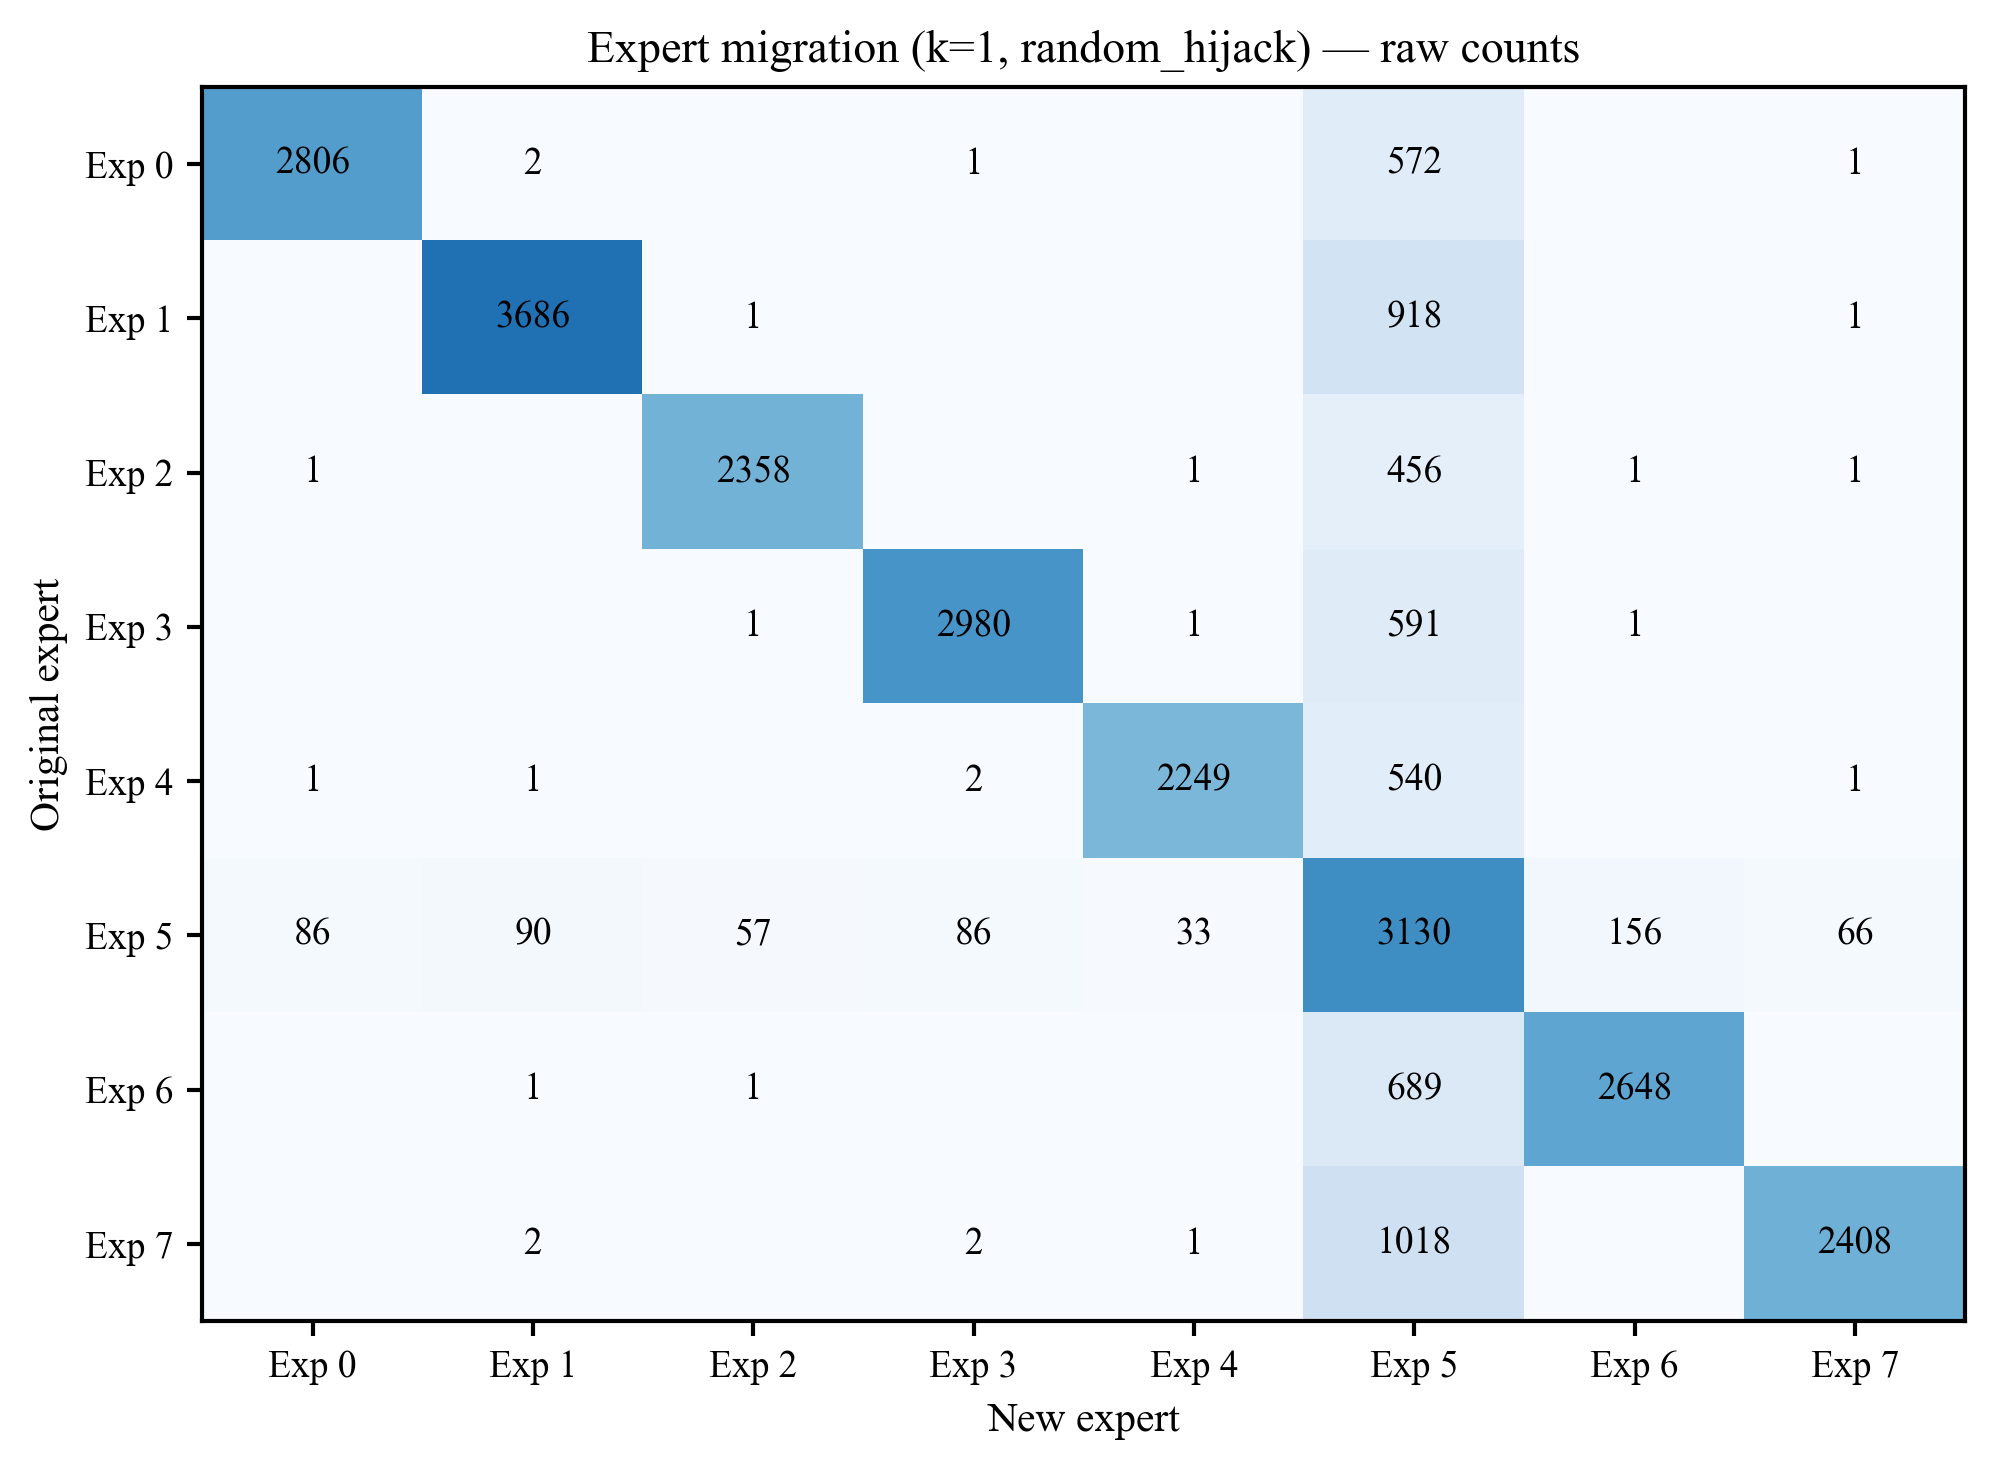

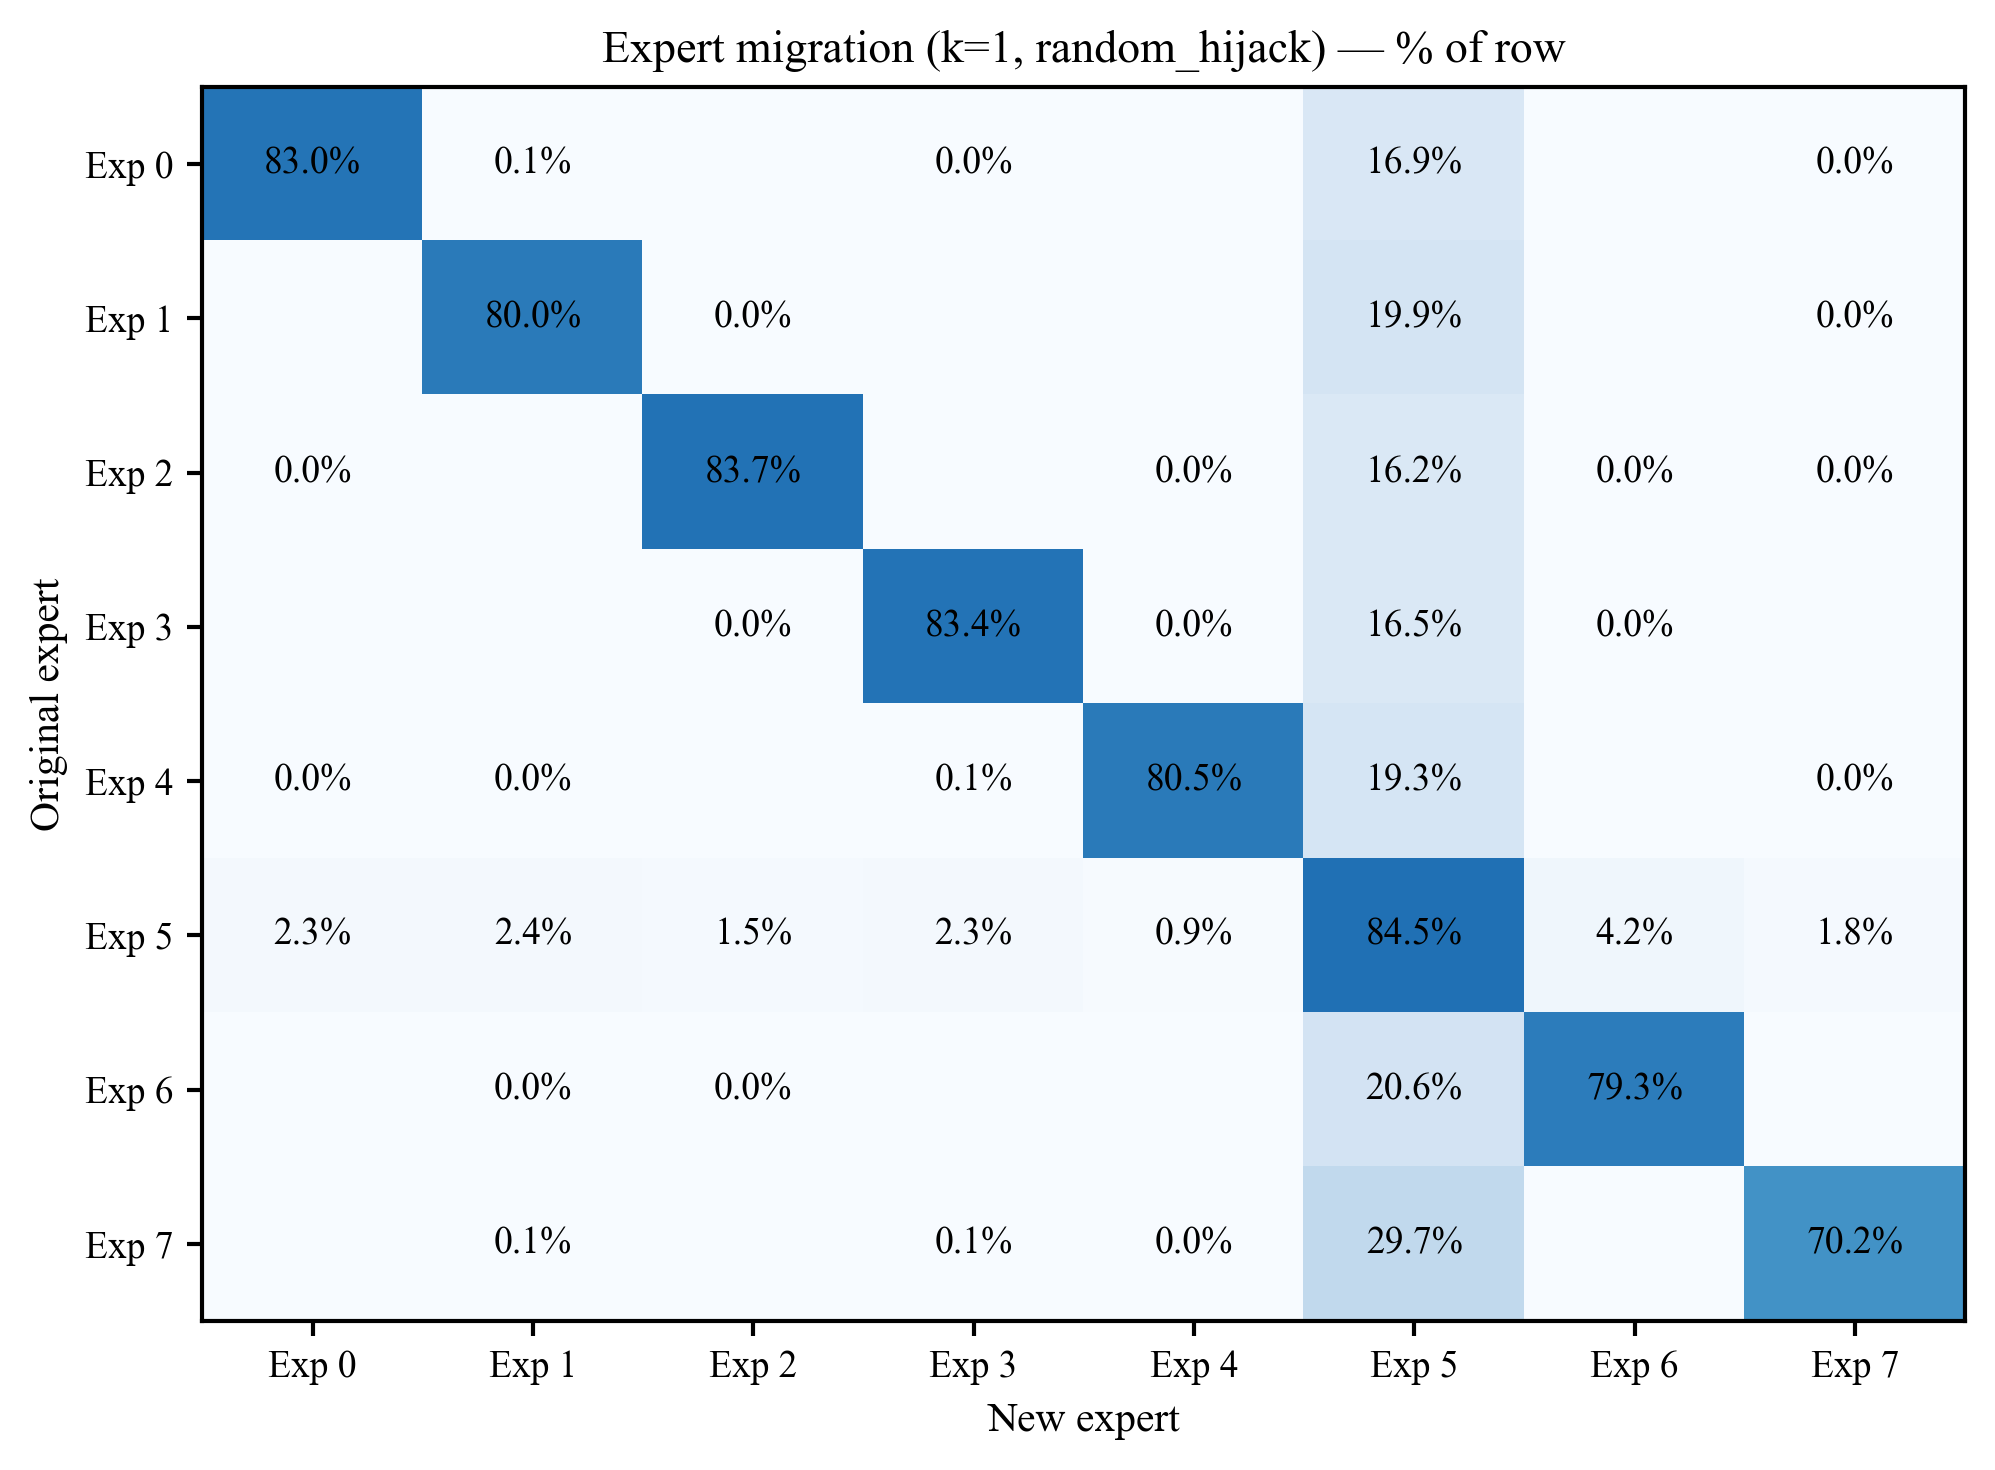

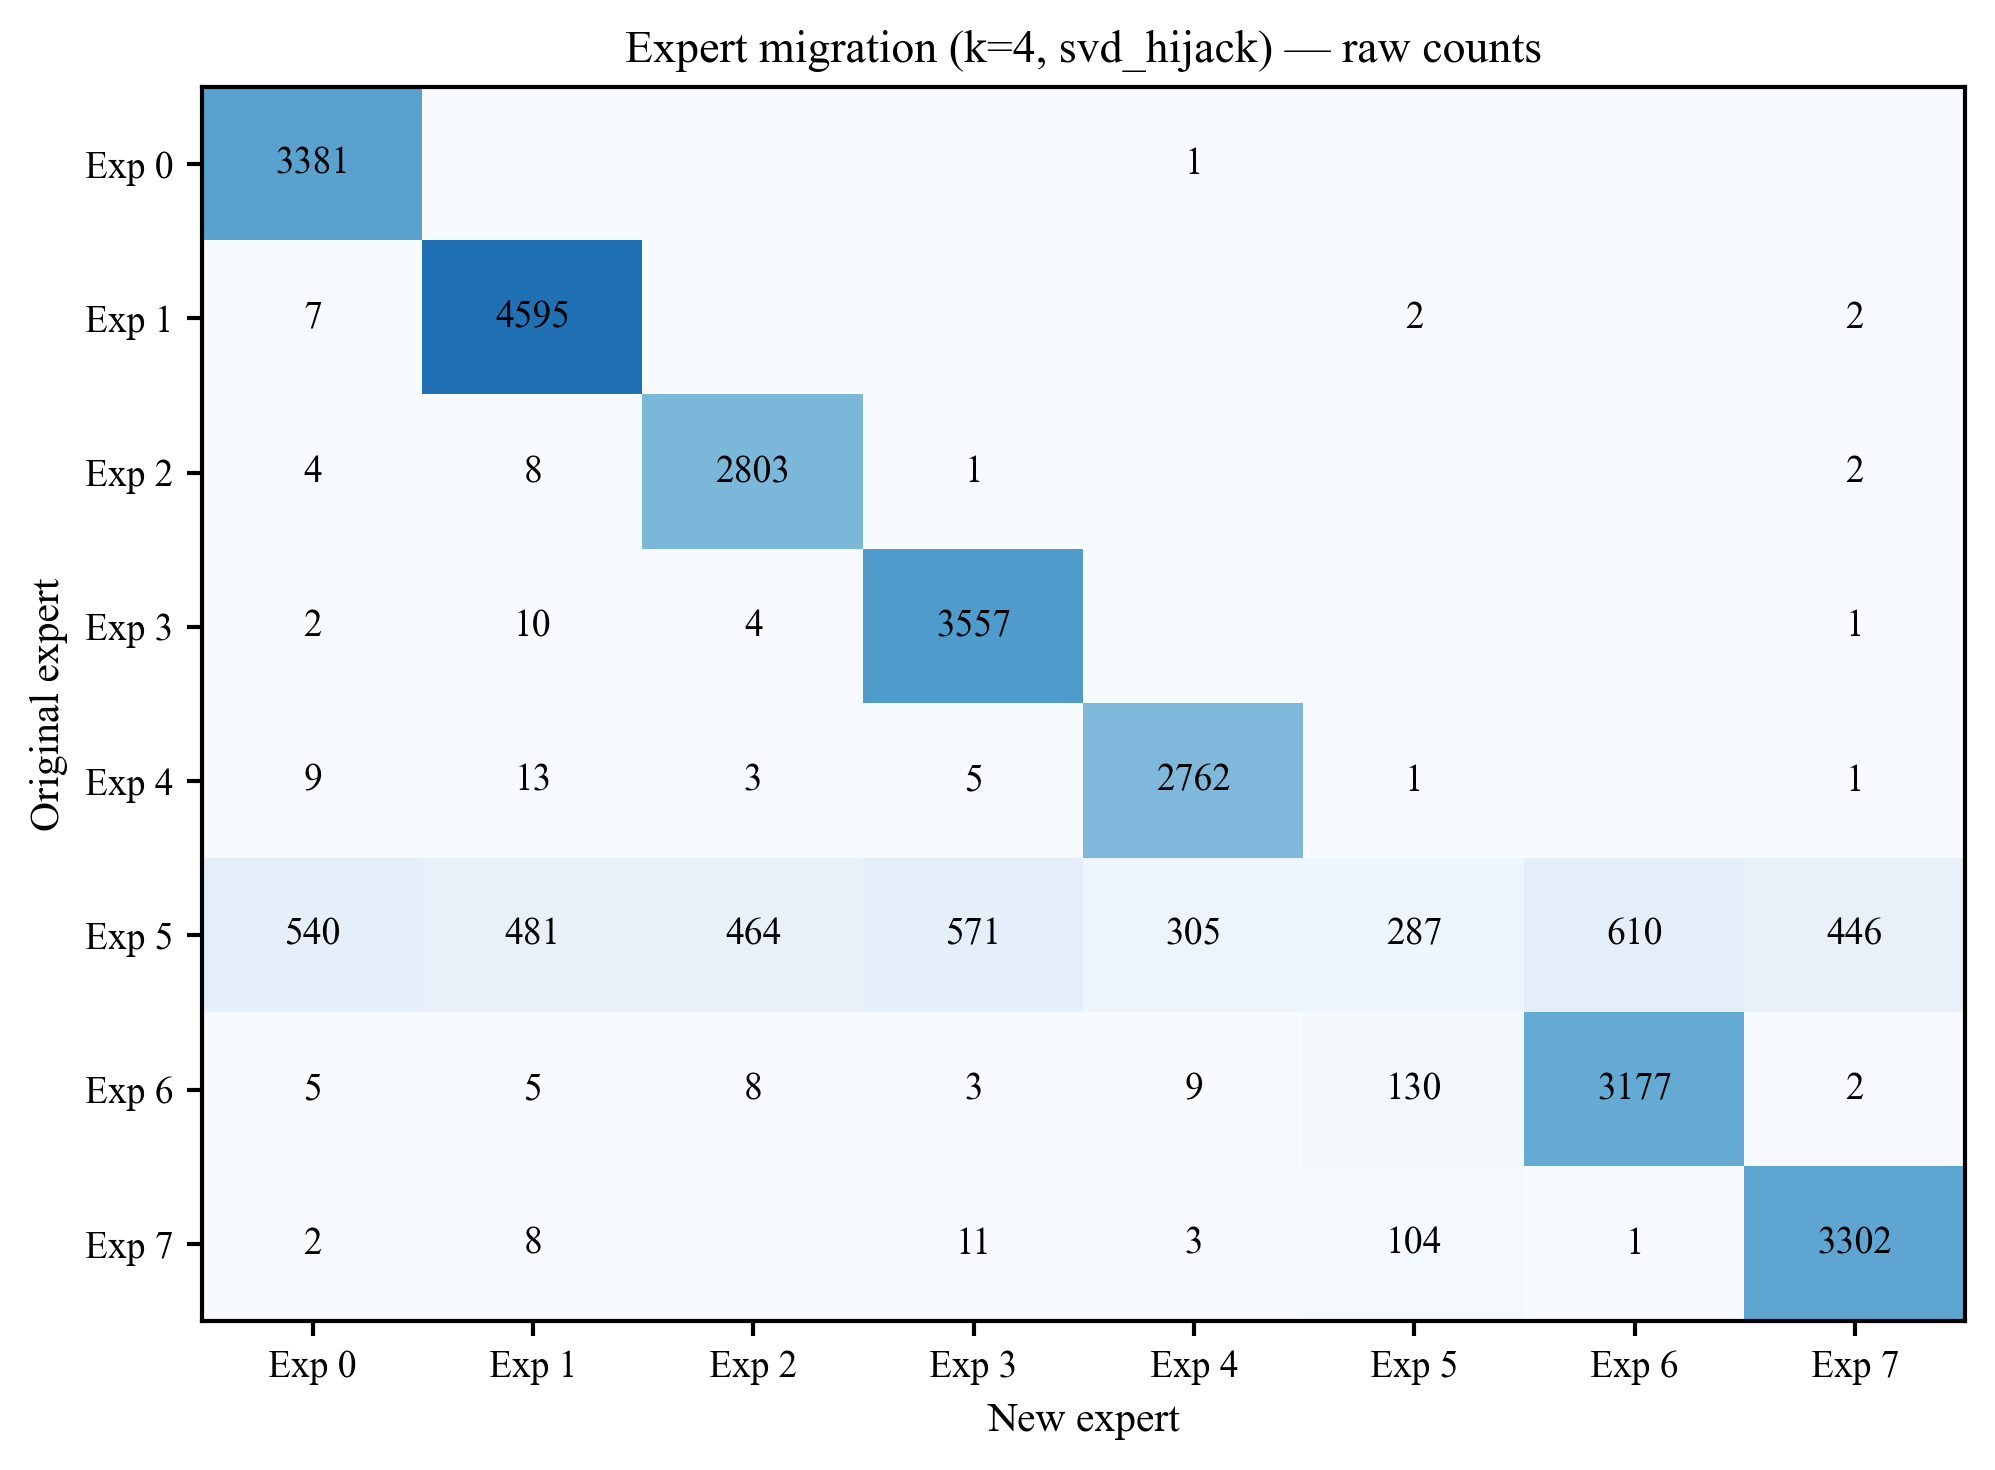

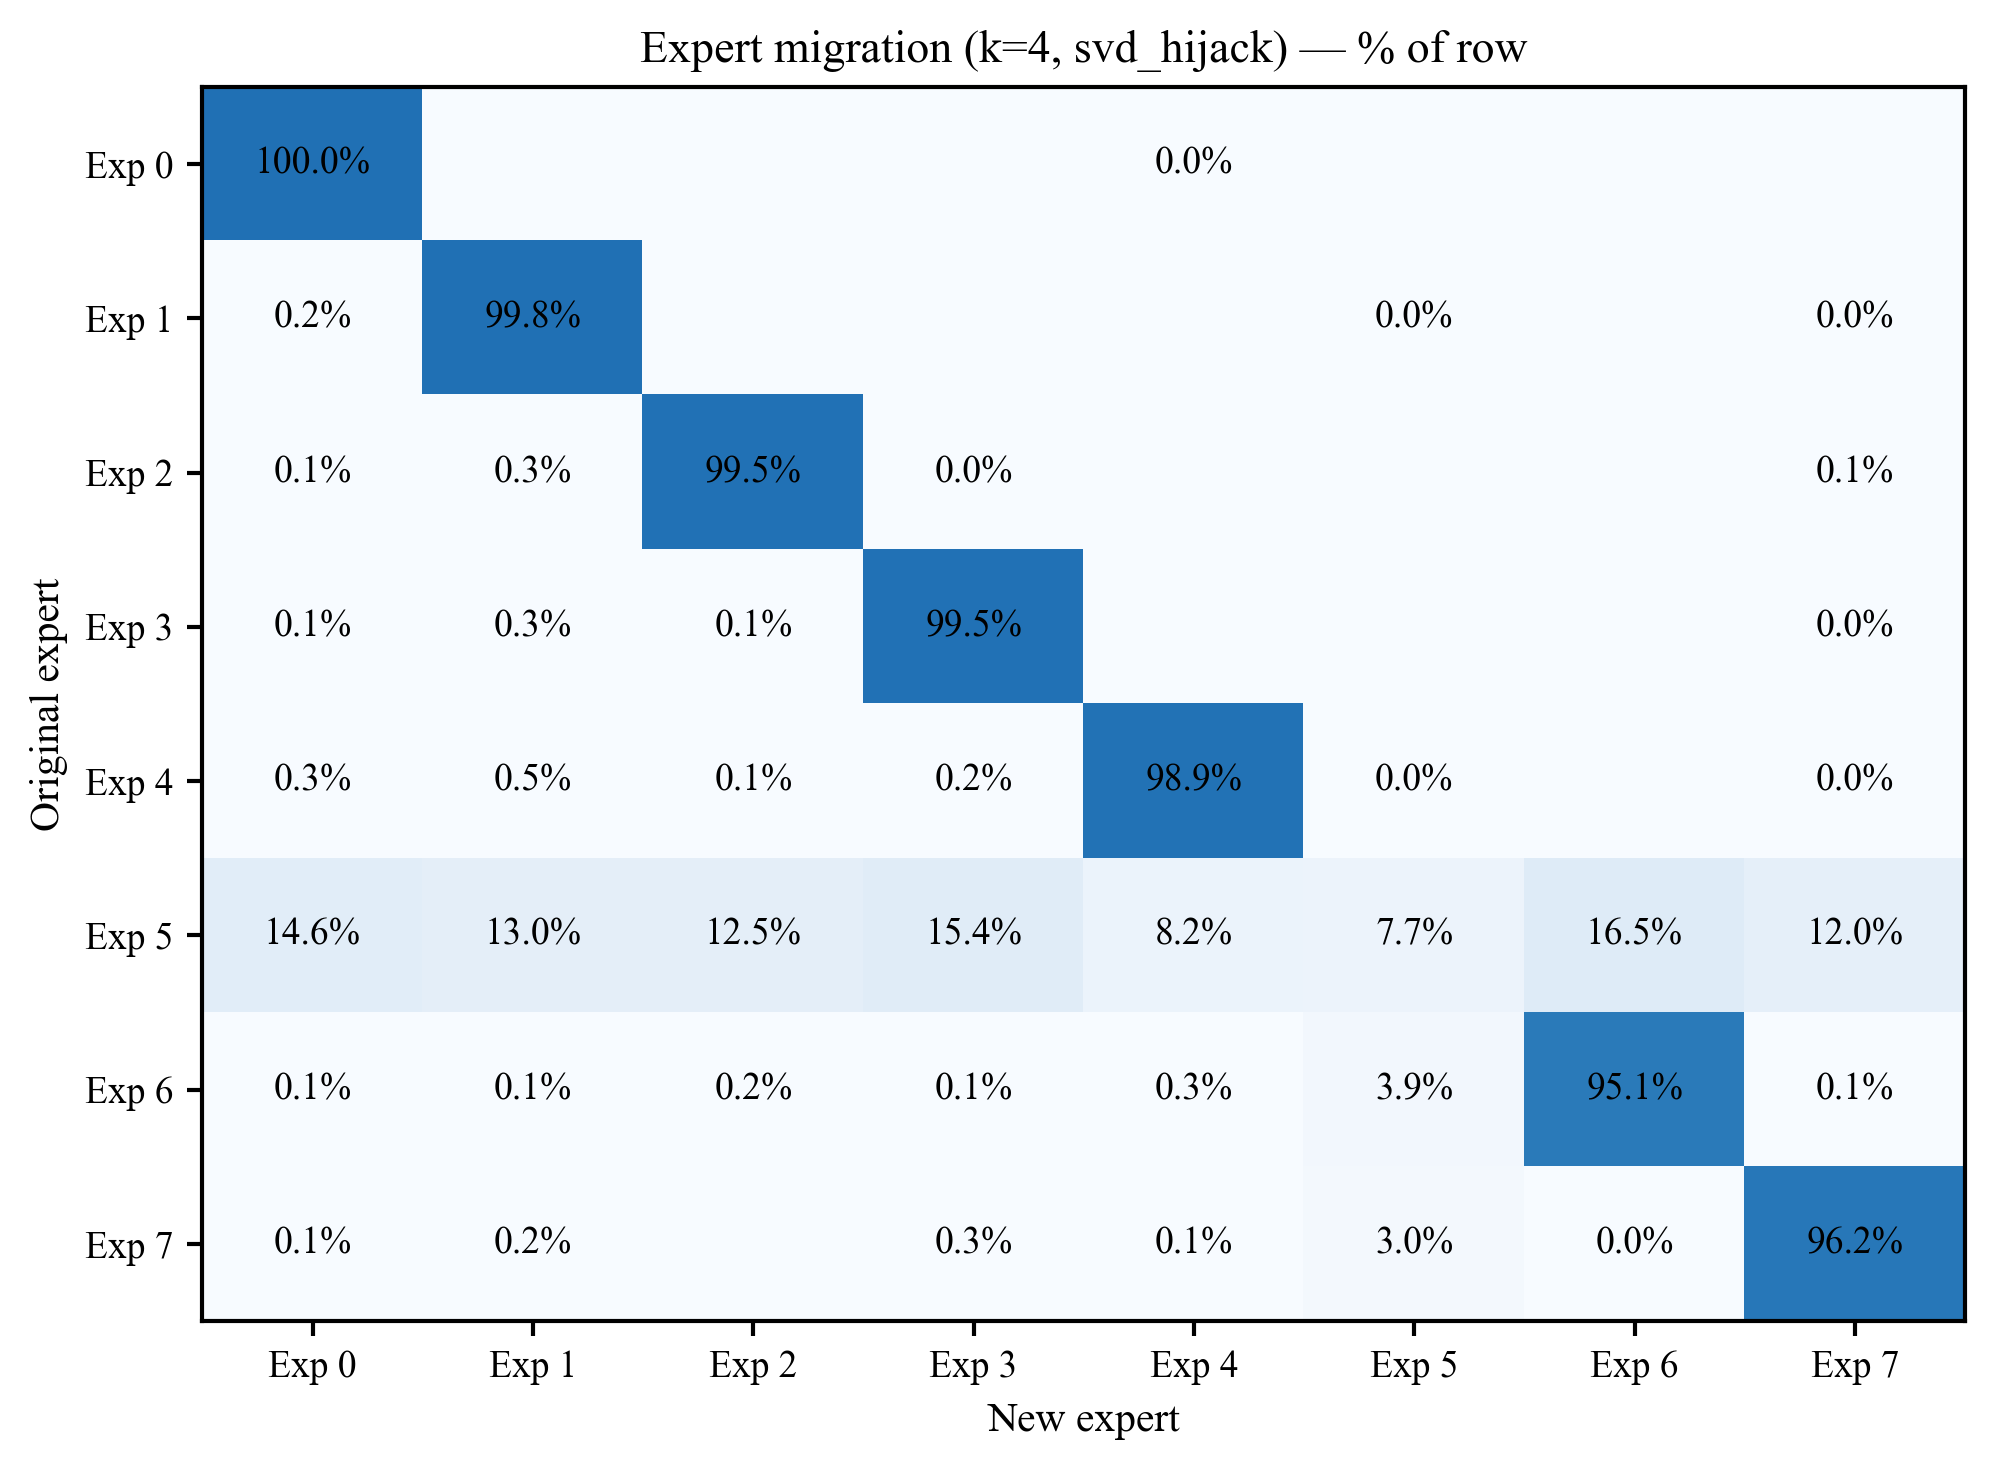

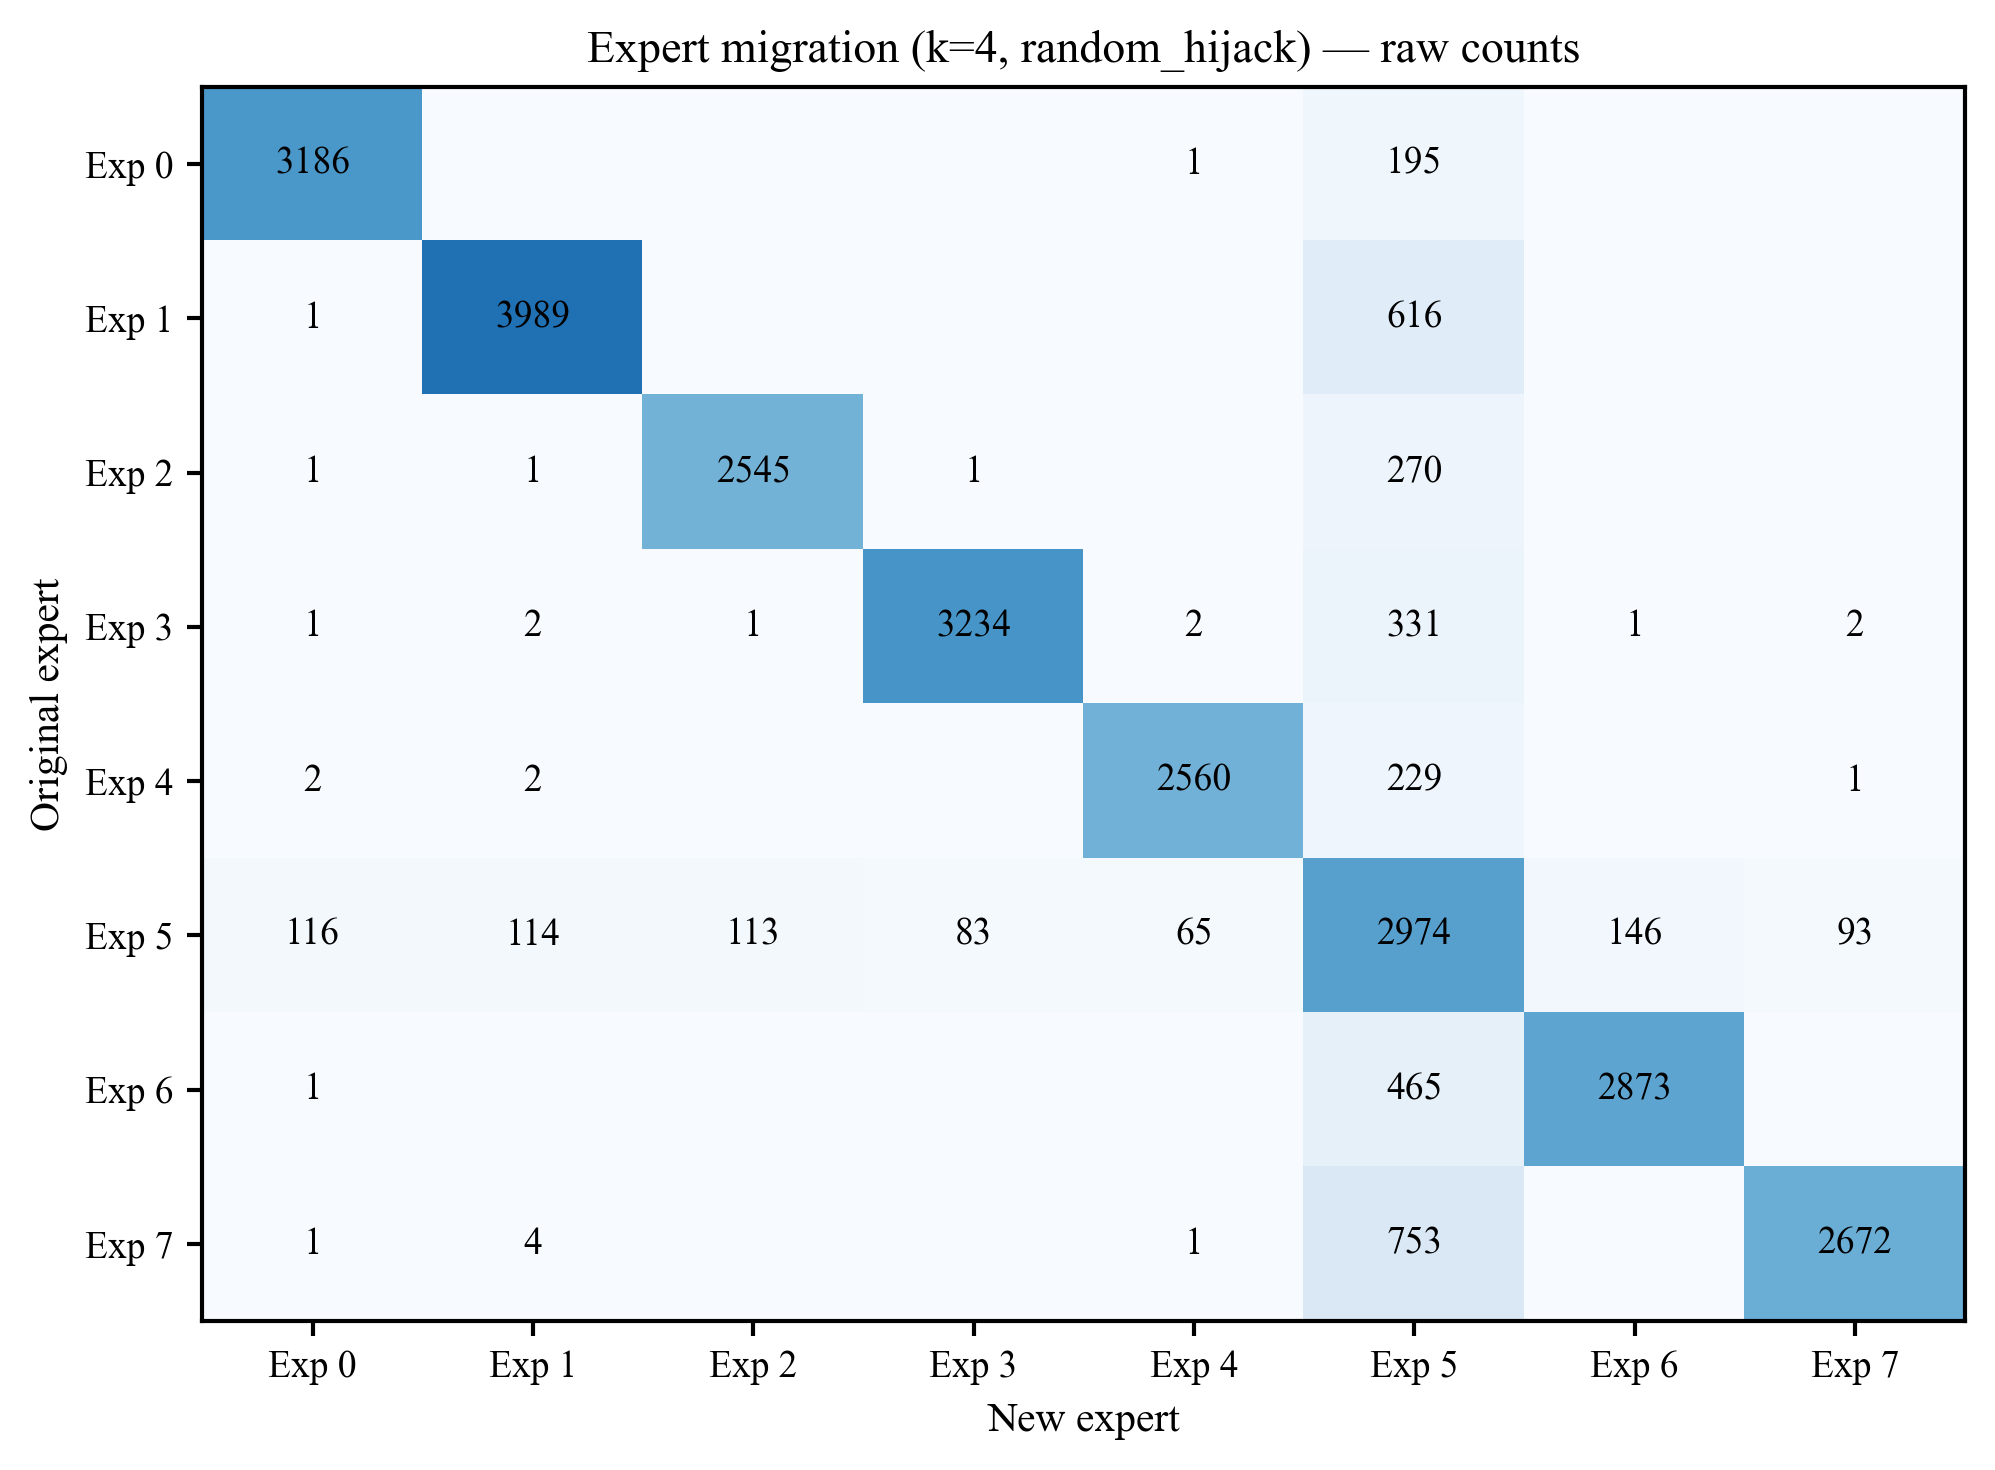

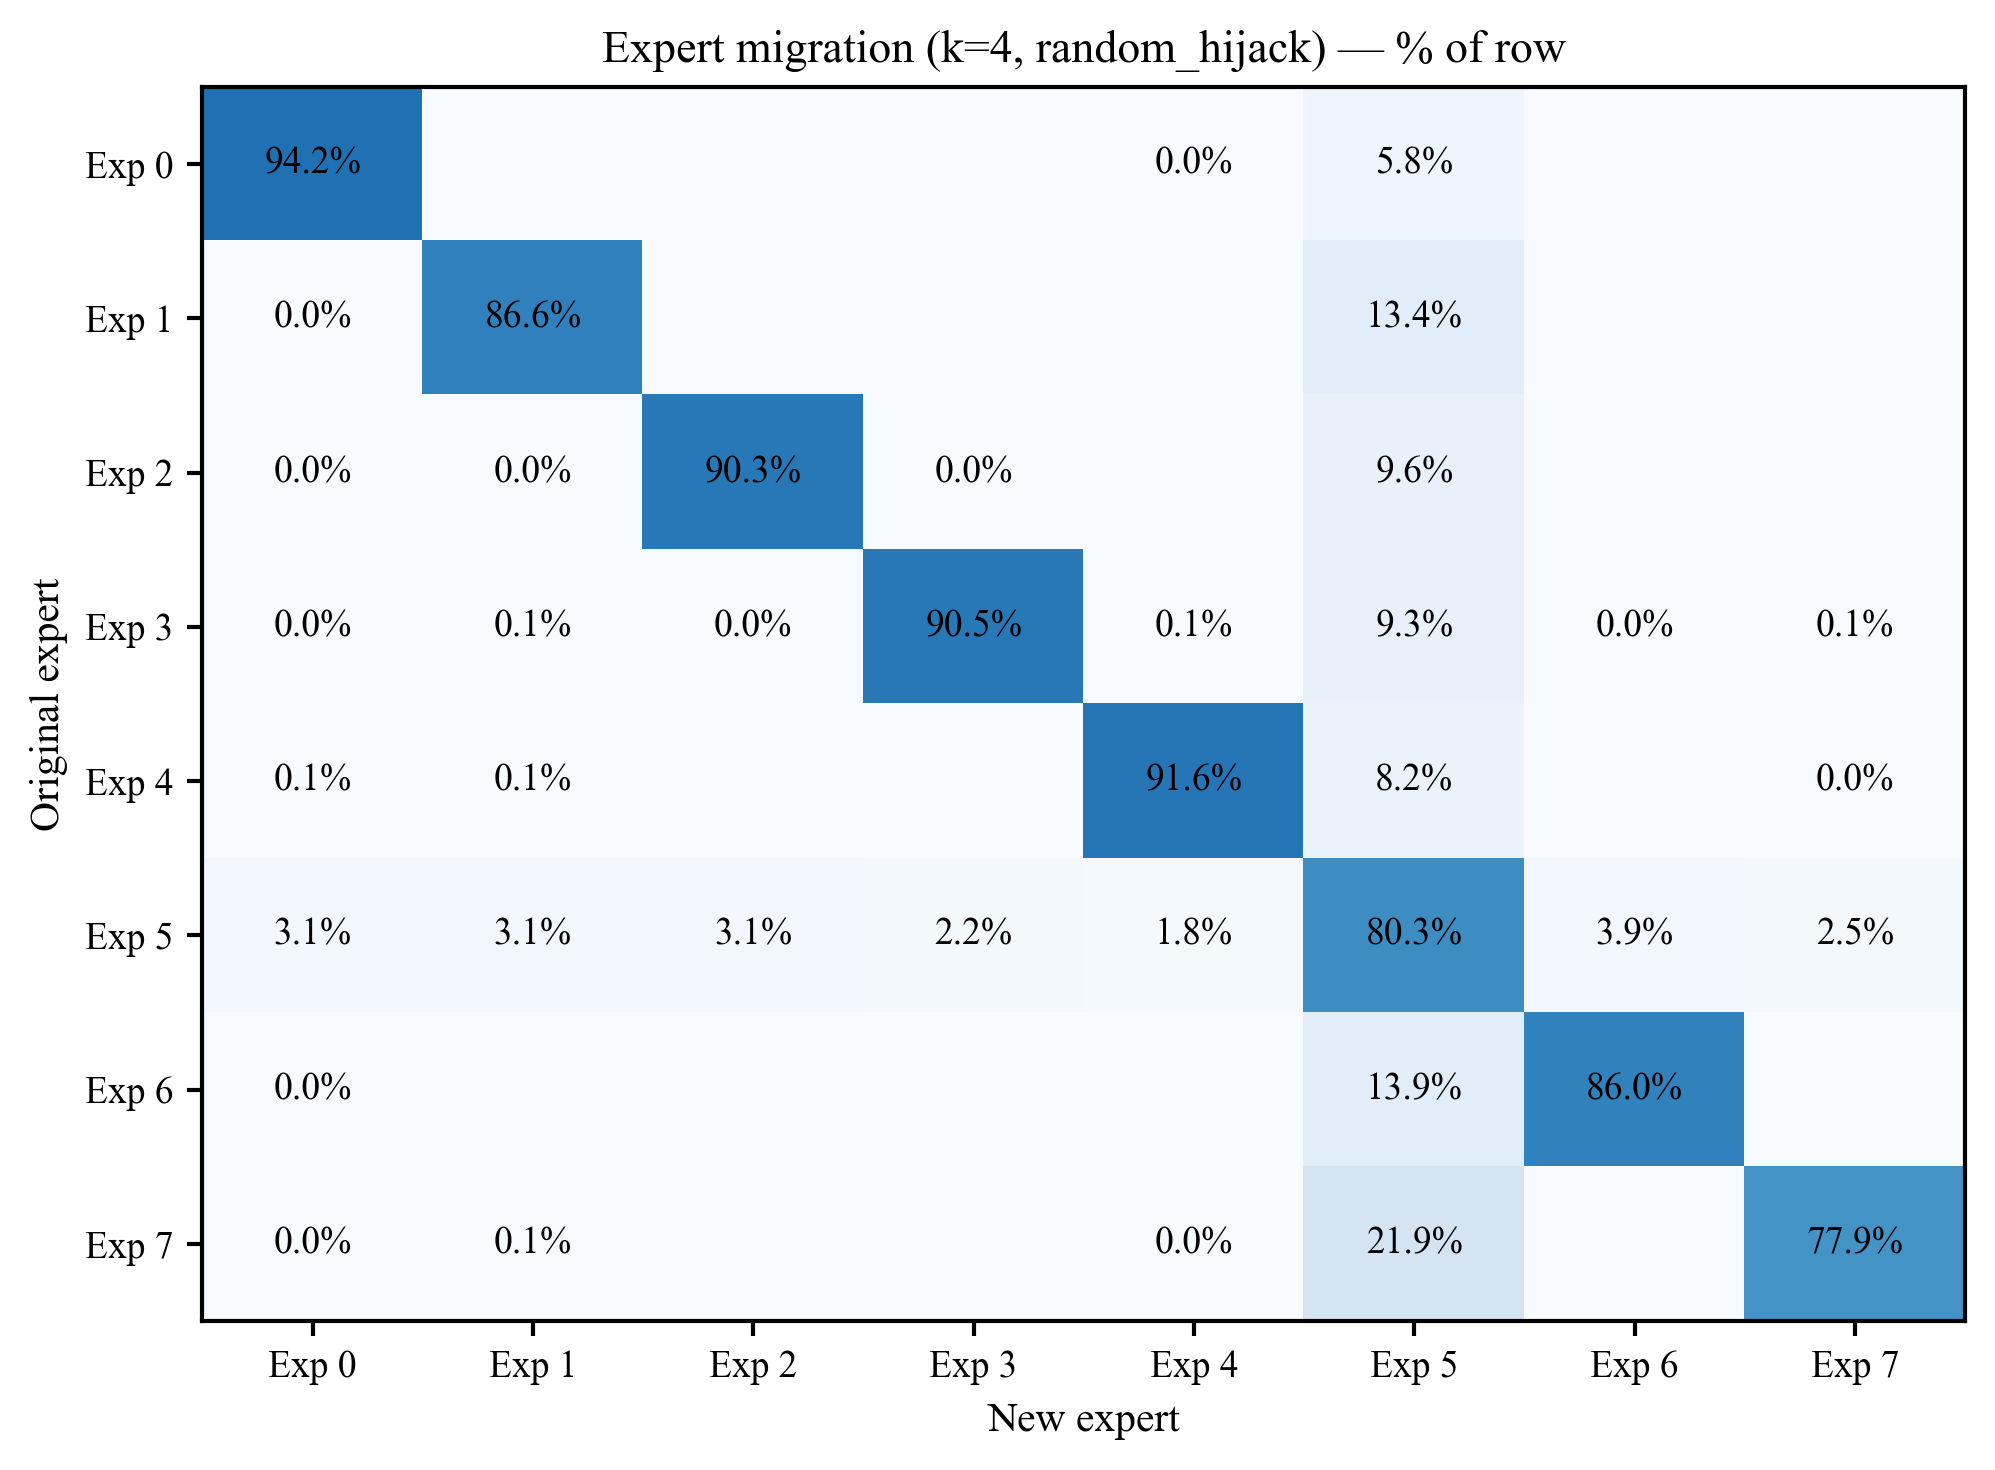

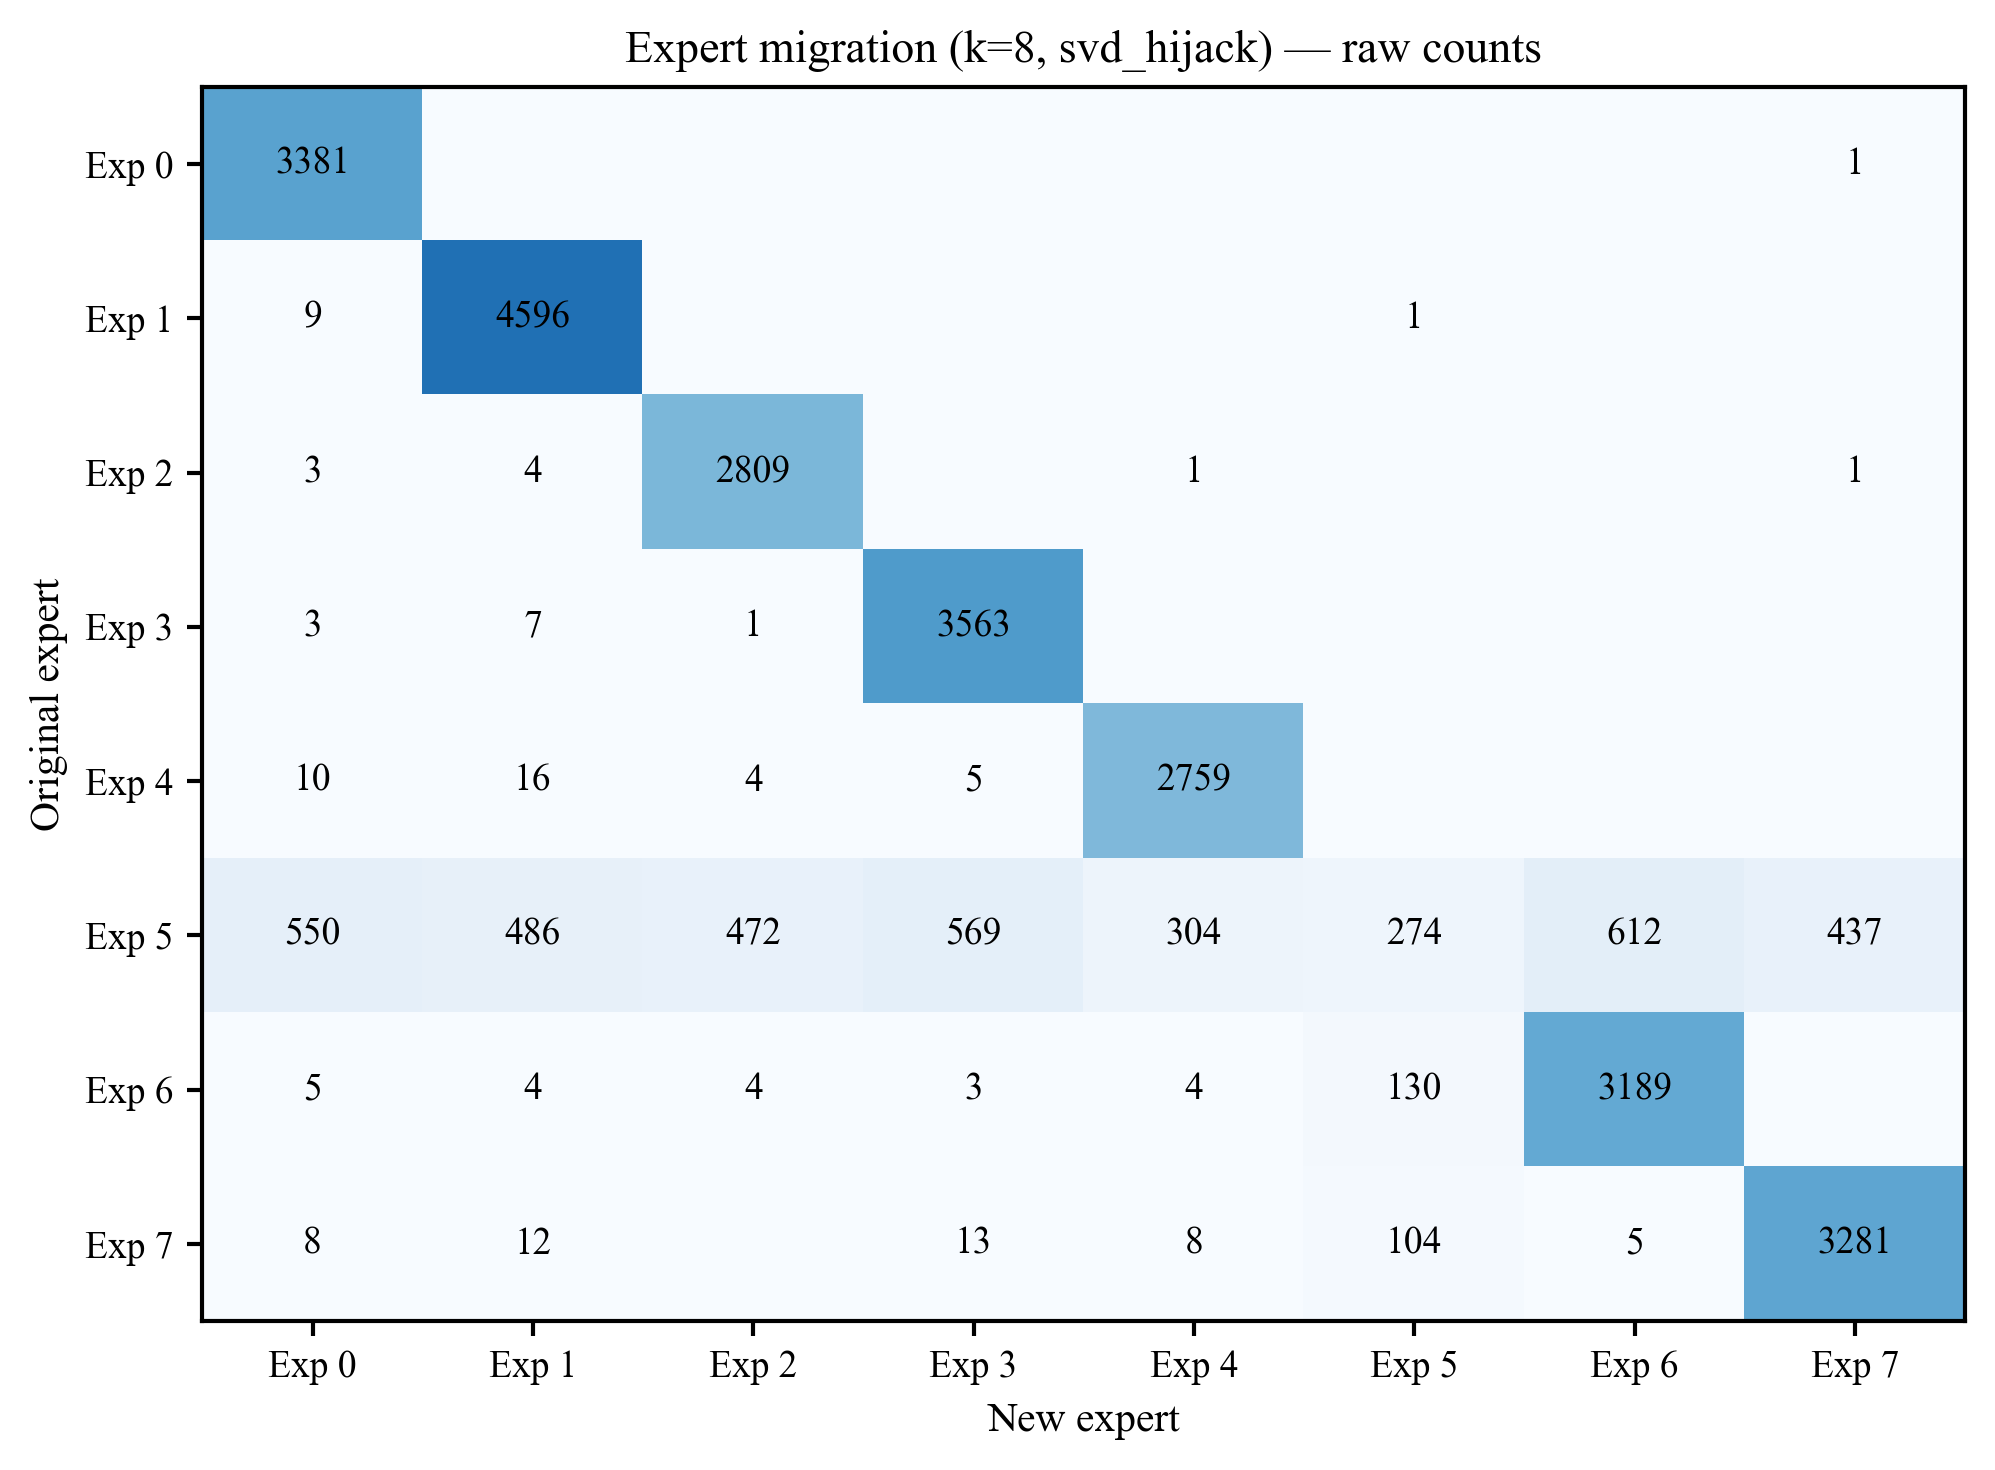

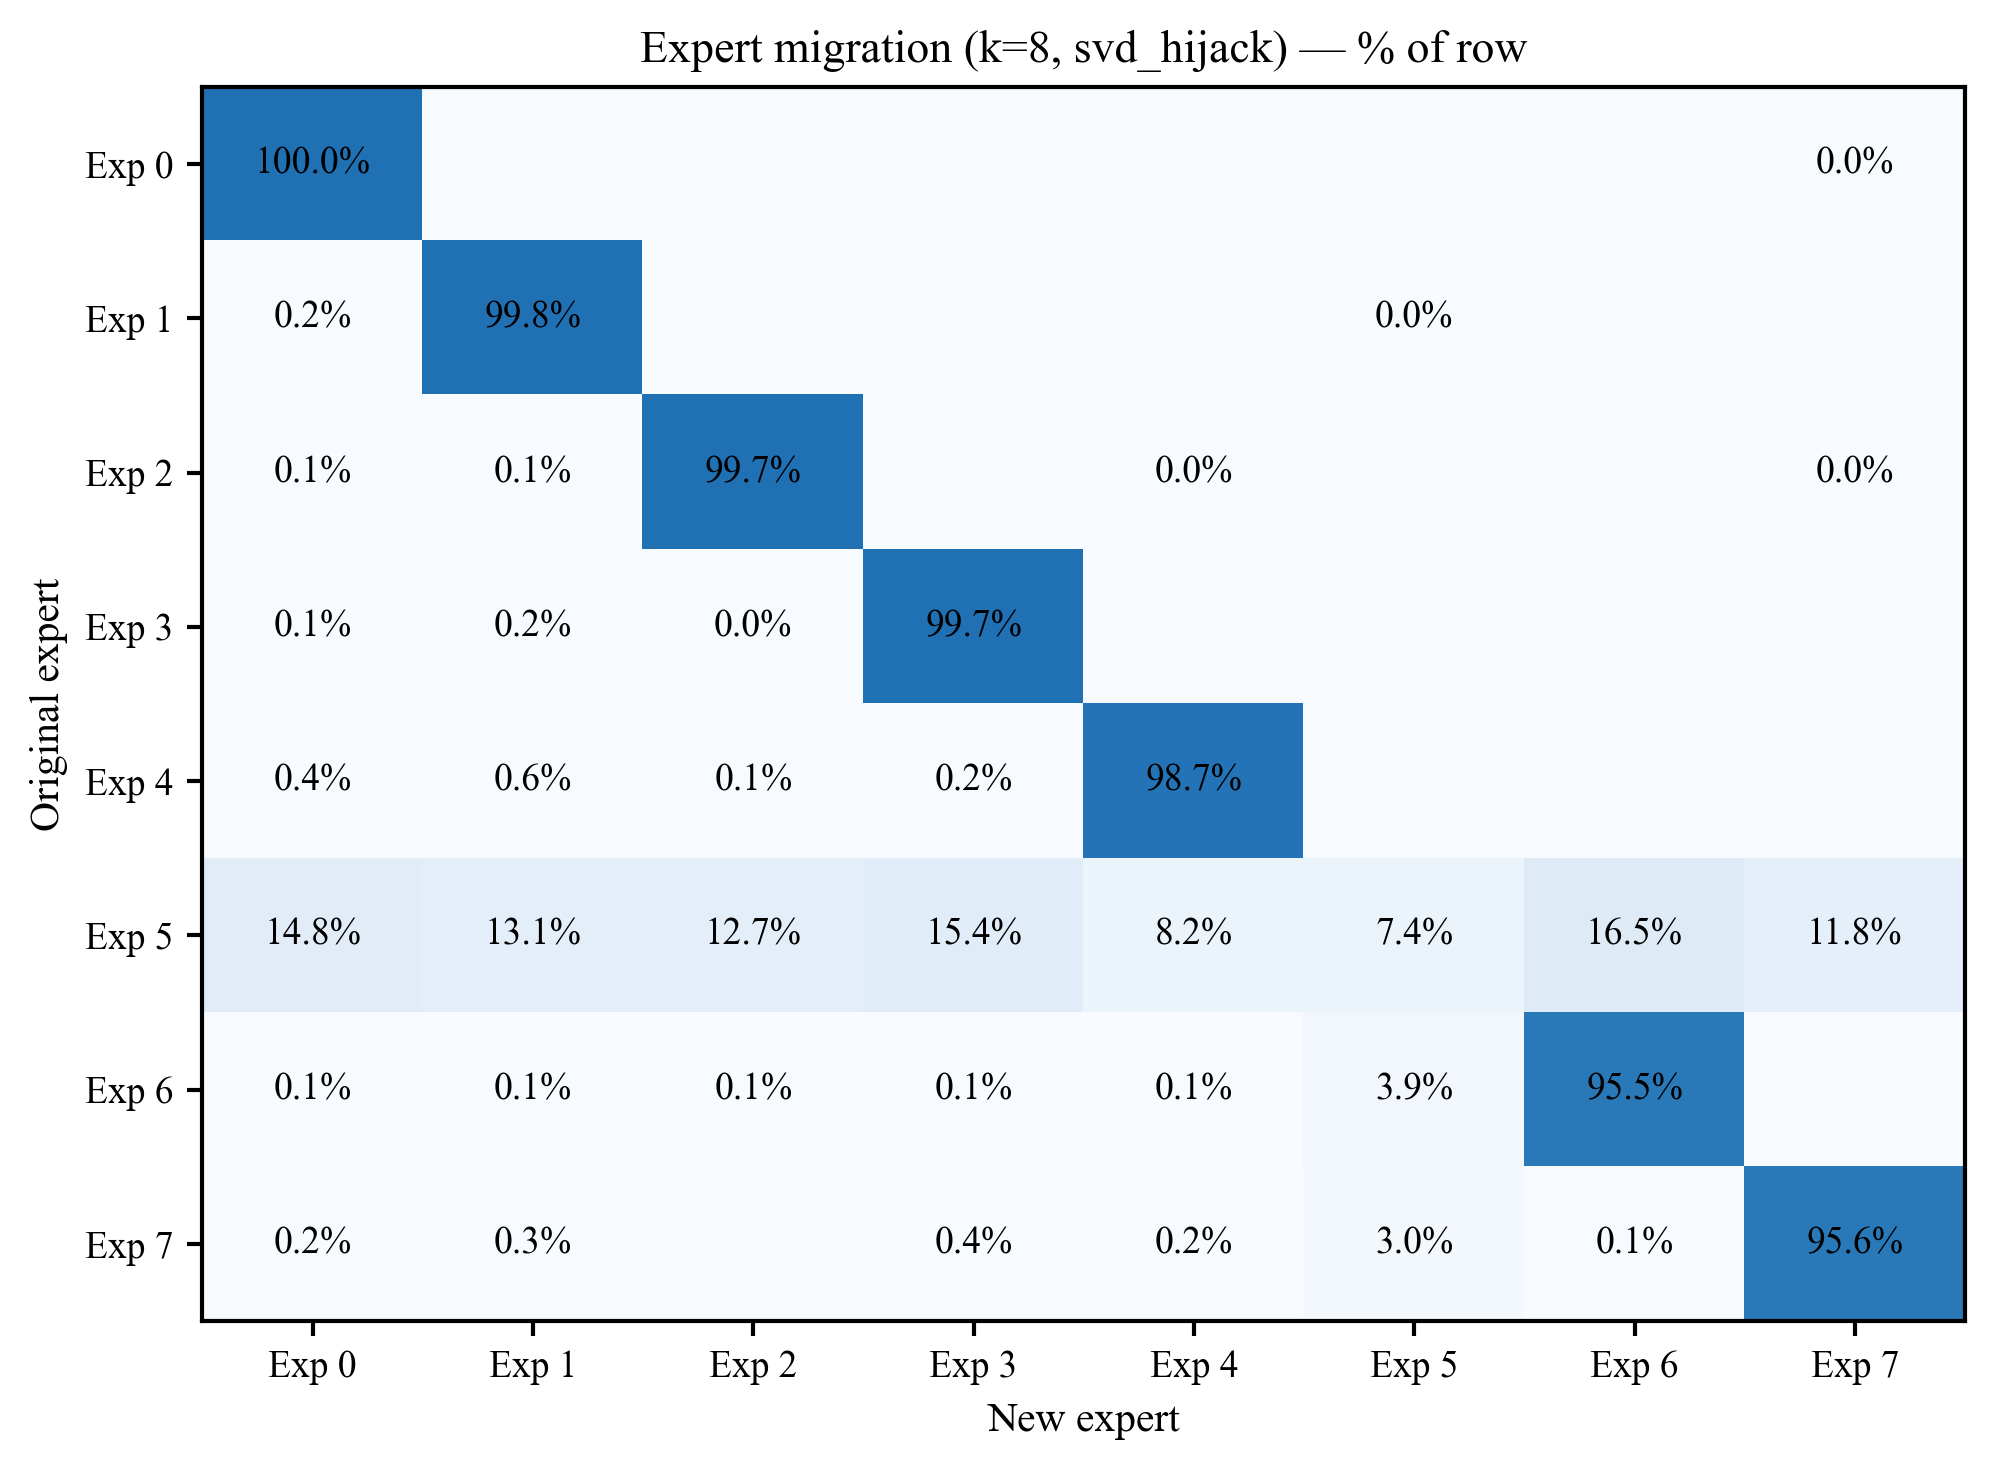

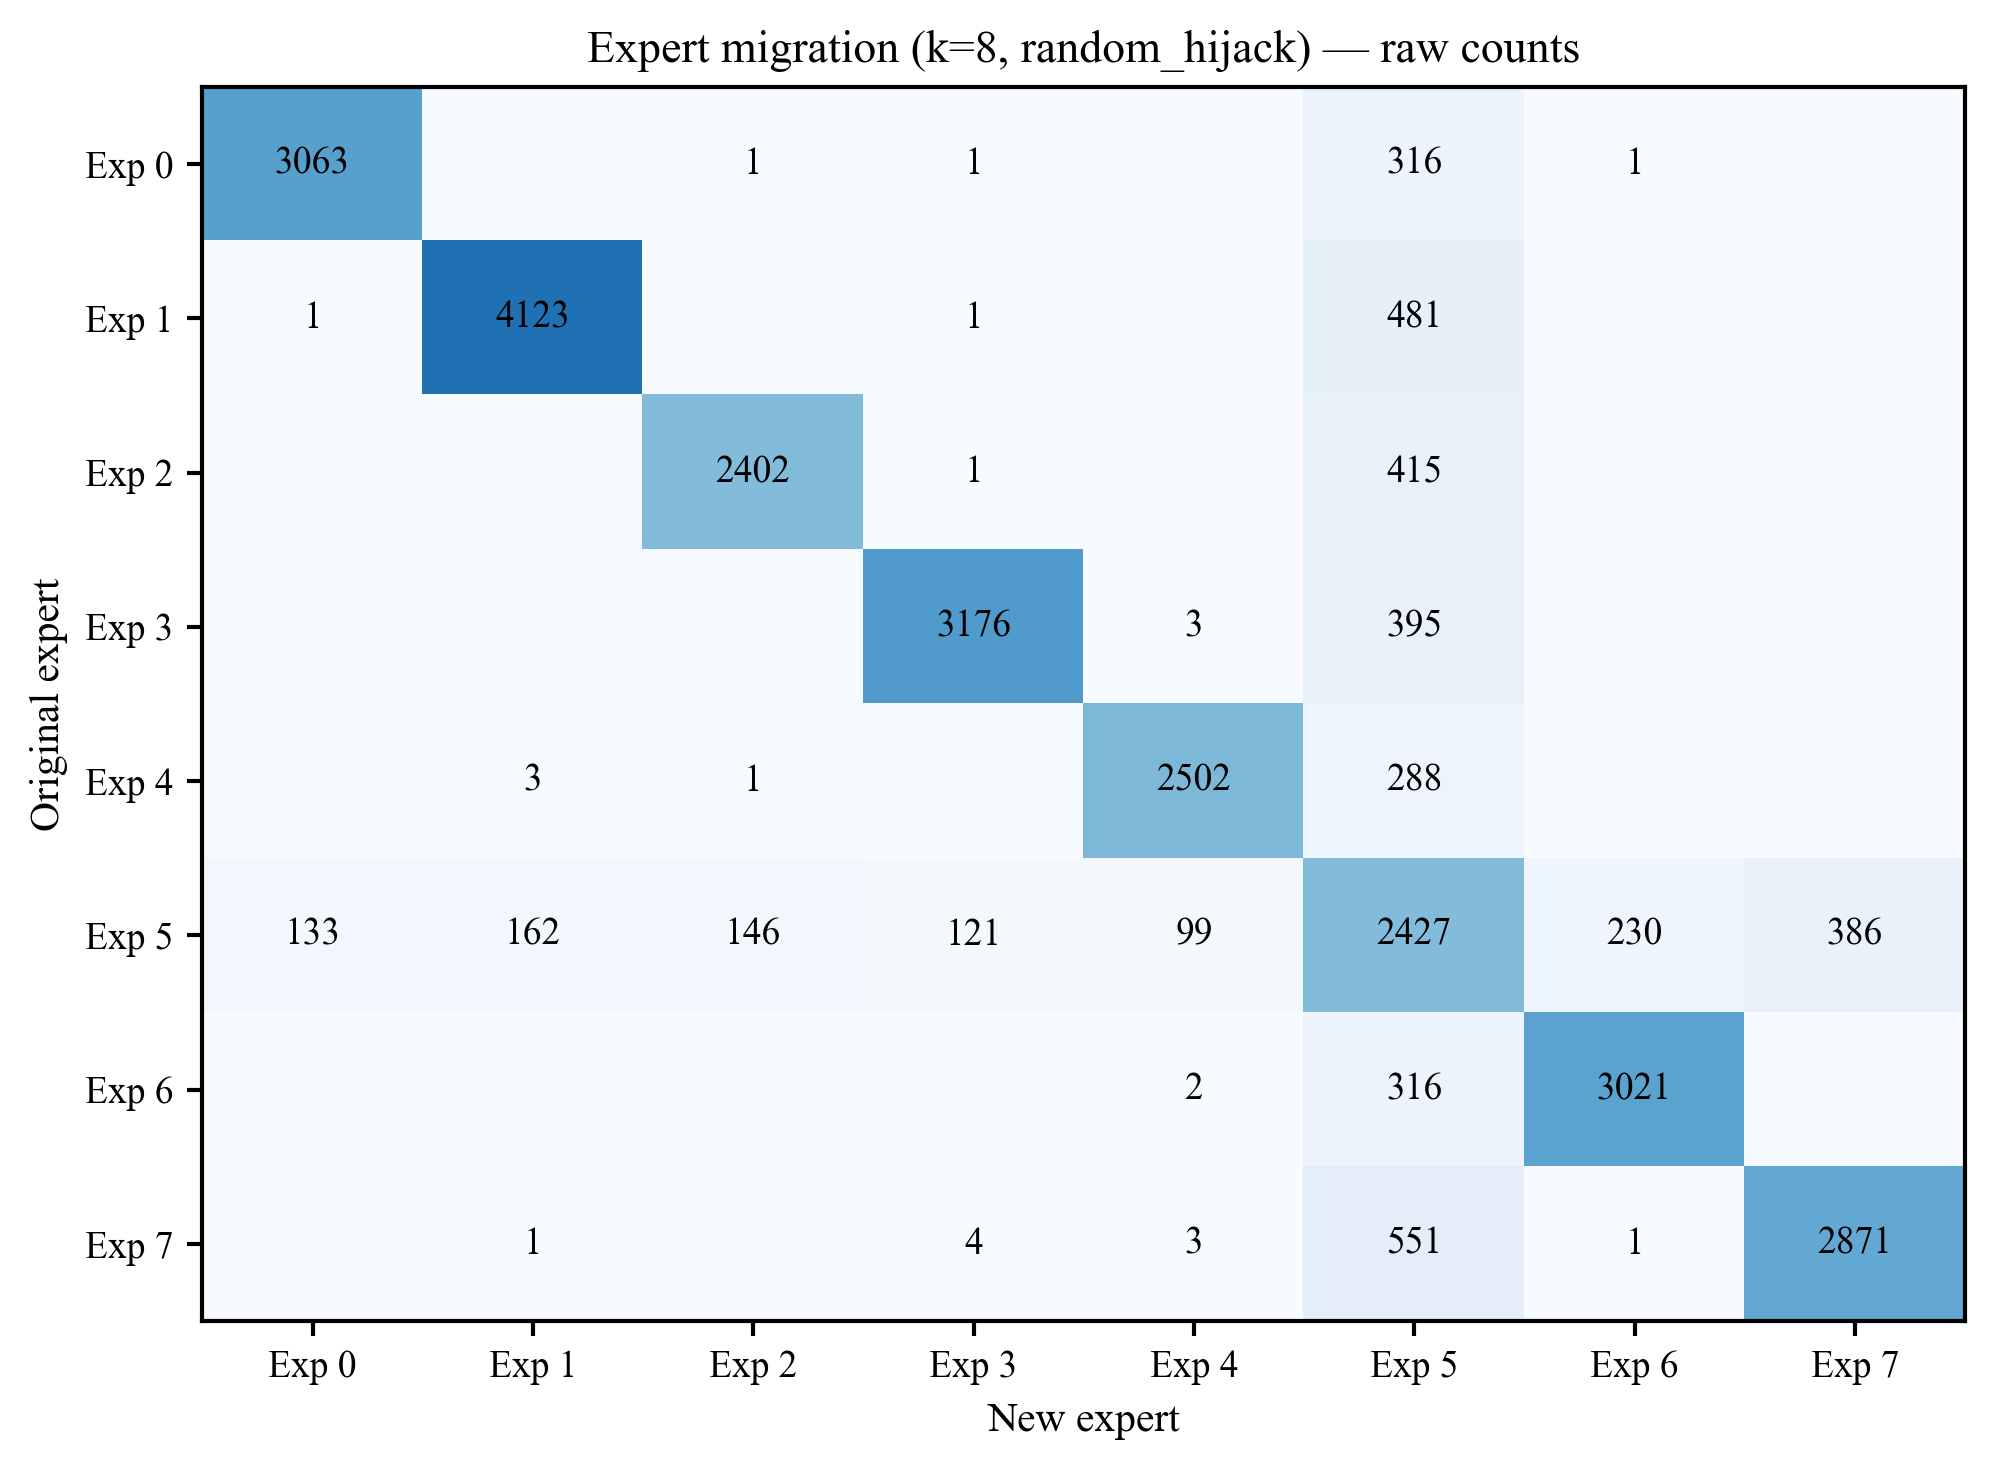

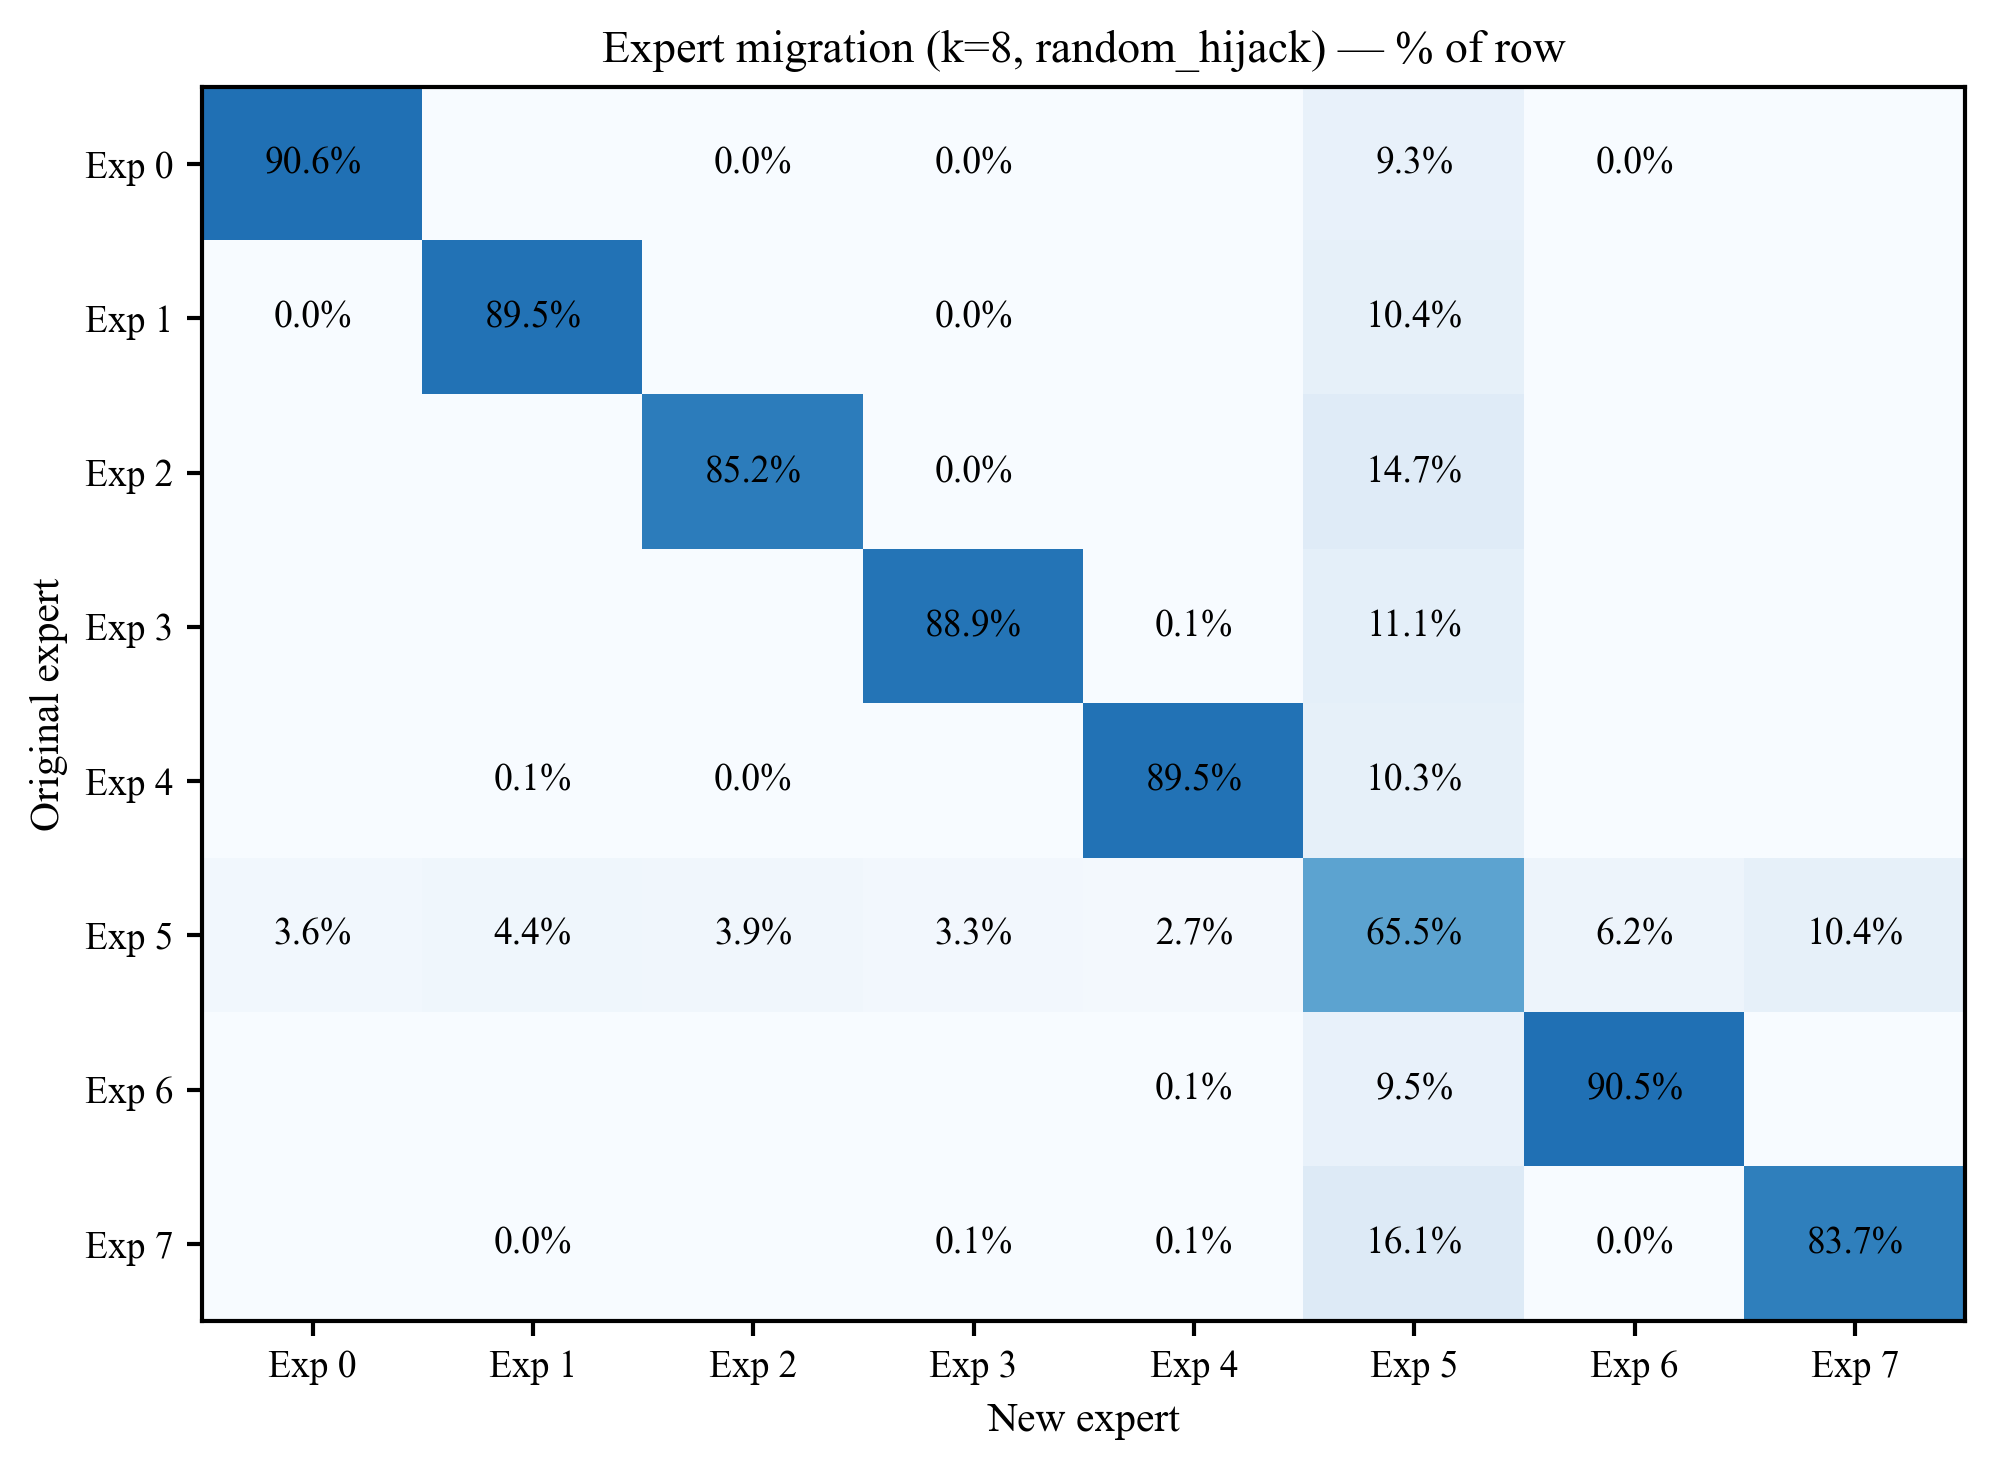

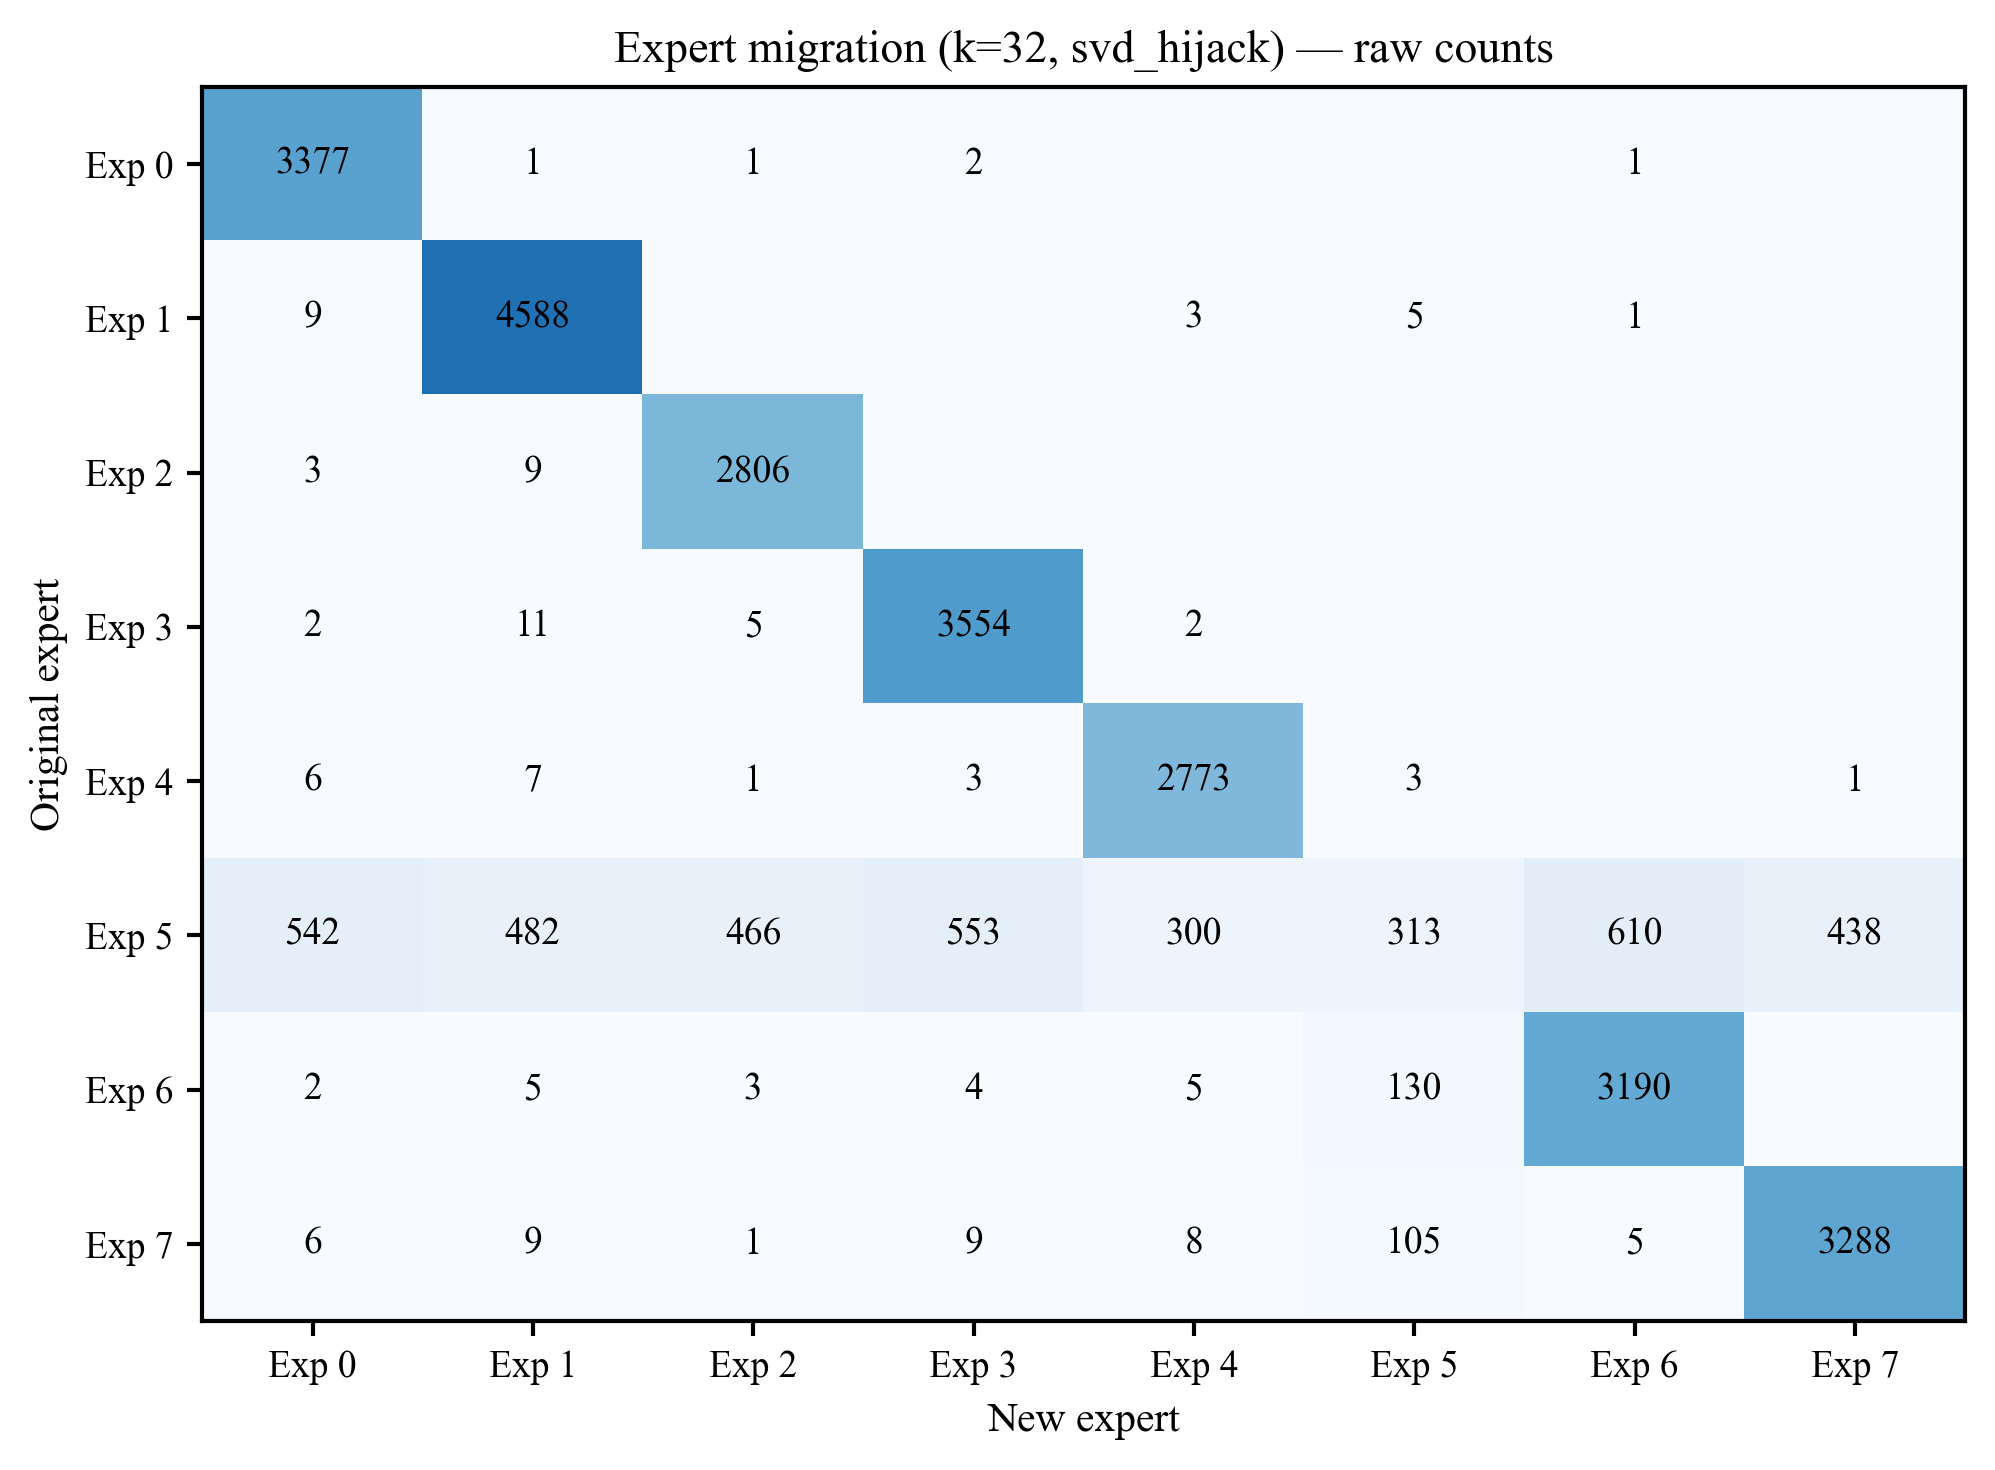

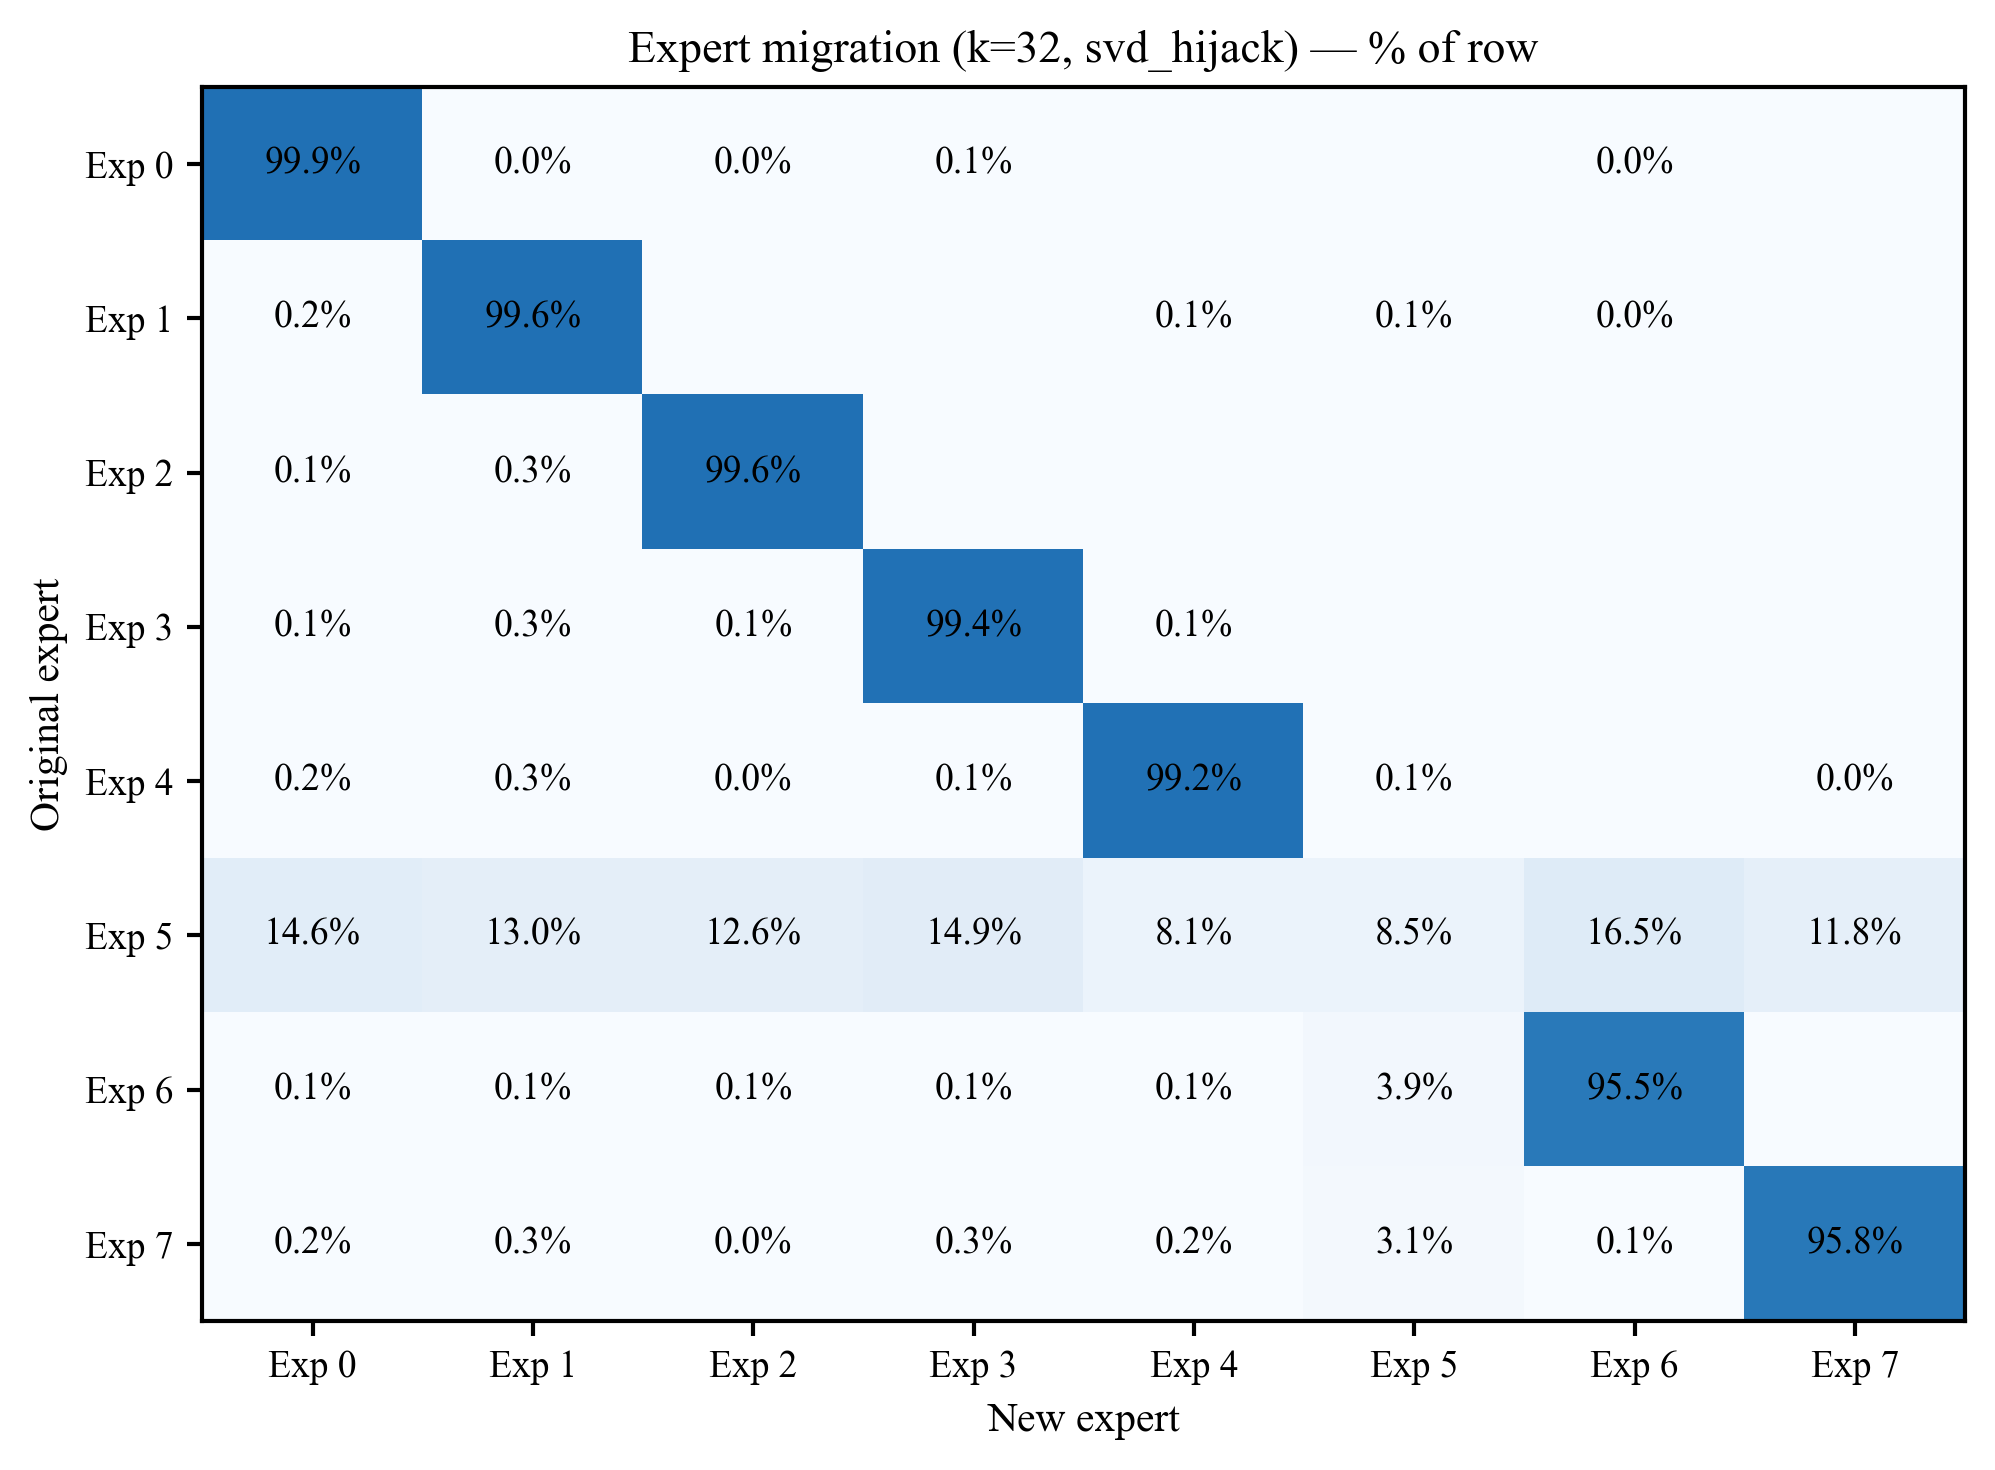

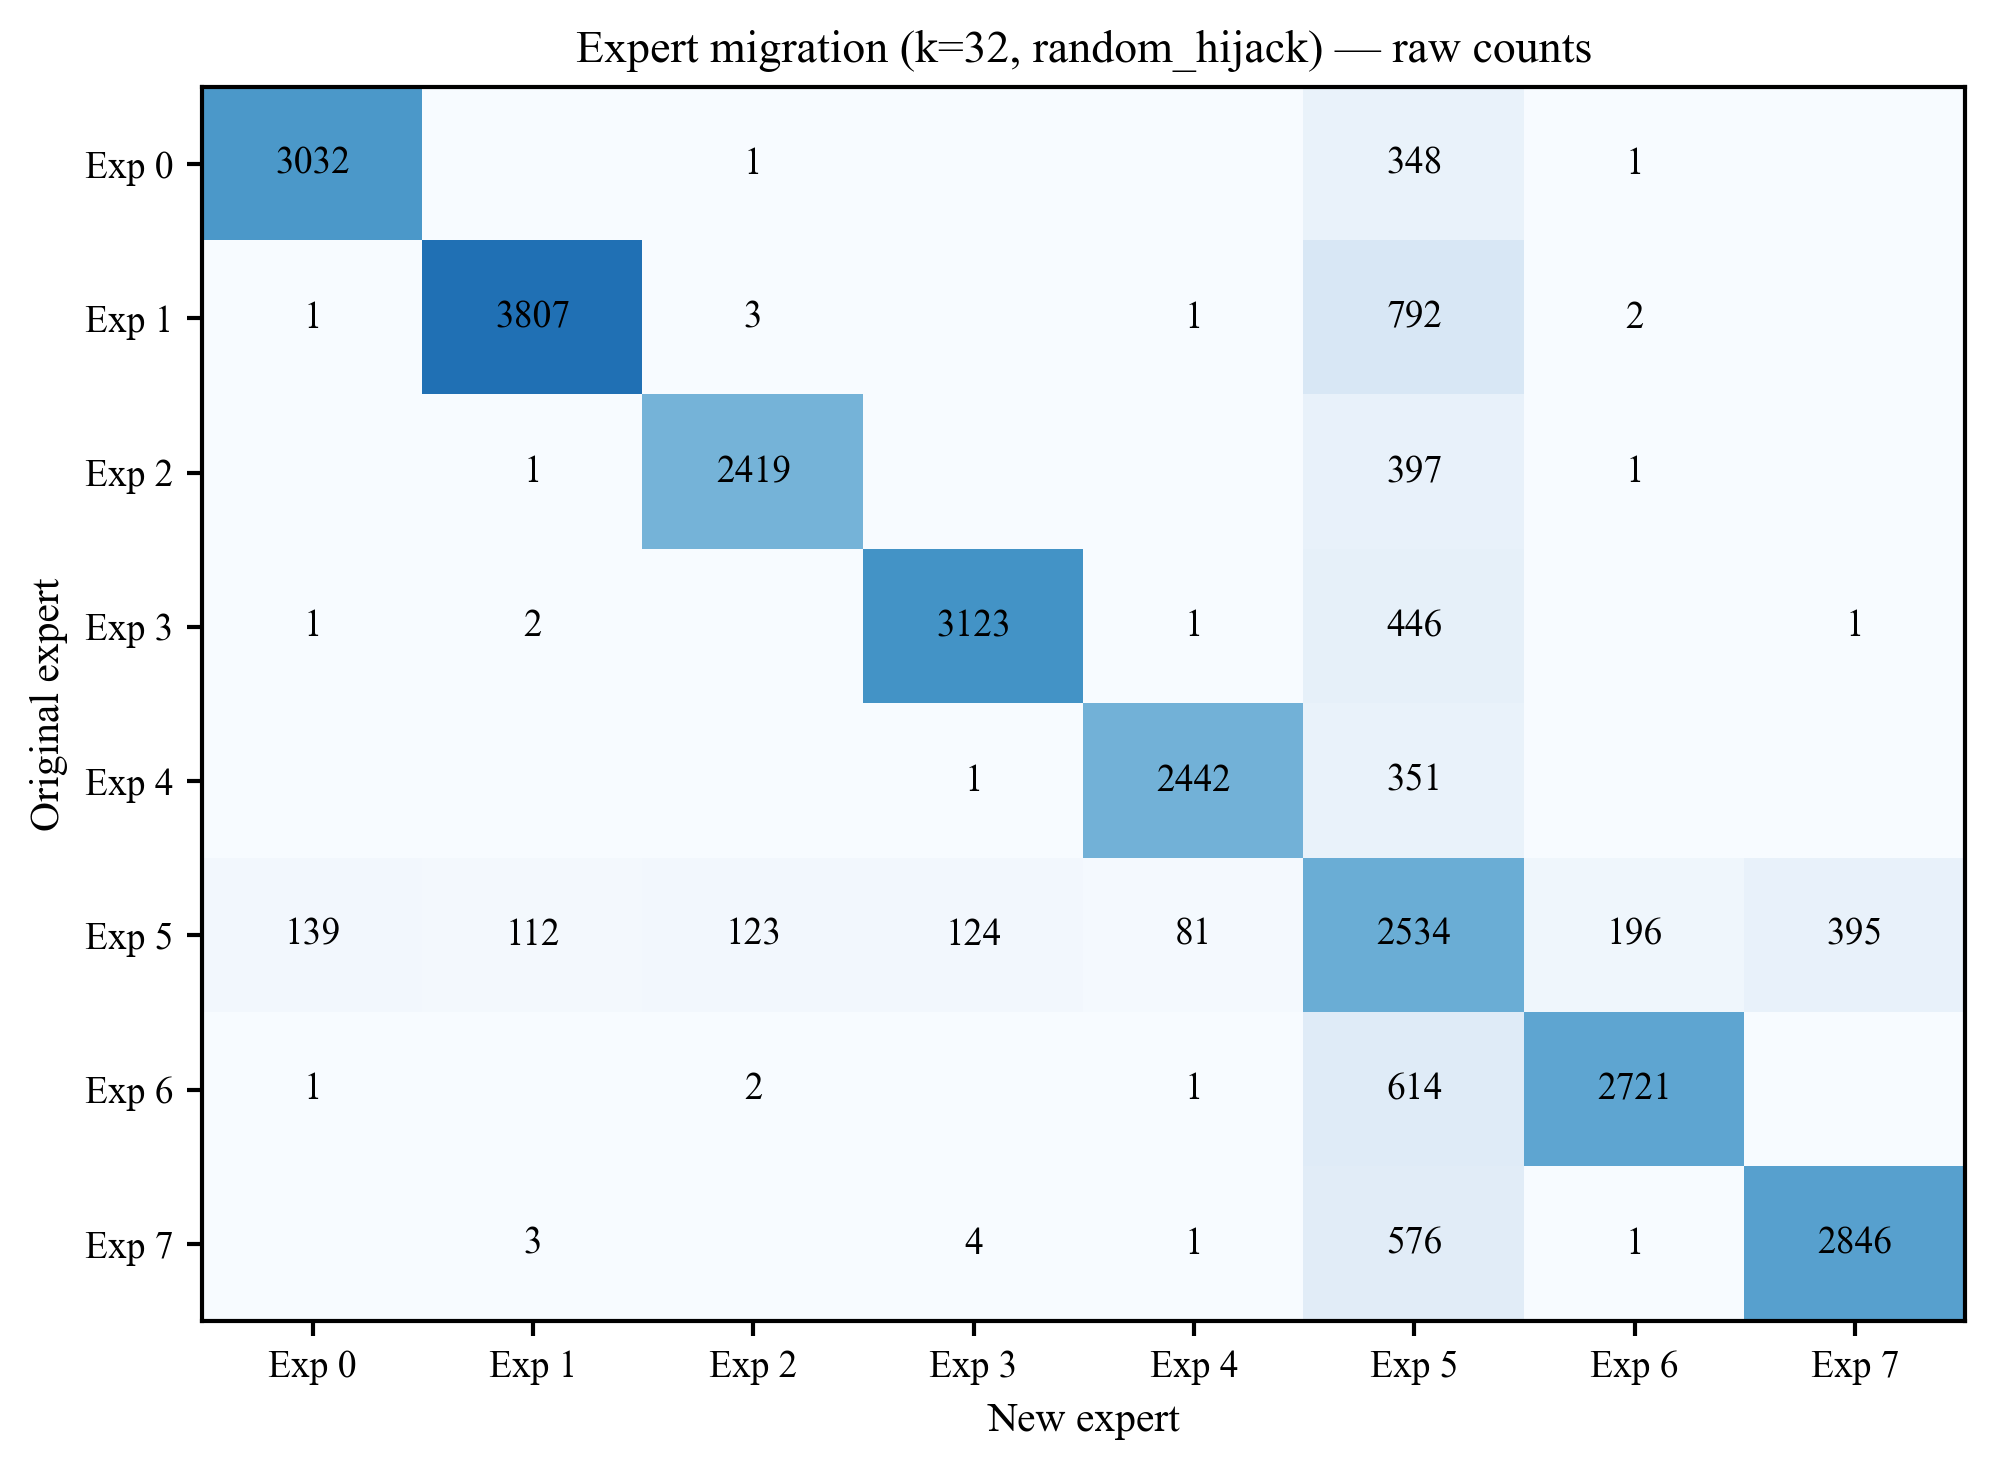

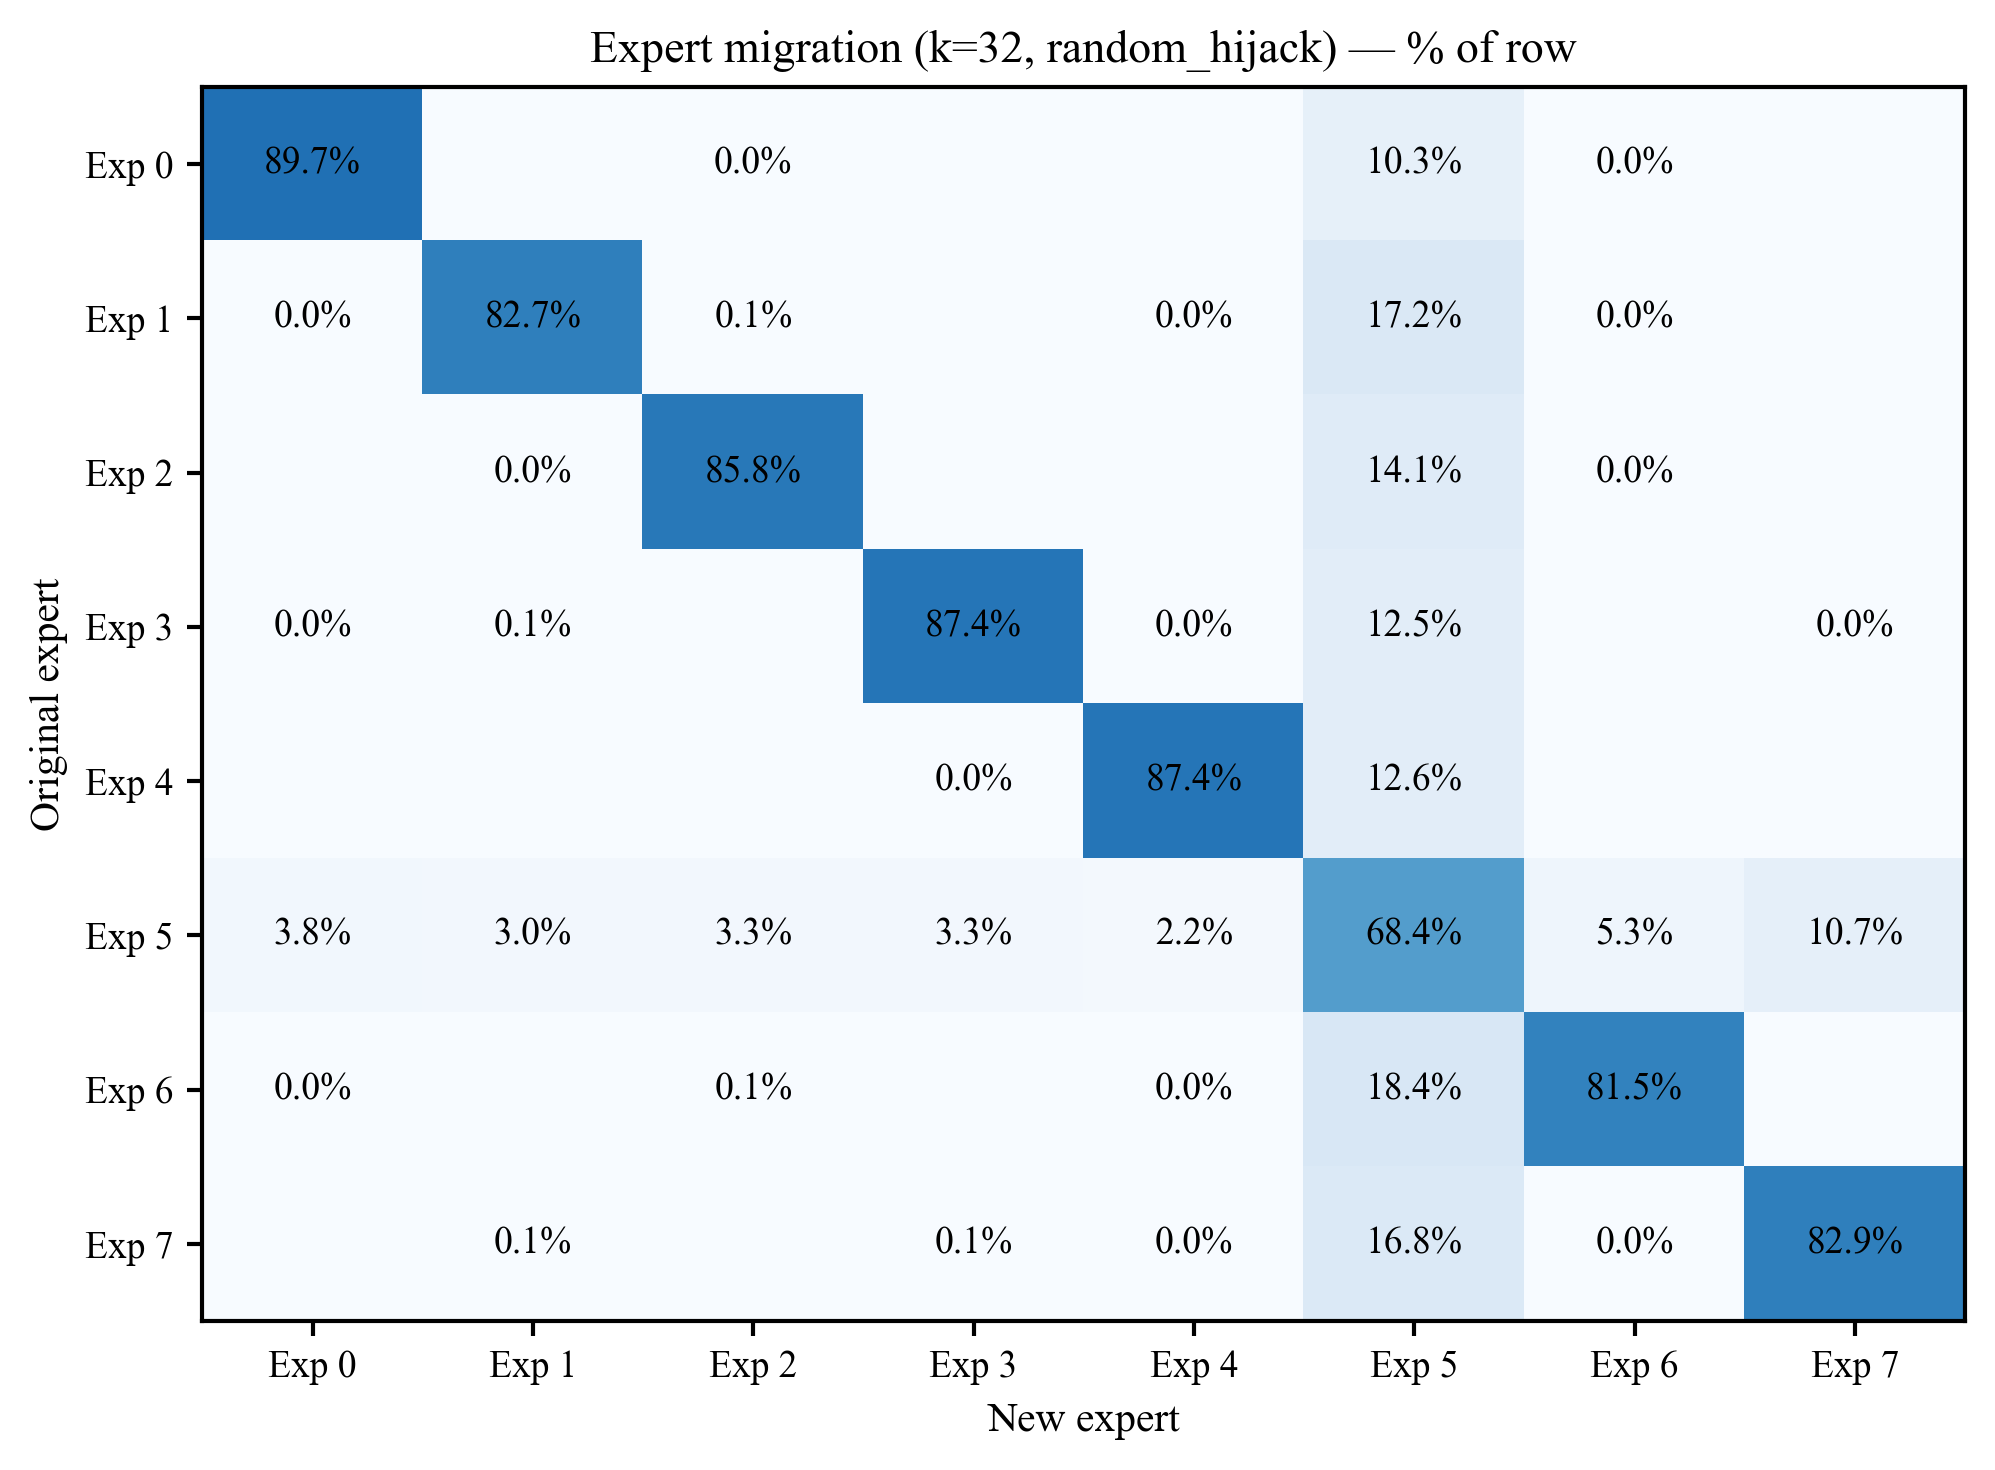

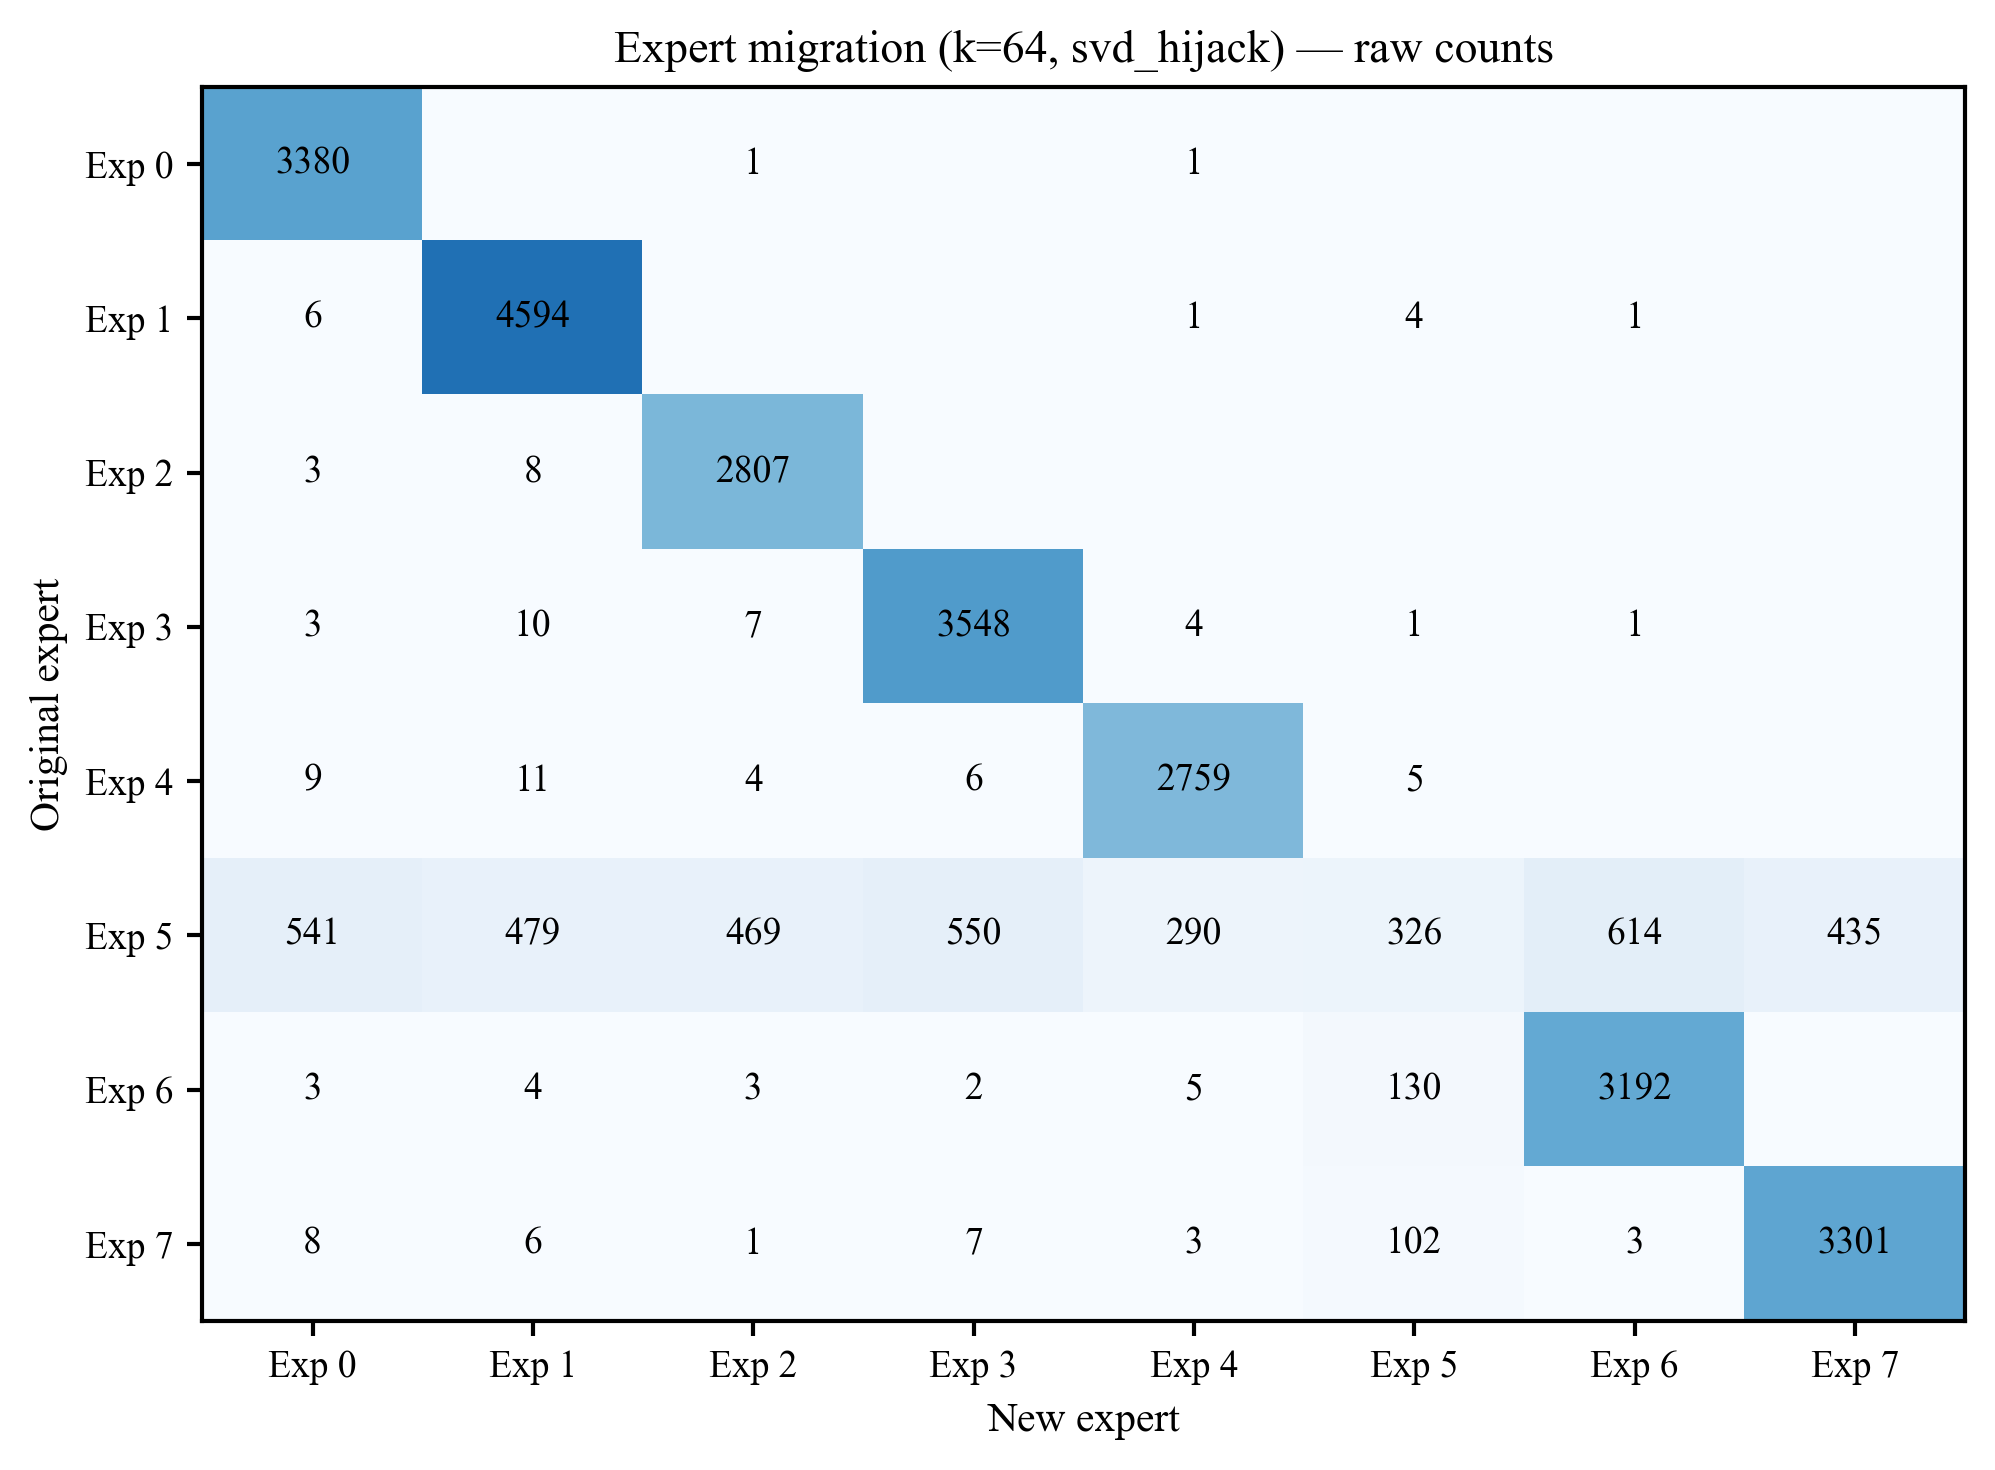

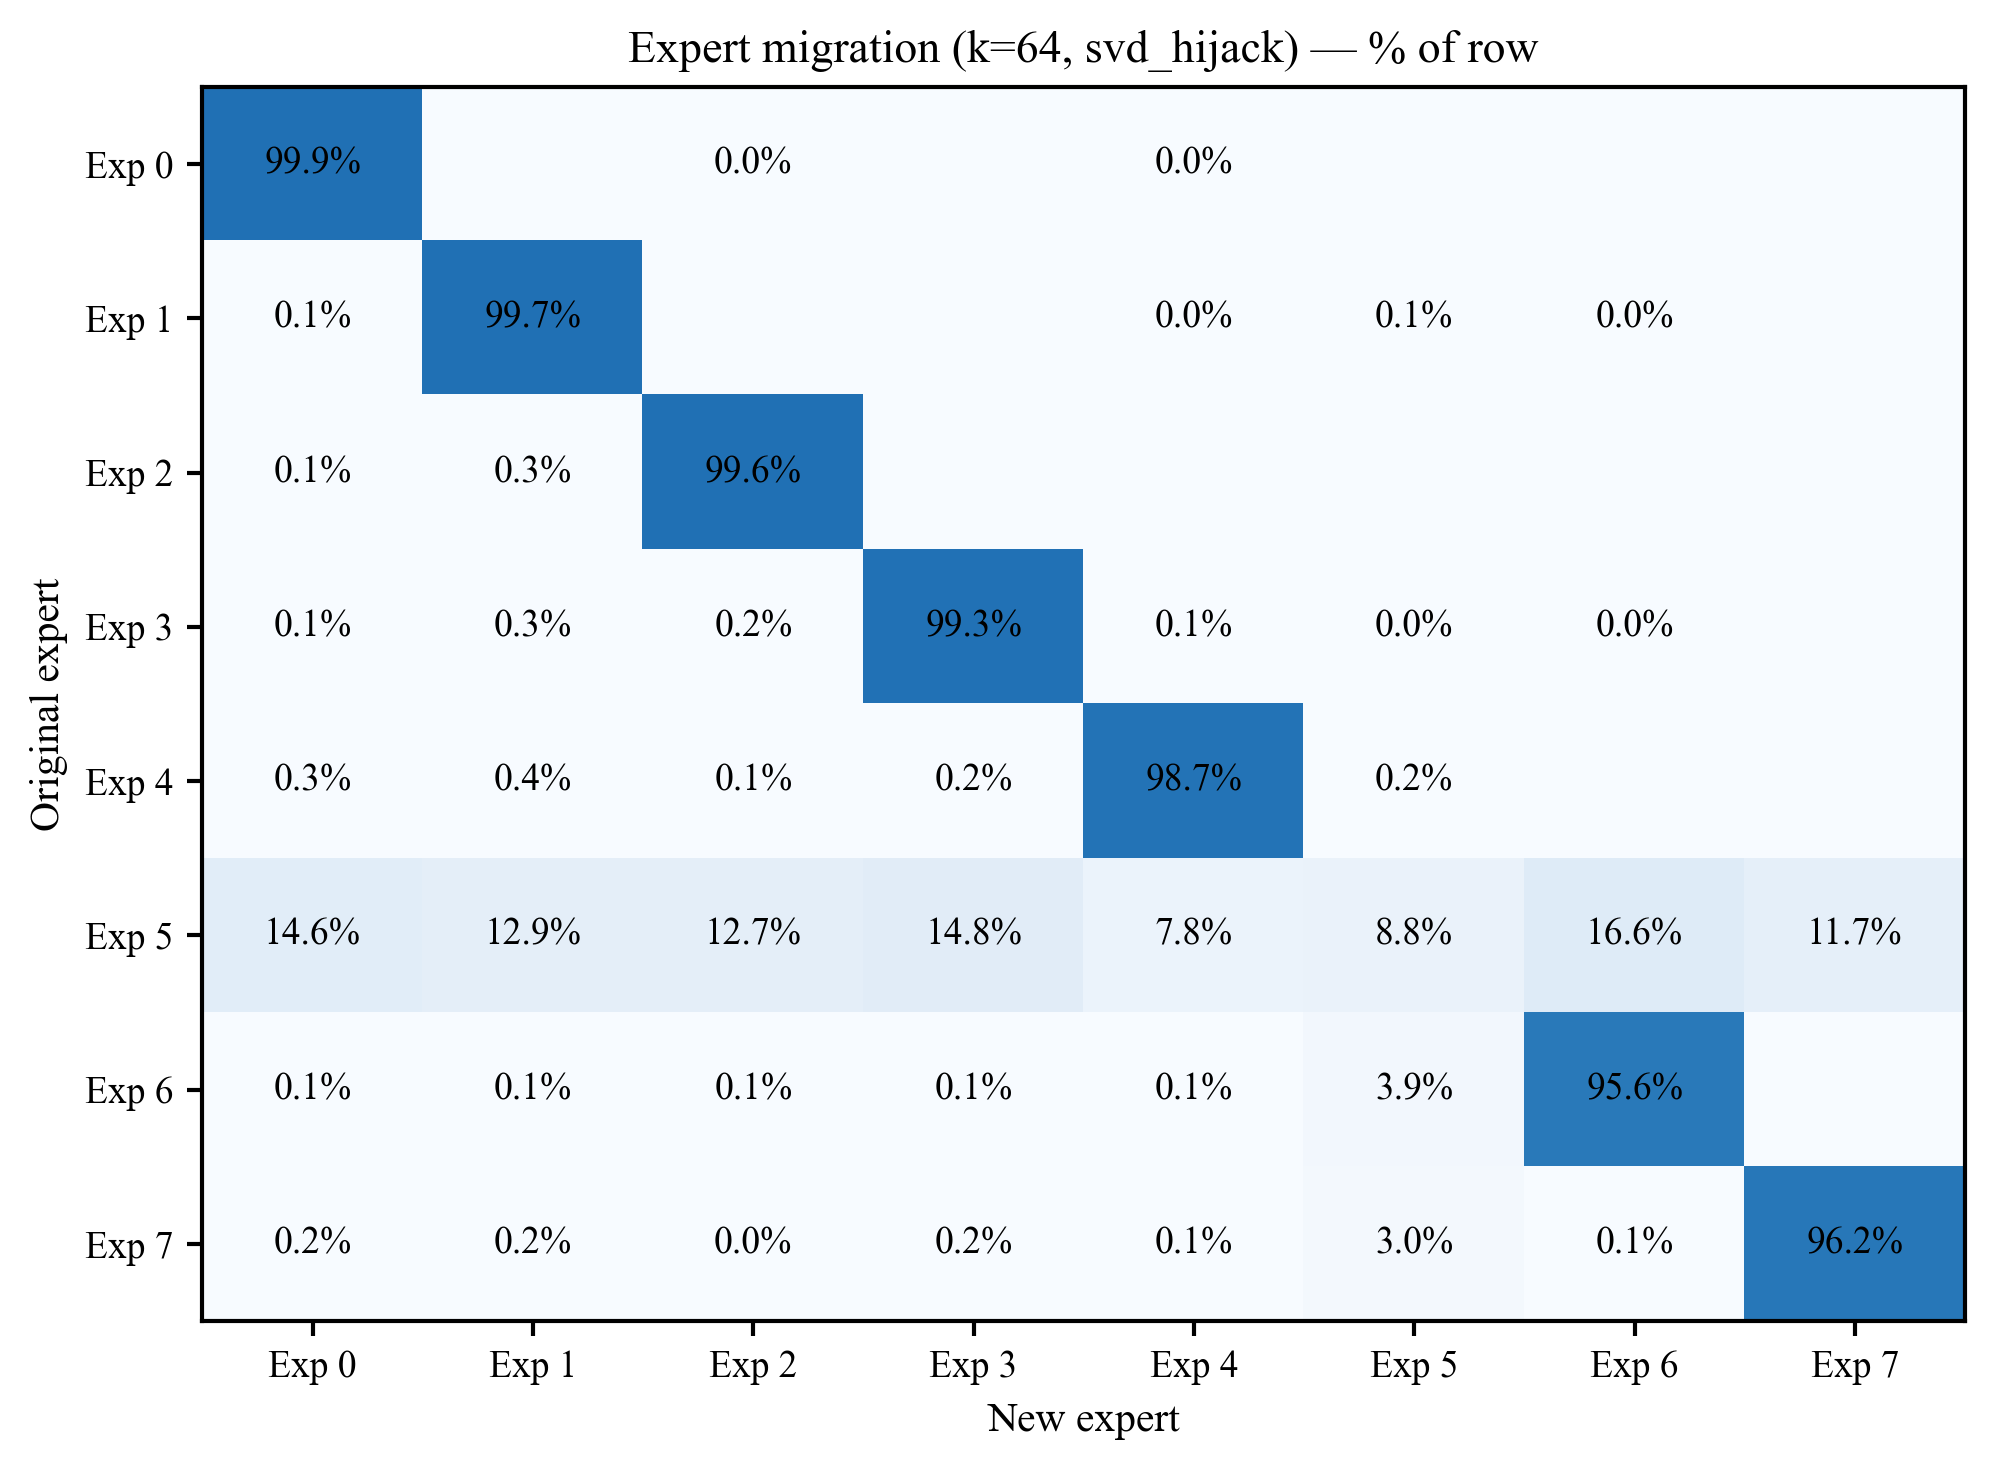

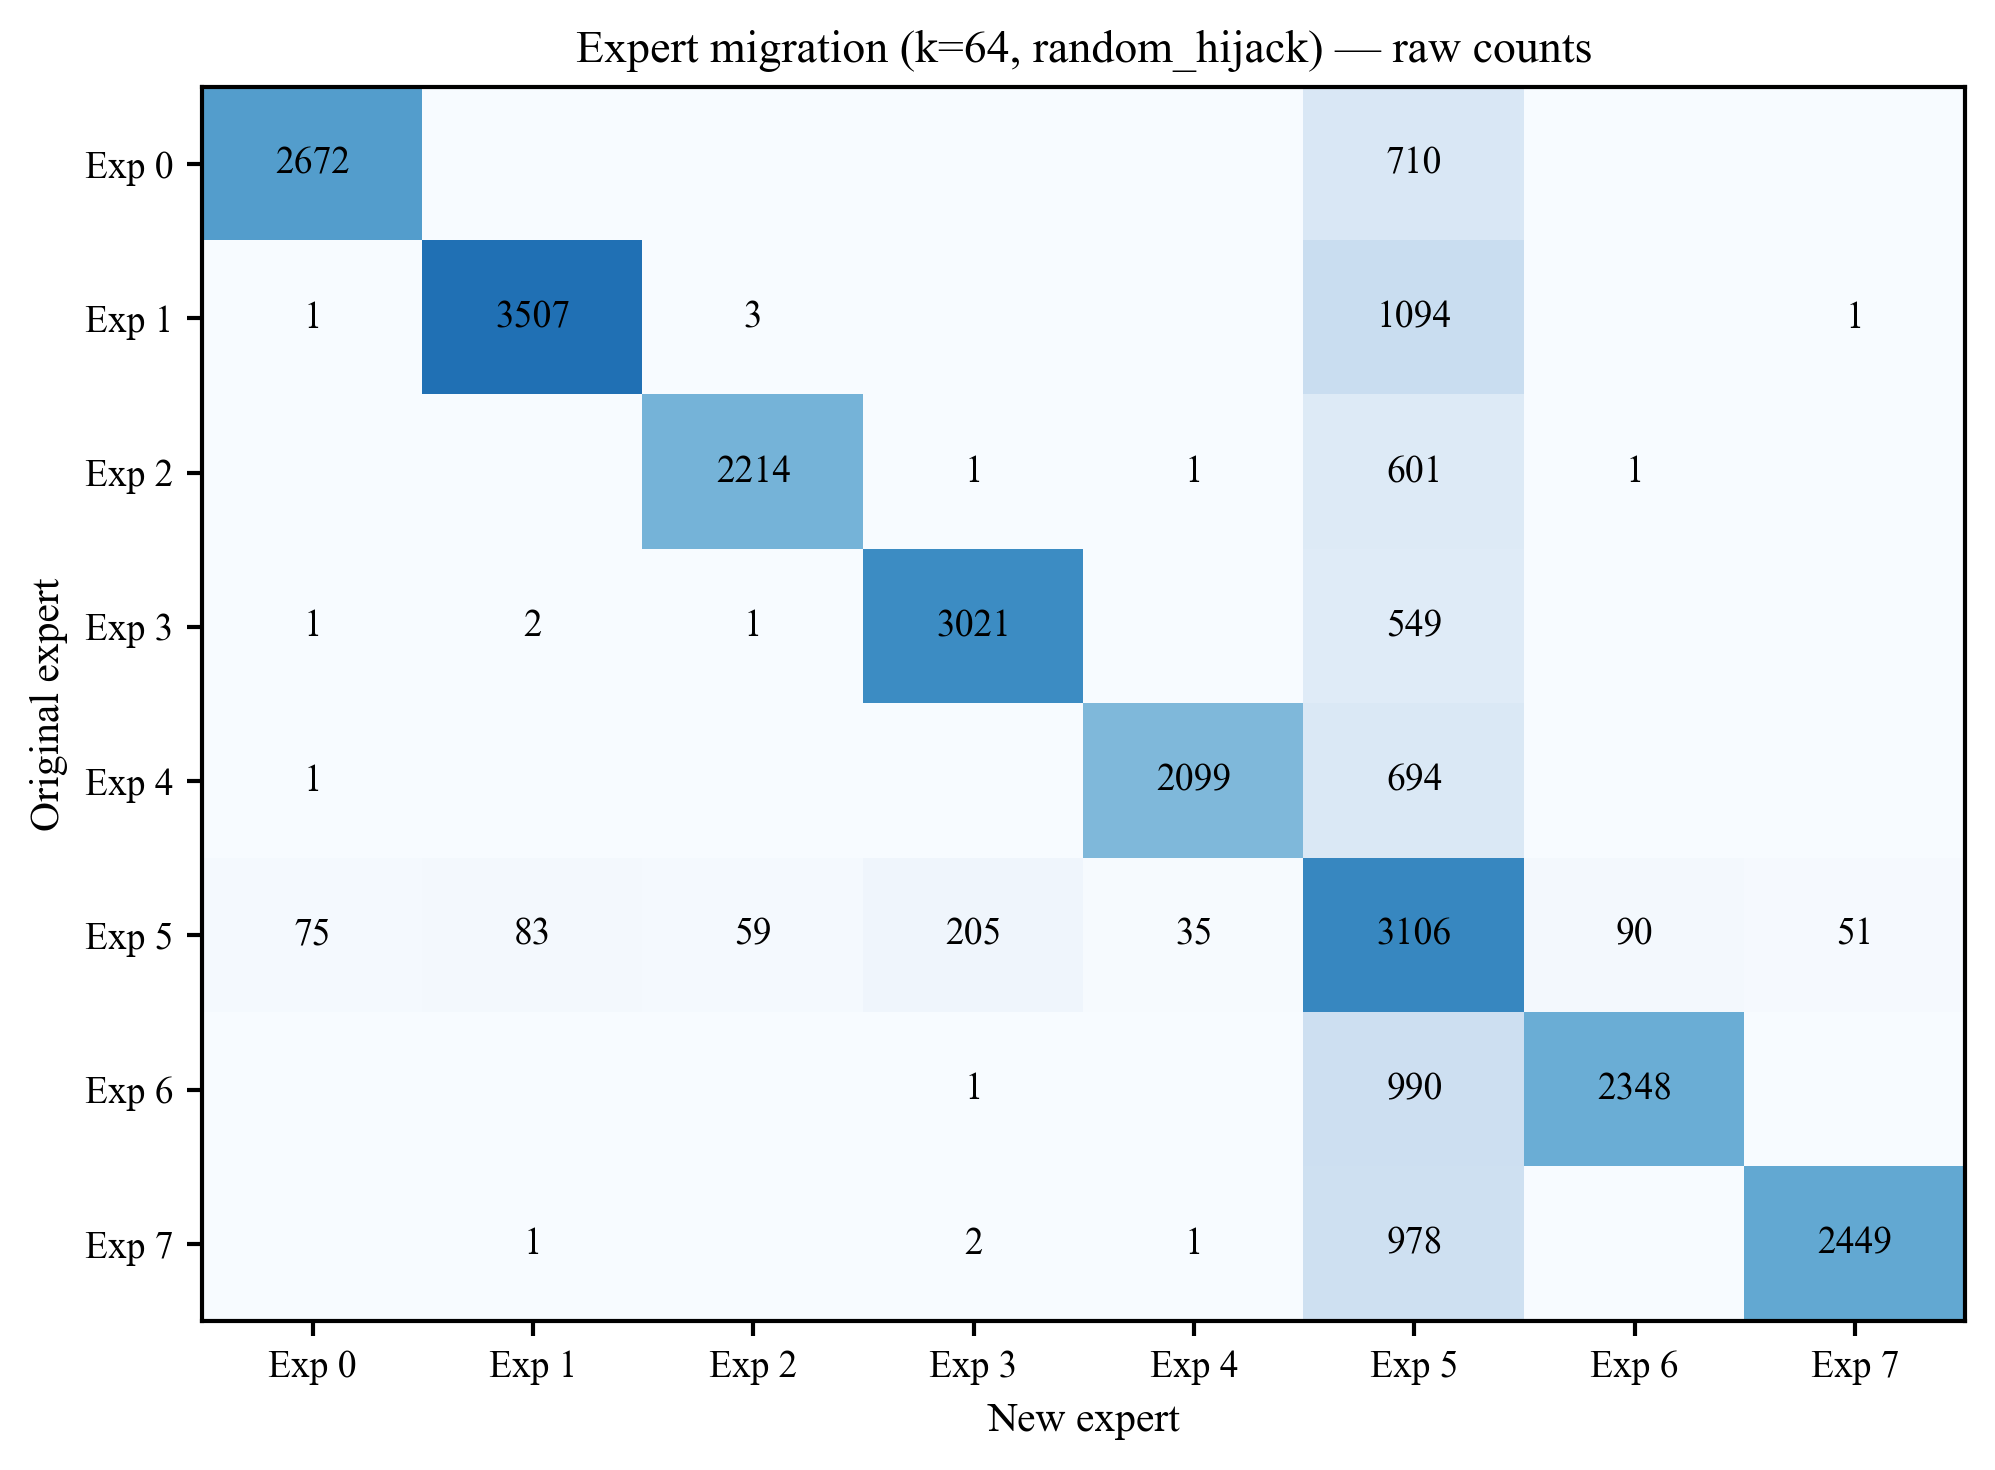

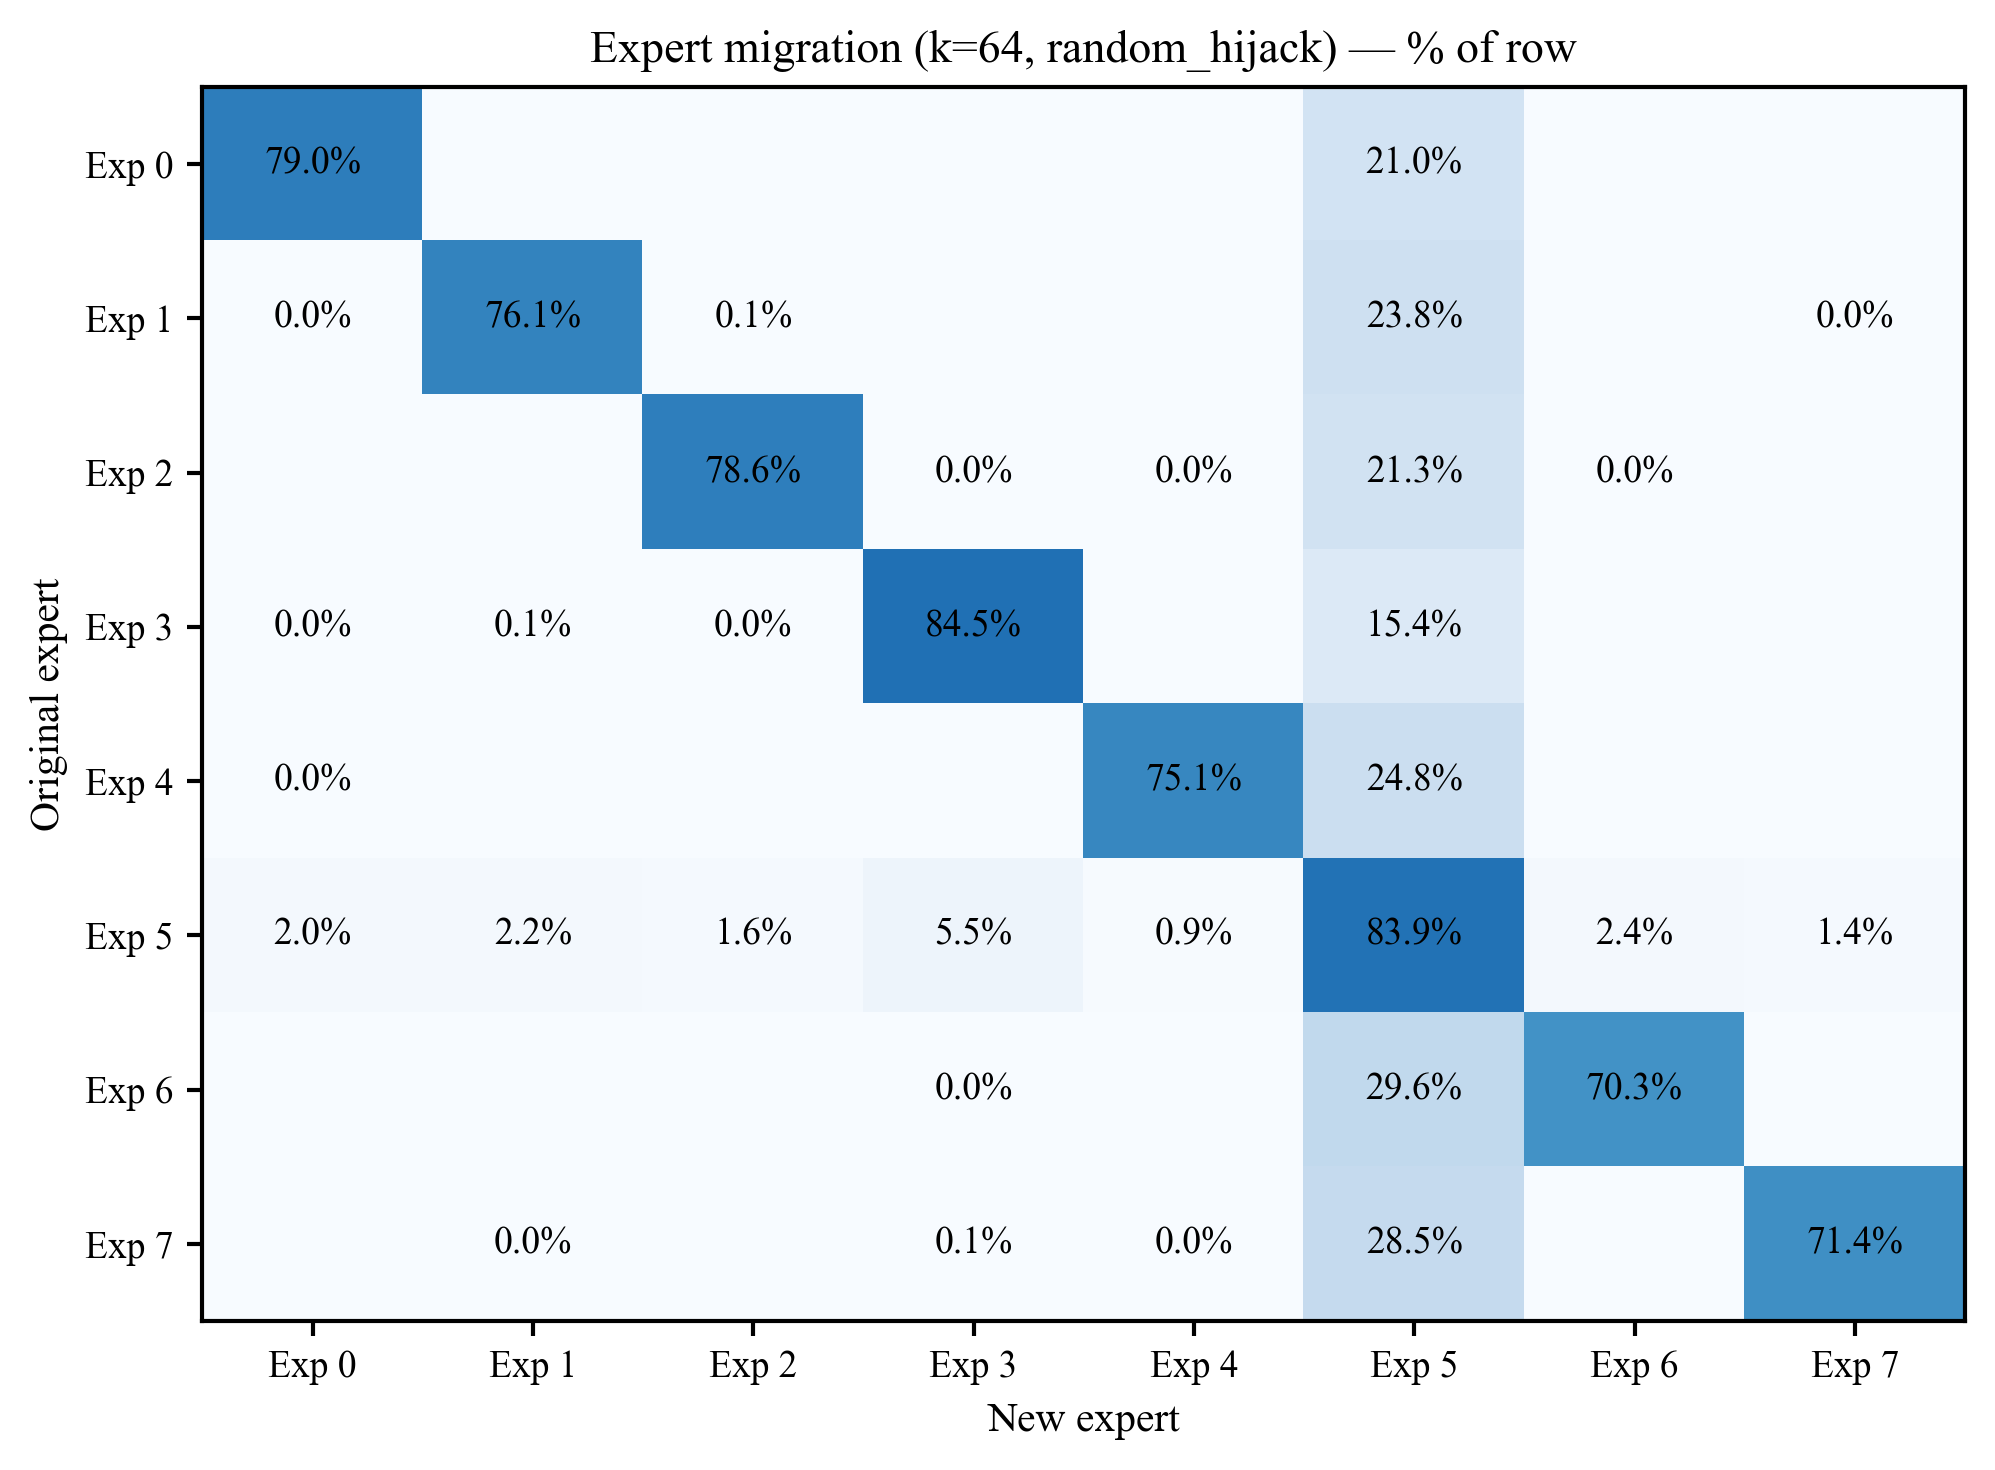

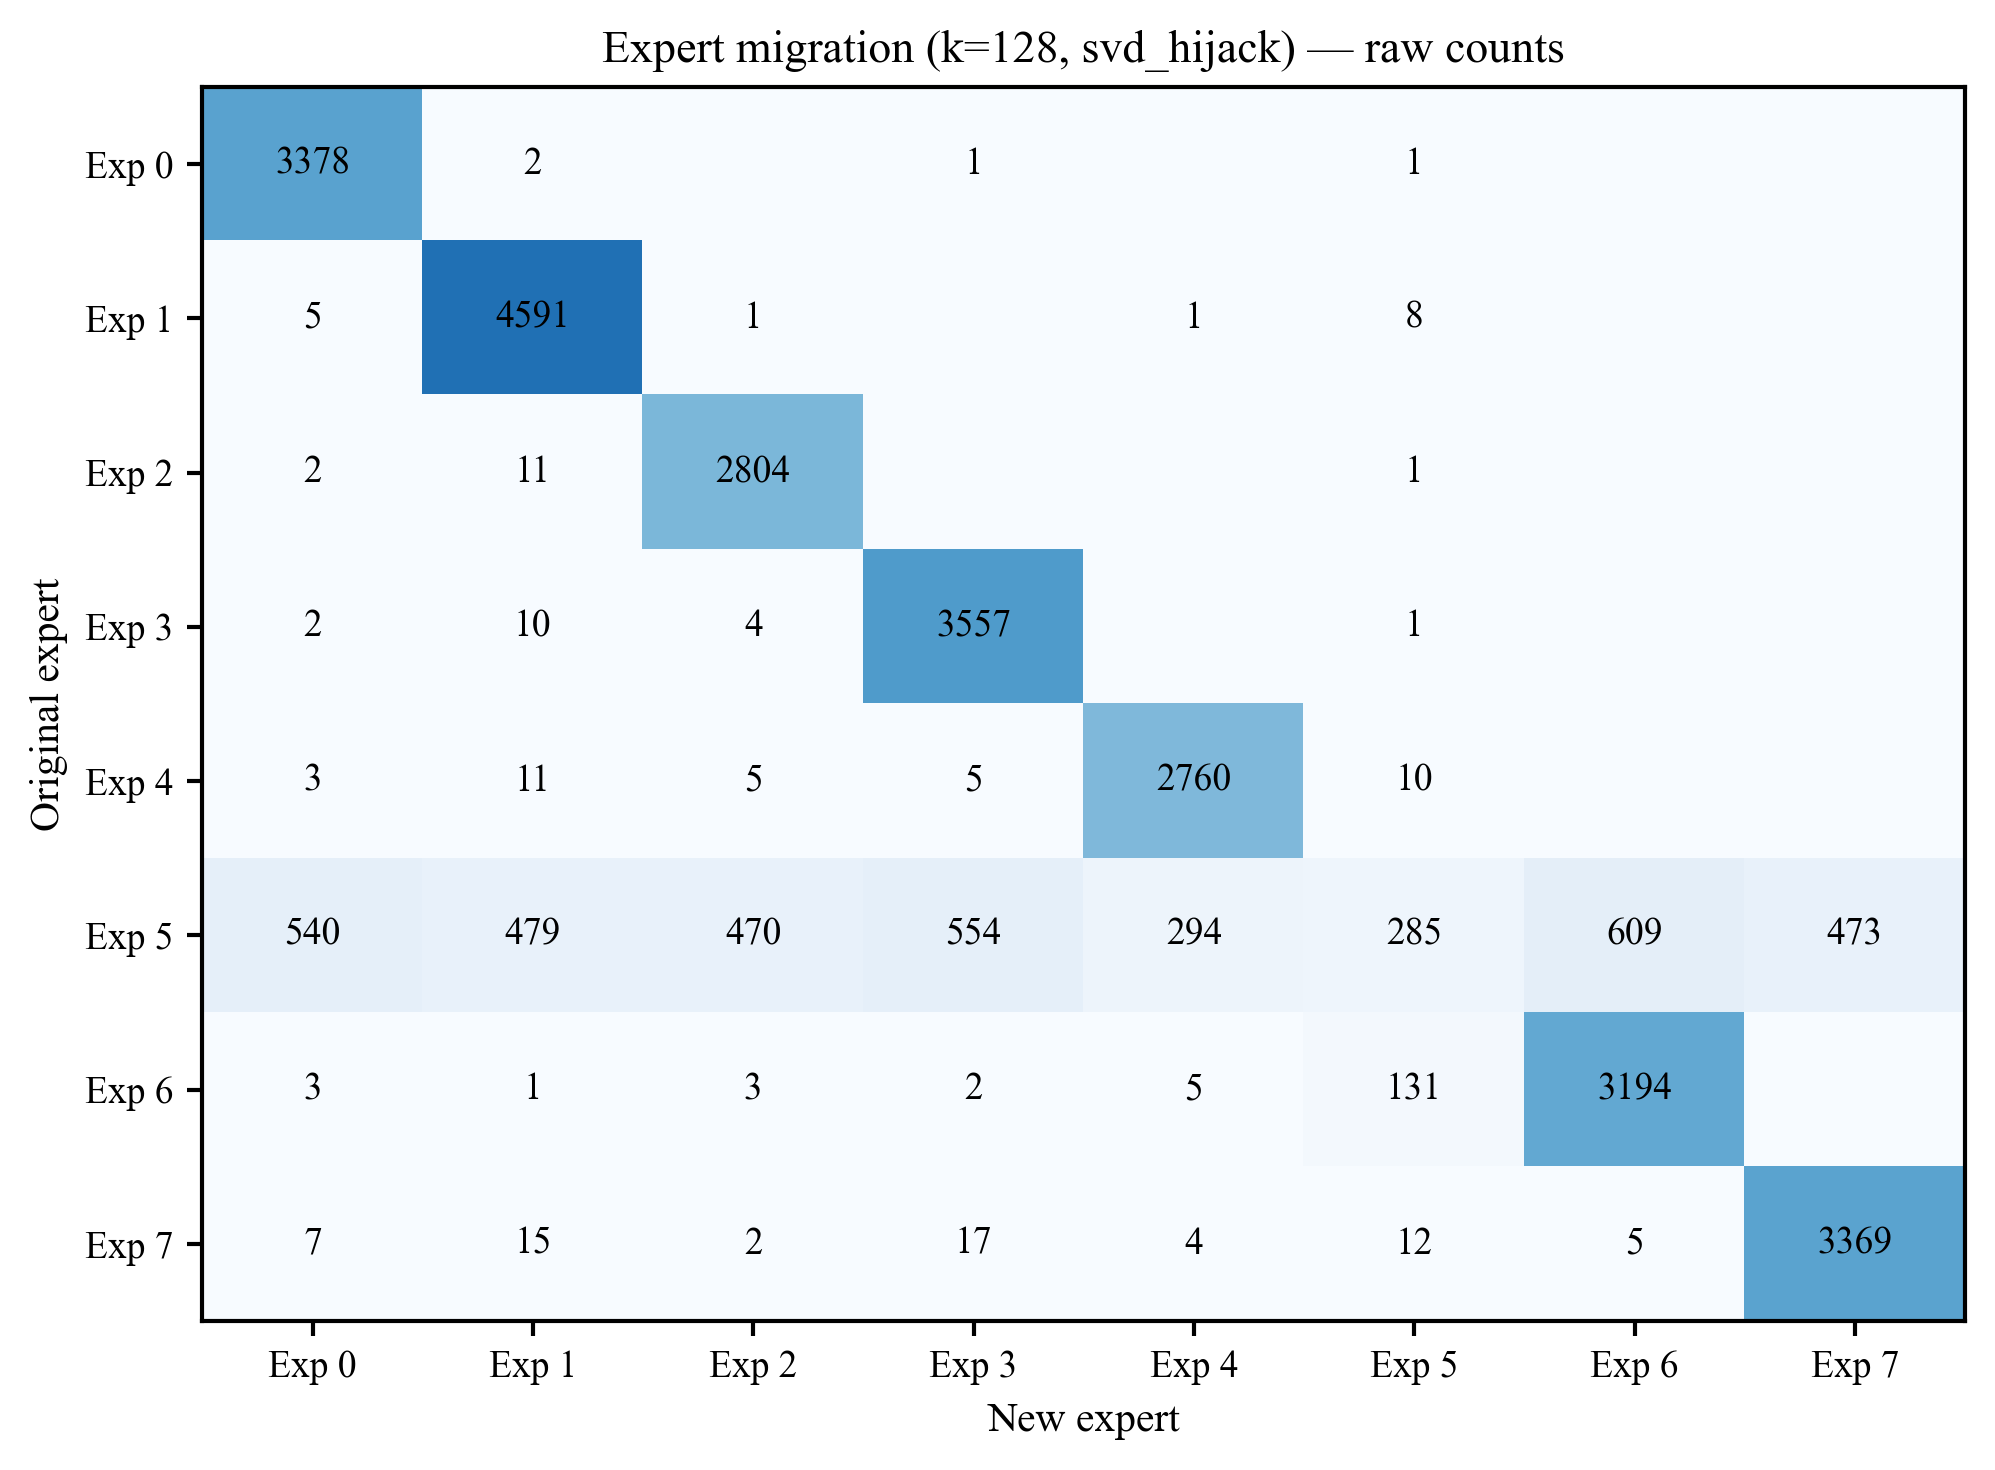

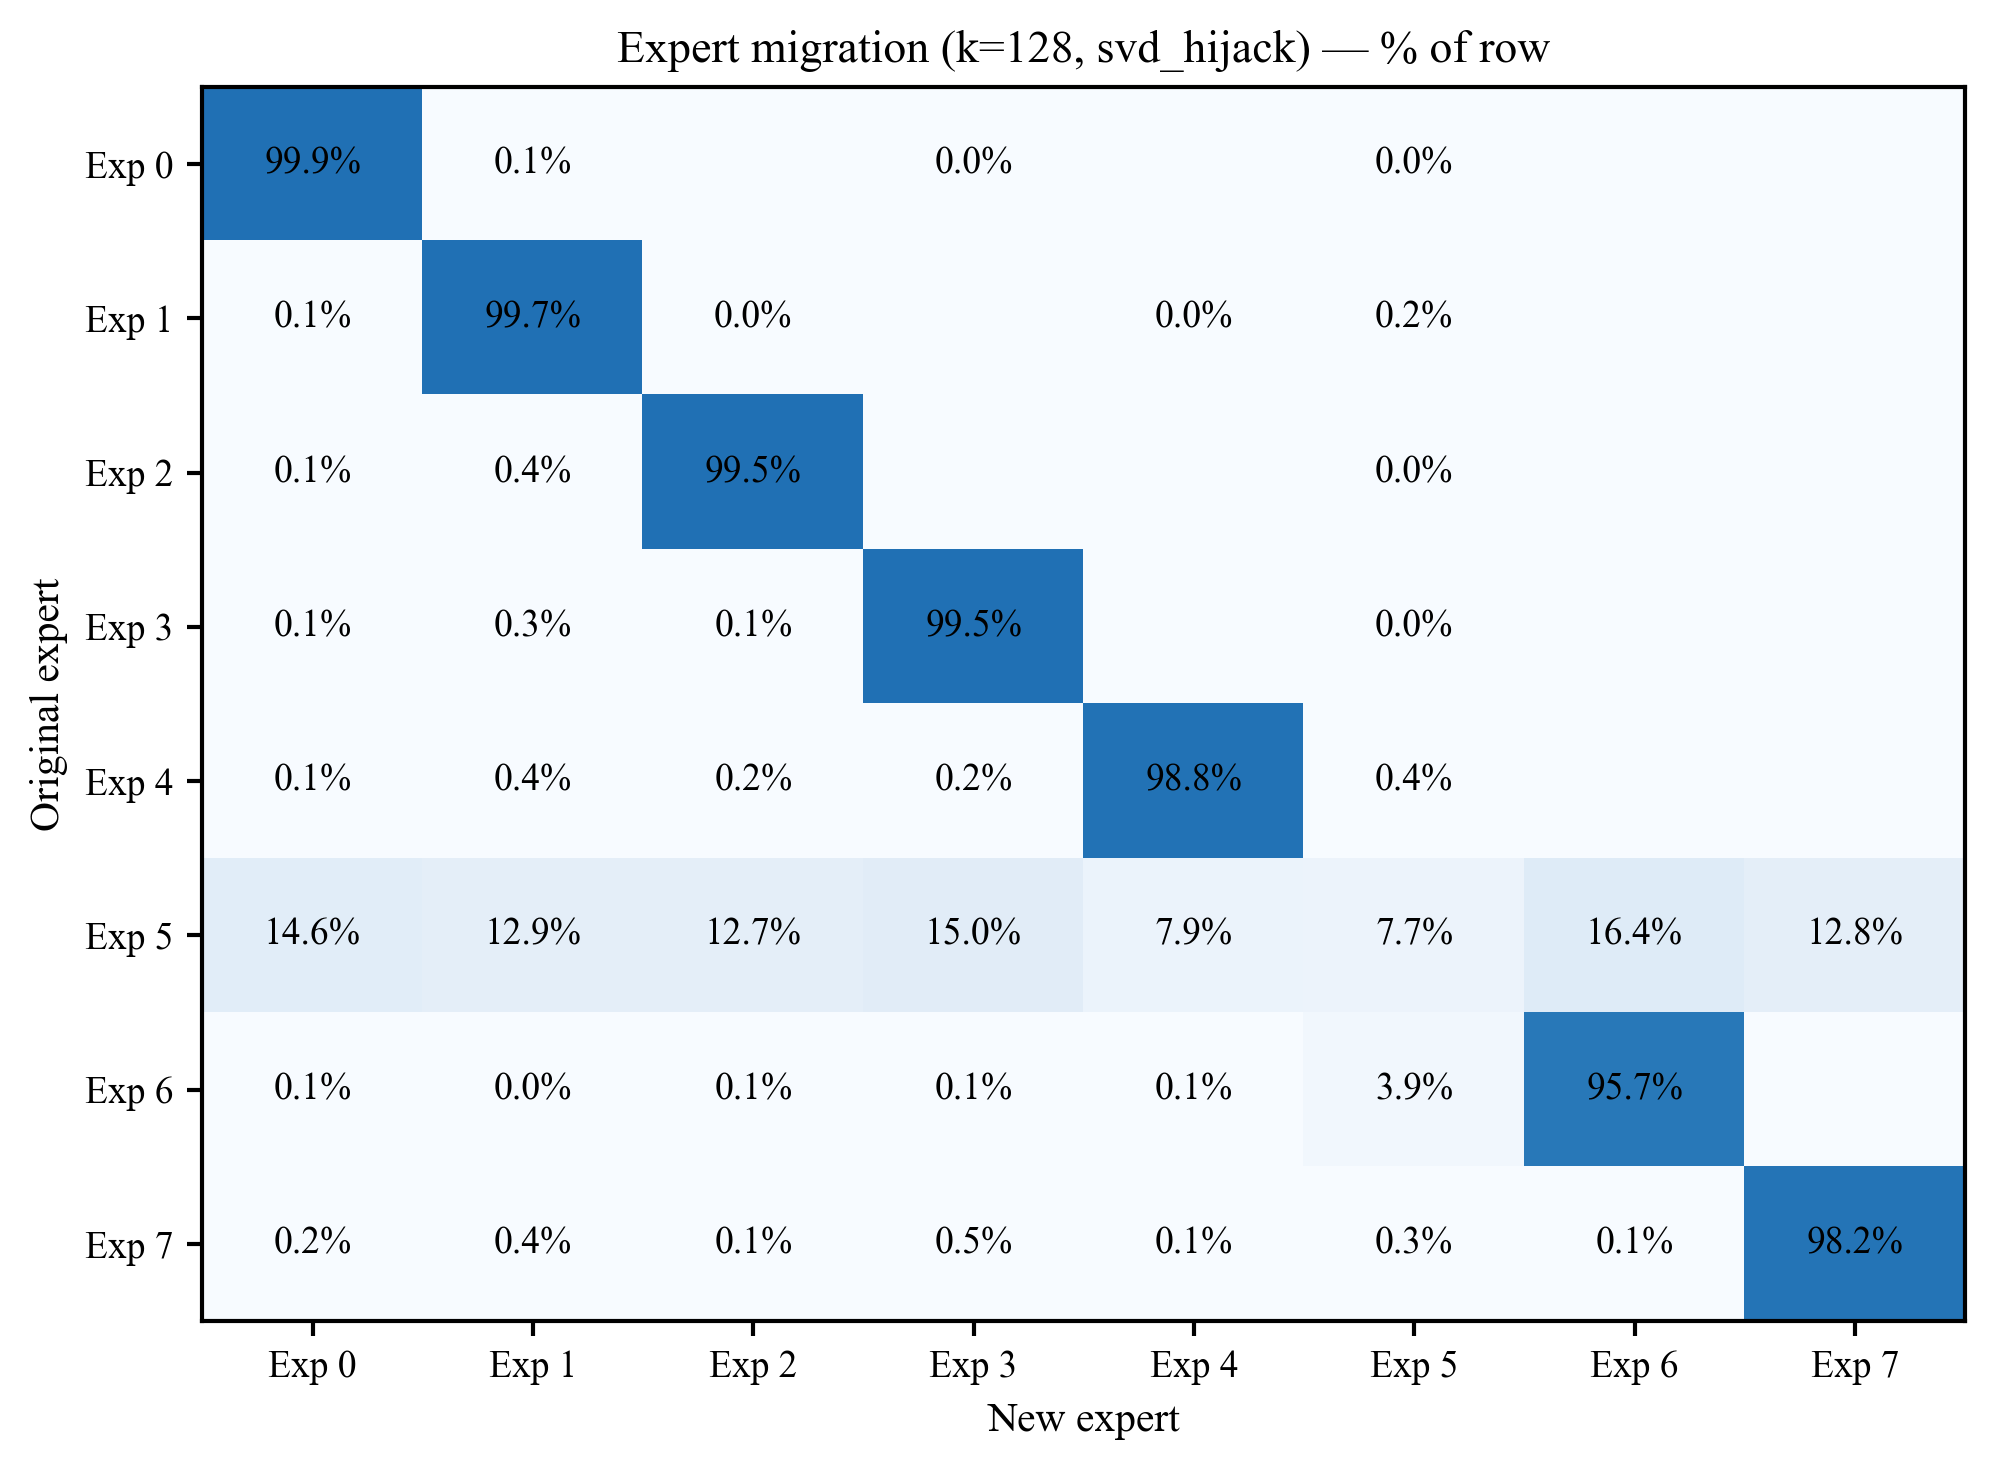

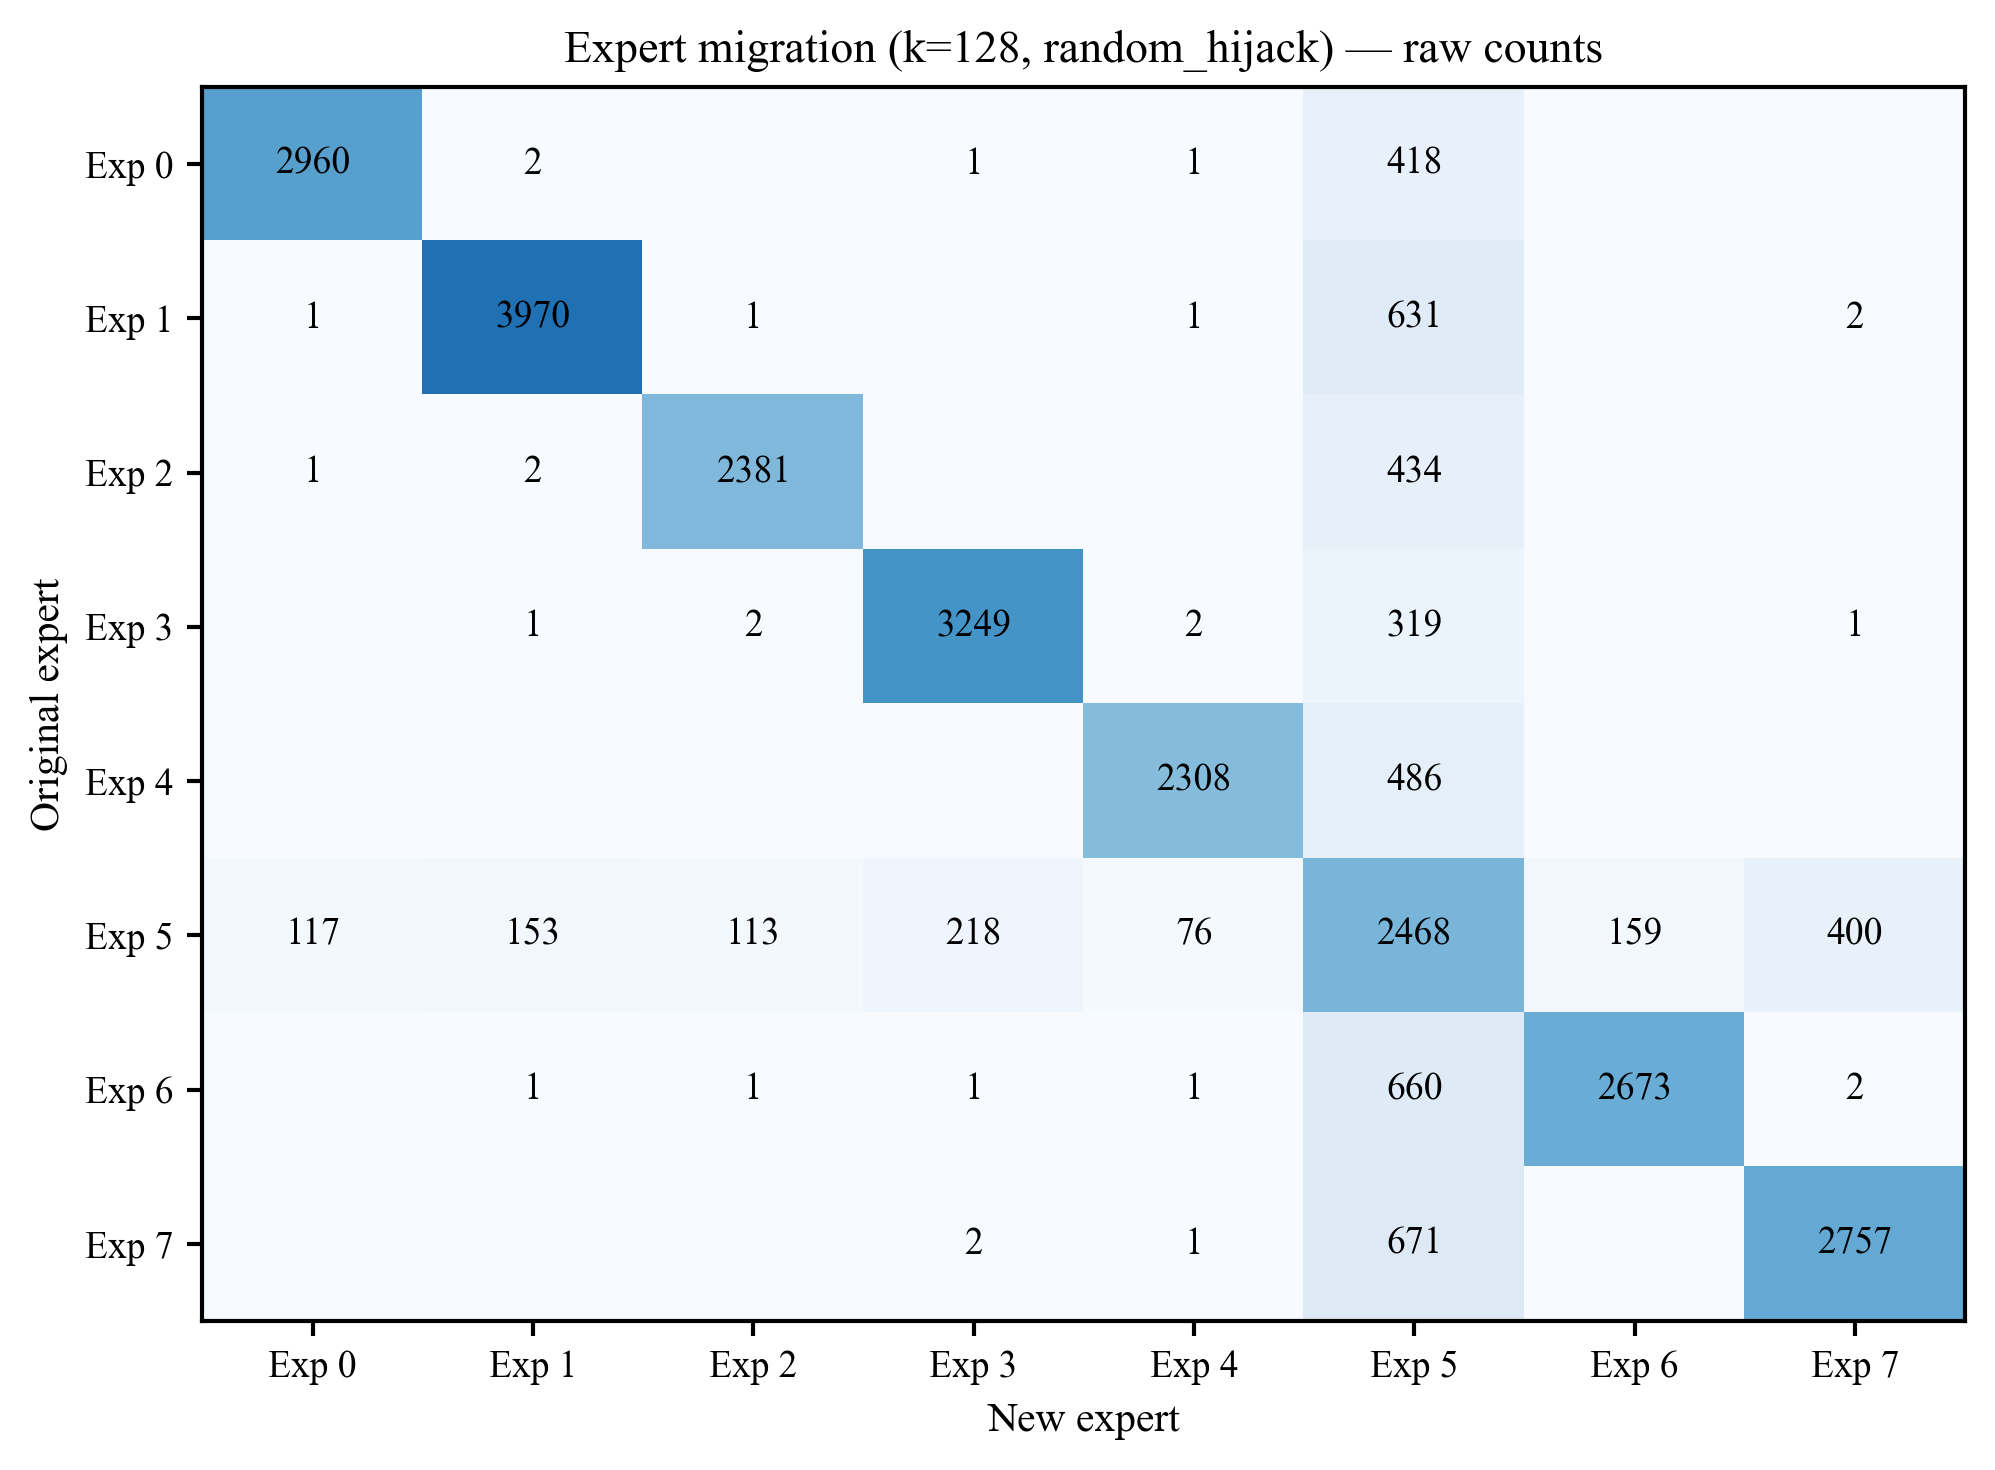

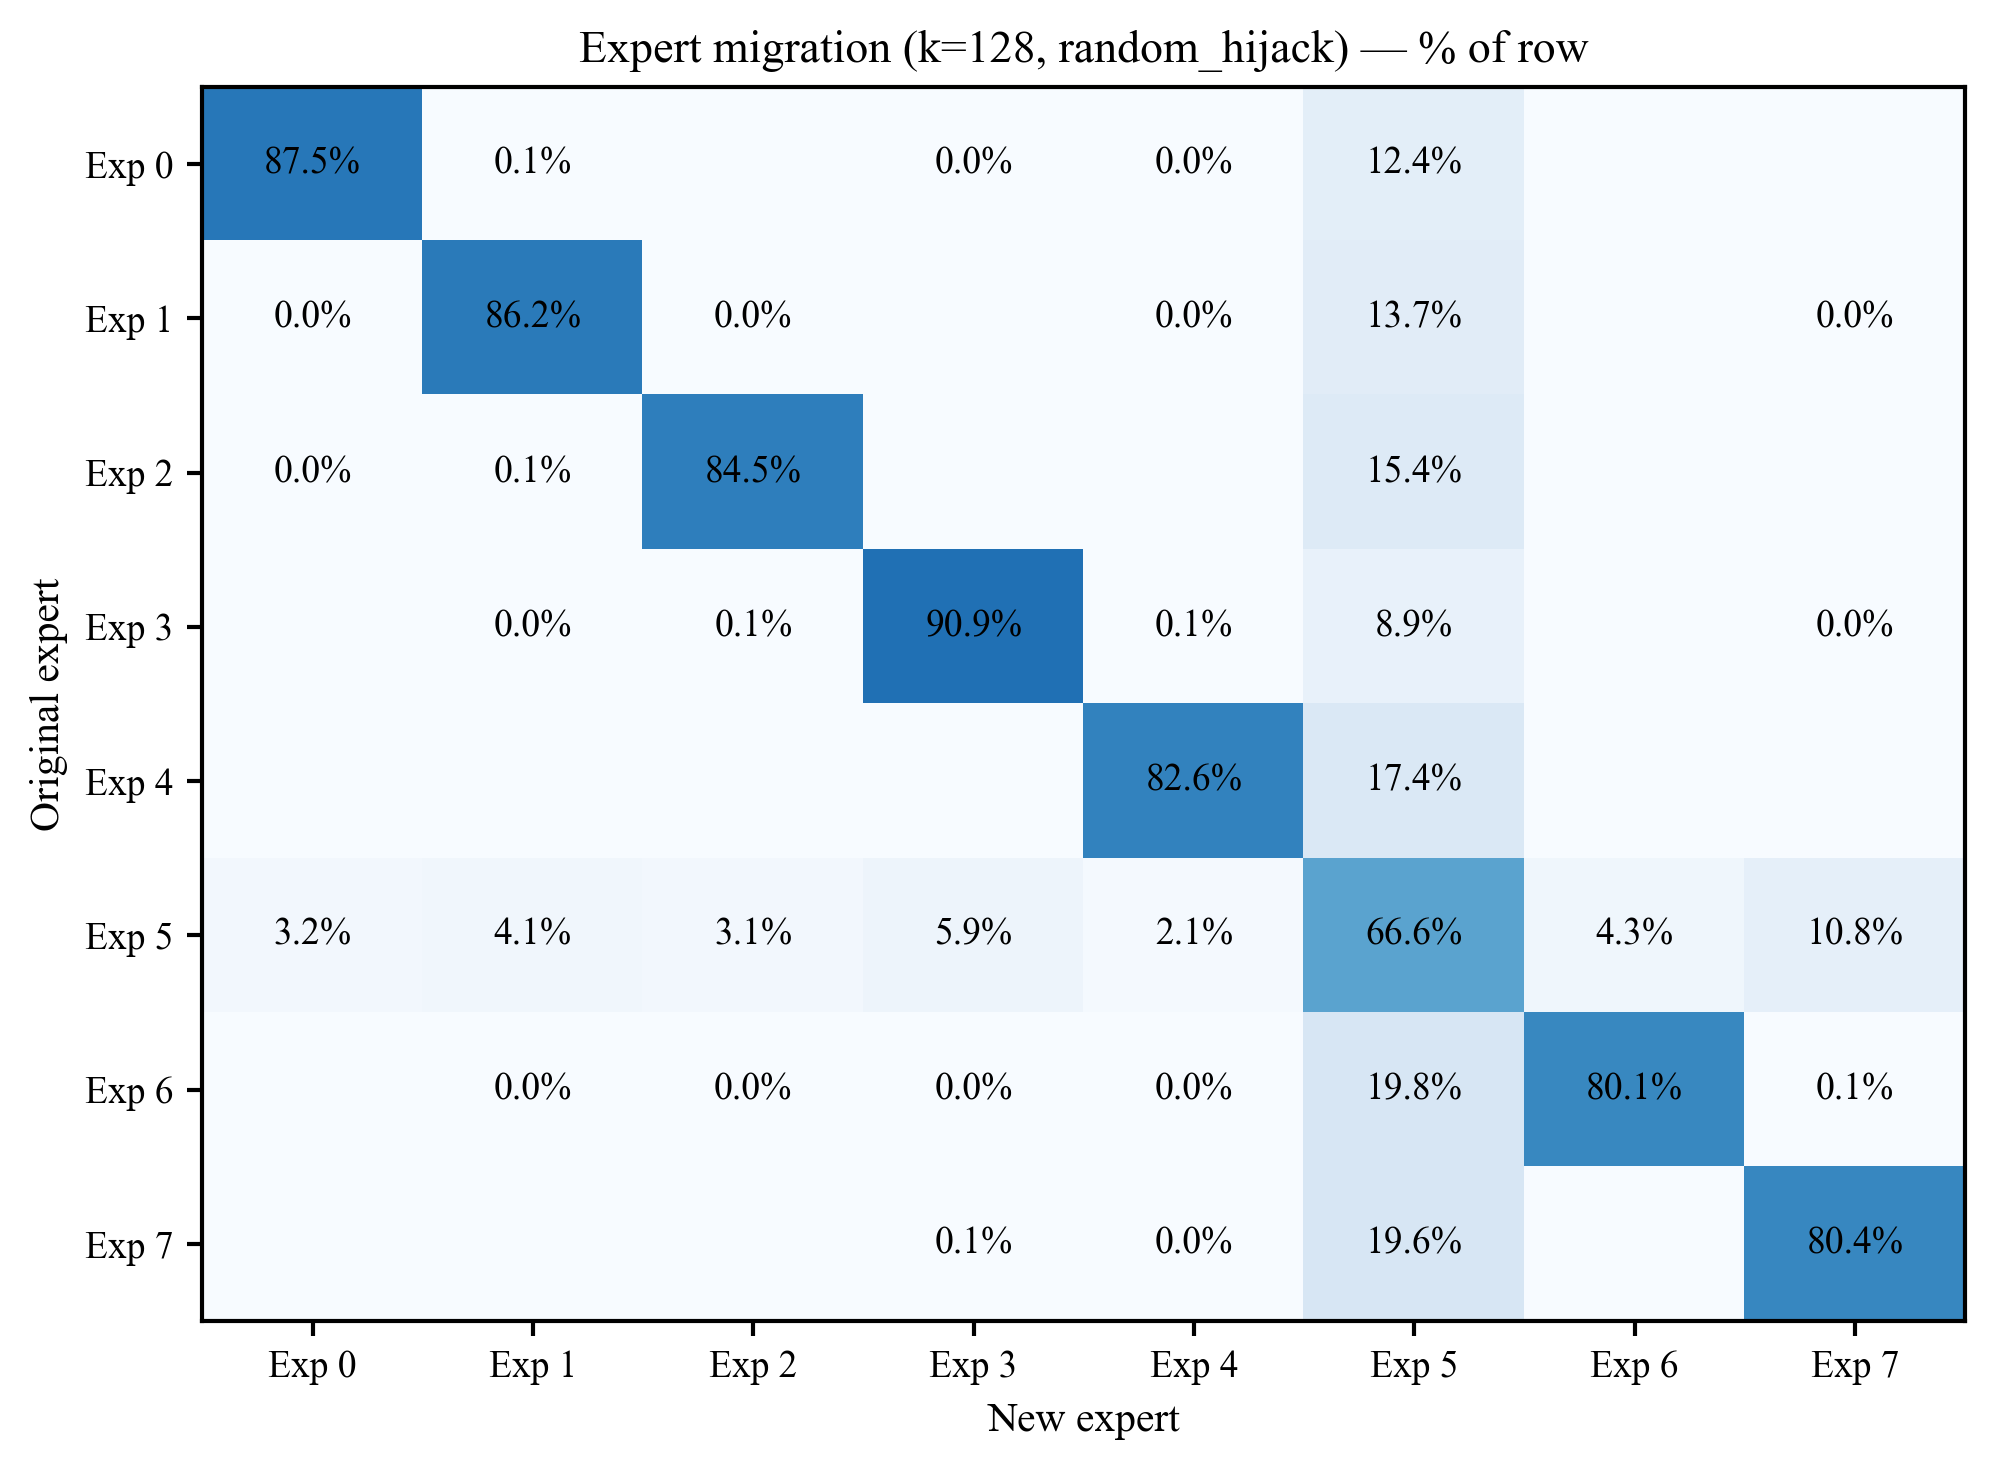

In [4]:
import numpy as np

# Which k to show (None = all k values)
K_SELECT = None  # e.g. 8 or [4, 8]
# Which variant to show (None = all variants)
VARIANT_SELECT = None  # e.g. "svd_hijack"

by_k = results.get("by_k", {})
cfg = results.get("config", {})
num_experts = cfg.get("num_experts", 8)
source_expert = cfg.get("source_expert")

k_to_show = K_SELECT if isinstance(K_SELECT, list) else ([K_SELECT] if K_SELECT is not None else sorted(int(k) for k in by_k))
if not isinstance(k_to_show, list):
    k_to_show = [k_to_show]

for k in k_to_show:
    k_str = str(k)
    if k_str not in by_k:
        print(f"k={k} not in results. Skip.")
        continue
    entries = by_k[k_str]
    vars_to_show = [VARIANT_SELECT] if VARIANT_SELECT else list(entries.keys())
    for vkey in vars_to_show:
        if vkey not in entries:
            continue
        entry = entries[vkey]
        if not isinstance(entry, dict):
            continue
        if "expert_confusion_matrix" not in entry:
            continue
        # Migration matrix: raw counts
        if "expert_confusion_matrix" in entry:
            fig_raw = plot_expert_migration_heatmap_acl(
                entry["expert_confusion_matrix"],
                num_experts=num_experts,
                source_expert=source_expert,
                column_width="double",
                title=f"Expert migration (k={k}, {vkey}) — raw counts",
                as_percent=False,
            )
            fig_raw.show()
            # Migration matrix: row-normalized percentages
            fig_pct = plot_expert_migration_heatmap_acl(
                entry["expert_confusion_matrix"],
                num_experts=num_experts,
                source_expert=source_expert,
                column_width="double",
                title=f"Expert migration (k={k}, {vkey}) — % of row",
                as_percent=True,
            )
            fig_pct.show()

## 4. Summary table: loss, delta, migration rate by k and variant

In [5]:
import pandas as pd

rows = []
for k_str, entries in results.get("by_k", {}).items():
    k = int(k_str)
    for vkey, entry in entries.items():
        if not isinstance(entry, dict):
            continue
        estats = entry.get("expert_routing_stats", {})
        row = {
            "k": k,
            "variant": vkey,
            "loss": entry.get("loss"),
            "delta": entry.get("delta"),
            "migration_rate_%": estats.get("migration_rate") * 100 if estats else None,
        }
        src_exp = results.get("config", {}).get("source_expert")
        if src_exp is not None and estats:
            row["source_retention_%"] = estats.get(f"expert_{src_exp}", {}).get("retention_rate") * 100
        rows.append(row)

df = pd.DataFrame(rows)
display(df)

,k,variant,loss,delta,migration_rate_%,source_retention_%
0,1,svd_hijack,2.542028,0.003251,13.534433,8.072354
1,1,random_hijack,2.540834,0.002057,19.469763,84.503240
2,4,svd_hijack,2.542125,0.003348,13.686343,7.748380
3,4,random_hijack,2.541810,0.003033,13.075087,80.291577
4,8,svd_hijack,2.541887,0.003110,13.729745,7.397408
5,8,random_hijack,2.541383,0.002606,14.695457,65.523758
6,32,svd_hijack,2.541854,0.003077,13.595920,8.450324
7,32,random_hijack,2.542231,0.003454,17.086227,68.412527
8,64,svd_hijack,2.542031,0.003254,13.530816,8.801296
9,64,random_hijack,2.541240,0.002463,22.540509,83.855292


## 5. Optional: save figures to a folder

In [6]:
# Directory containing multiple result files (e.g. one per layer)
COMPARE_DIR = ROOT / "alignment_ablations_results" / "results_1002"
COMPARE_GLOB = "project_out_*.json"  # or "project_out_L*.json"

# For "delta vs layer" plot: which k to use
K_FOR_LAYERS = 8

# For "delta vs k" comparison: which layers to show (None = all layers in dir)
LAYERS_TO_COMPARE = [0, 12, 24]  # e.g. early, mid, late

from src.experiments.router_interventions.viz import load_results_dir, plot_delta_vs_layers_acl

if not COMPARE_DIR.exists():
    print(f"Directory not found: {COMPARE_DIR}. Set COMPARE_DIR to a folder with result JSONs.")
else:
    all_results = load_results_dir(COMPARE_DIR, glob=COMPARE_GLOB)
    layers = [r.get("config", {}).get("layer_idx") for r in all_results]
    print(f"Loaded {len(all_results)} result files. Layers: {sorted(set(layers))}")

    # 1. Loss Δ vs layer (fixed k) — only svd and random (hijacking)
    fig_layers = plot_delta_vs_layers_acl(
        all_results,
        k=K_FOR_LAYERS,
        variants=["svd", "random"],
        title=f"Loss Δ vs layer (k={K_FOR_LAYERS})",
        column_width="double",
    )
    fig_layers.show()

    # 2. Loss Δ vs k: compare selected layers (one line per layer, one subplot per variant)
    layer_results = {r.get("config", {}).get("layer_idx"): r for r in all_results}
    layers_plot = LAYERS_TO_COMPARE if LAYERS_TO_COMPARE else sorted(layer_results.keys())
    layers_plot = [L for L in layers_plot if L in layer_results]
    variants = ["svd", "random"]
    colors = ["#0173B2", "#DE8F05"]

    if layers_plot:
        import matplotlib.pyplot as plt
        nv = len(variants)
        fig2, axes = plt.subplots(1, 2, figsize=(6.75, 4), sharex=True, sharey=False)
        axes = axes.flatten()
        for vi, var in enumerate(variants):
            ax = axes[vi]
            for li, layer in enumerate(layers_plot):
                res = layer_results[layer]
                by_k = res.get("by_k", {})
                k_indep = res.get("k_independent", {})
                k_vals = sorted(int(k) for k in by_k)
                deltas = []
                for k in k_vals:
                    ent = {**k_indep, **by_k.get(str(k), by_k.get(k, {}))}
                    d = ent.get(var, {}).get("delta") if isinstance(ent.get(var), dict) else None
                    deltas.append(d)
                if all(d is not None for d in deltas):
                    ax.plot(k_vals, deltas, marker="o", markersize=4, linewidth=1.5,
                            color=colors[li % len(colors)], label=f"Layer {layer}")
            ax.set_xscale("log", base=2)
            ax.set_xticks(k_vals)
            ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
            ax.set_title(var.replace("_", " ").title())
            ax.set_ylabel("Loss Δ")
            ax.legend(fontsize=8)
            ax.grid(True, axis="y", alpha=0.35)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
        axes[0].set_xlabel("")
        axes[1].set_xlabel("Number of vectors k")
        fig2.suptitle("Loss Δ vs k by layer (comparison)", fontsize=12)
        fig2.tight_layout()
        fig2.show()
    else:
        print("No layers to compare. Set LAYERS_TO_COMPARE or ensure COMPARE_DIR has project_out JSONs.")

Loaded 8 result files. Layers: [0, 4, 8, 12, 16, 20, 24, 28]


TypeError: plot_delta_vs_layers_acl() got an unexpected keyword argument 'title'

In [ ]:
SAVE_DIR = None  # e.g. ROOT / "alignment_ablations_results" / "results_hijack_try_1" / "plots"

if SAVE_DIR:
    SAVE_DIR = Path(SAVE_DIR)
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    plot_delta_vs_k(results, save_path=SAVE_DIR / "delta_vs_k.png")
    n_exp = results.get("config", {}).get("num_experts", 8)
    src_exp = results.get("config", {}).get("source_expert")
    for k_str, entries in results.get("by_k", {}).items():
        for vkey, entry in entries.items():
            if not isinstance(entry, dict):
                continue
            if "expert_confusion_matrix" in entry:
                plot_expert_migration_heatmap(
                    entry["expert_confusion_matrix"],
                    num_experts=n_exp,
                    source_expert=src_exp,
                    title=f"k={k_str} {vkey}",
                    save_path=SAVE_DIR / f"migration_k{k_str}_{vkey}.png",
                )
    print(f"Saved to {SAVE_DIR}")